#ดึงข้อมูลอากาศรอบๆสระบุรีจากข้อมูลกรมอุตุนิยมวิทยาที่เก็บใน OGIMET ในไฟล์นี้เน้นดึง ลพบุรี เพราะข้อมูลมีอย่างต่อเนื่องและใกล้สระบุรี
* https://github.com/feelfreelinux/ogimetdownloader
* https://github.com/iuiuiu-wayy/Ogimet
* ตัวอย่าง OGIMET ของลพบุรี https://ogimet.com/cgi-bin/gsynres?lang=en&ord=REV&ndays=30&ano=2026&mes=08&day=17&hora=06&ind=48426
* ตัวอย่างโค้ดในโปรแกรม R ไลบราลี่ Climate ที่จะดึงข้อมูล OGIMET มาใช้ได้ https://bczernecki.github.io/climate/
* ให้ลองทดสอบการดึงข้อมูลในช่วงสั้นๆ ก่อน แล้วพลอตข้อมูลเหล่านั้นออกมา ถ้าพอใจแล้ว ให้เปลี่ยนเป็นดึงข้อมูลทั้งหมด 10 ปี แล้วเซฟข้อมูลเอาเก็บไว้ในไดร์ฟ แล้วค่อยอ่านเพื่อพลอตข้อมูลที่ต้องการ เช่น ลม

In [ ]:
# =====================================================================
# CELL 00 — INSTALL R + climate
# =====================================================================

import subprocess
from pathlib import Path

!apt-get -qq update
!apt-get -qq install -y \
    r-base r-base-dev build-essential \
    libcurl4-openssl-dev libssl-dev libxml2-dev \
    libarchive-dev libicu-dev

R_INSTALL = r"""
options(
  repos = c(CRAN = "https://cloud.r-project.org"),
  timeout = 1200
)

site_lib <- "/usr/local/lib/R/site-library"

if (!dir.exists(site_lib)) {
  dir.create(
    site_lib,
    recursive = TRUE,
    showWarnings = FALSE
  )
}

.libPaths(c(site_lib, .libPaths()))

cat("R version:", R.version.string, "\n")
cat("R library paths:\n")
print(.libPaths())

deps <- c(
  "archive",
  "curl",
  "data.table",
  "httr",
  "R6",
  "stringi"
)

missing_deps <- deps[
  !vapply(
    deps,
    requireNamespace,
    quietly = TRUE,
    FUN.VALUE = logical(1)
  )
]

if (length(missing_deps) > 0) {
  cat(
    "\nInstalling missing dependencies:",
    paste(missing_deps, collapse = ", "),
    "\n"
  )

  install.packages(
    missing_deps,
    lib = site_lib,
    dependencies = c("Depends", "Imports", "LinkingTo")
  )
}

if (!requireNamespace("climate", quietly = TRUE, lib.loc = site_lib)) {
  cat("\nInstalling climate from CRAN...\n")

  install.packages(
    "climate",
    lib = site_lib,
    repos = "https://cloud.r-project.org",
    dependencies = FALSE
  )
}

ok <- requireNamespace(
  "climate",
  quietly = TRUE,
  lib.loc = site_lib
)

cat("\n--- VERIFICATION ---\n")
cat("climate available:", ok, "\n")

if (!ok) {
  stop("climate installation failed.")
}

library(
  climate,
  lib.loc = site_lib
)

cat(
  "climate version:",
  as.character(packageVersion("climate")),
  "\n"
)

cat(
  "climate path:",
  find.package("climate", lib.loc = site_lib),
  "\n"
)

cat(
  "meteo_ogimet exists:",
  exists("meteo_ogimet", where = asNamespace("climate")),
  "\n"
)

if (!exists("meteo_ogimet", where = asNamespace("climate"))) {
  stop("climate loaded, but meteo_ogimet() was not found.")
}
"""

Path("/content/install_climate_lopburi.R").write_text(
    R_INSTALL,
    encoding="utf-8"
)

proc = subprocess.run(
    ["Rscript", "/content/install_climate_lopburi.R"],
    capture_output=True,
    text=True
)

print(proc.stdout)

if proc.stderr:
    print("\nR messages / warnings:")
    print(proc.stderr)

if proc.returncode != 0:
    raise RuntimeError(
        "R/climate installation failed. "
        "Do not continue until Cell 00 succeeds."
    )

print("✅ Cell 00 completed: climate is available.")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
R version: R version 4.6.1 (2026-06-24) 
R library paths:
[1] "/usr/local/lib/R/site-library" "/usr/lib/R/site-library"      
[3] "/usr/lib/R/library"           

--- VERIFICATION ---
climate available: TRUE 
climate version: 1.4.0 
climate path: /usr/local/lib/R/site-library/climate 
meteo_ogimet exists: TRUE 

✅ Cell 00 completed: climate is available.


## กำหนด วัน เดือน ปี USER SETTINGS + OPTIONAL GOOGLE DRIVE

In [ ]:
# =====================================================================
# CELL 01 — USER SETTINGS + OPTIONAL GOOGLE DRIVE
# =====================================================================

import os
import time
import math
import json
import shutil
import subprocess
from pathlib import Path
from datetime import timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# USER SETTINGS
# ---------------------------------------------------------------------

STATION_WMO = "48426"
STATION_NAME = "Lop Buri"

# Modes:
#   "TEST"            = 2 local days
#   "CUSTOM"          = use START_DATE and END_DATE below
#   "FULL_2016_2025"  = entire 2016-01-01 to 2025-12-31 period
MODE = "CUSTOM" #ตรงนี้ จะกำหนดว่า จะดึงข้อมูลแบบทดสอบก่อน เอาช่วงสั้นๆ หรือ เอาแบบ full ให้เลือกเอา แล้วไปกำหนดช่วงเวลาด้านล่าง

# Thailand-local calendar dates. #ทดสอบช่วงเวลาที่ต้องการดึงข้อมูลตรงนี้ ครั้งแรกๆ เอาสัก 1,3,12 เดือนก่อน แล้วพลอตข้อมูลมาดู
START_DATE = "2024-01-01"
END_DATE   = "2024-12-31"

TEST_START_DATE = "2024-03-01" #เป็นตัวแปรที่ใช้ MODE Full
TEST_END_DATE   = "2024-03-02"

FULL_START_DATE = "2016-01-01" #วันแรก หากต้องการต้องไปเปลี่ยน MODE เป็น Full
FULL_END_DATE   = "2025-12-31"  #วันสุดท้าย

LOCAL_TZ = "Asia/Bangkok"

# For a long download, set True so completed chunks survive Colab restarts.
#SAVE_TO_DRIVE = False  #หากต้องการเซฟข้อมูลลงไดร์ฟ ให้เลือก True
SAVE_TO_DRIVE = True  #หากต้องการเซฟข้อมูลลงไดร์ฟ ให้เลือก True

DRIVE_BASE_DIR = (
    "/content/drive/MyDrive/"
    "Saraburi_PM25_Meteorology"
)

# Adaptive downloader settings.
INITIAL_LOCAL_CHUNK_DAYS = 7
RETRY_WAITS_SECONDS = [0, 5, 15]
PAUSE_BETWEEN_TOPLEVEL_CHUNKS_SECONDS = 1.5

# QA settings.
DAILY_SLOT_COMPLETENESS_MIN = 0.75
DAILY_MIN_DAYPARTS = 3
VARIABLE_VALID_FRACTION_MIN = 0.75

# If True, RH is calculated from T/Td when compact rel_hum is missing.
# Both raw and fallback values are preserved.
DERIVE_RH_FROM_T_TD_IF_MISSING = True

FIG_DPI = 300

# ---------------------------------------------------------------------
# Resolve selected date range.
# ---------------------------------------------------------------------
MODE = MODE.upper().strip()

if MODE == "TEST":
    SELECTED_START_DATE = TEST_START_DATE
    SELECTED_END_DATE = TEST_END_DATE

elif MODE == "CUSTOM":
    SELECTED_START_DATE = START_DATE
    SELECTED_END_DATE = END_DATE

elif MODE == "FULL_2016_2025":
    SELECTED_START_DATE = FULL_START_DATE
    SELECTED_END_DATE = FULL_END_DATE

else:
    raise ValueError(
        "MODE must be TEST, CUSTOM, or FULL_2016_2025."
    )

SELECTED_START_DATE = pd.Timestamp(
    SELECTED_START_DATE
).date()

SELECTED_END_DATE = pd.Timestamp(
    SELECTED_END_DATE
).date()

if SELECTED_END_DATE < SELECTED_START_DATE:
    raise ValueError(
        "END_DATE must be on or after START_DATE."
    )

# ---------------------------------------------------------------------
# Output location.
# ---------------------------------------------------------------------
if SAVE_TO_DRIVE:

    from google.colab import drive

    drive.mount(
        "/content/drive"
    )

    ROOT_DIR = (
        Path(DRIVE_BASE_DIR)
        /
        f"LopBuri_{STATION_WMO}"
    )

else:

    ROOT_DIR = Path(
        f"/content/LopBuri_{STATION_WMO}"
    )

RAW_COMPACT_DIR = ROOT_DIR / "raw_compact"
RAW_FULL_DIR = ROOT_DIR / "raw_full"
PROCESSED_DIR = ROOT_DIR / "processed"
QA_DIR = ROOT_DIR / "qa"
LOG_DIR = ROOT_DIR / "logs"
FIG_DIR = ROOT_DIR / "figures"

for directory in [
    ROOT_DIR,
    RAW_COMPACT_DIR,
    RAW_FULL_DIR,
    PROCESSED_DIR,
    QA_DIR,
    LOG_DIR,
    FIG_DIR
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": FIG_DPI,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
})

print("Station :", STATION_WMO, STATION_NAME)
print("Mode    :", MODE)
print(
    "Local date range:",
    SELECTED_START_DATE,
    "to",
    SELECTED_END_DATE
)
print("Save to Drive:", SAVE_TO_DRIVE)
print("Root directory:", ROOT_DIR)

print("\n✅ Cell 01 completed.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Station : 48426 Lop Buri
Mode    : CUSTOM
Local date range: 2024-01-01 to 2024-12-31
Save to Drive: True
Root directory: /content/drive/MyDrive/Saraburi_PM25_Meteorology/LopBuri_48426

✅ Cell 01 completed.


## กำหนดสถานีที่ต้องการ

  wmo     name  latitude  longitude  altitude_m  country
48426 Lop Buri 14.799444 100.628056          10 Thailand

✅ Cell 02 completed.
Requested Thailand-local dates: 2024-01-01 to 2024-12-31
Safe Ogimet UTC calendar dates: 2023-12-31 to 2024-12-31

✅ Cell 03 completed.
R worker created: /content/lopburi_ogimet_worker.R

site_lib <- "/usr/local/lib/R/site-library"
.libPaths(c(site_lib, .libPaths()))

args <- commandArgs(trailingOnly = TRUE)

if (length(args) < 6) {
  stop(
    "Usage: Rscript worker.R MODE STATION START END OUT_COMPACT OUT_FULL"
  )
}

mode <- args[1]
station <- args[2]
start_date <- args[3]
end_date <- args[4]
out_compact <- args[5]
out_full <- args[6]

suppressPackageStartupMessages(
  library(
    climate,
    lib.loc = site_lib
  )
)

safe_write <- function(x, path) {
  if (is.null(x)) return(FALSE)

  if (!is.data.frame(x)) {
    x <- as.data.frame(x)
  }

  write.csv(
    x,
    path,
    row.names = FALSE,
    na = ""
  )

  TRUE
}

if (mode == "synop") {

  re

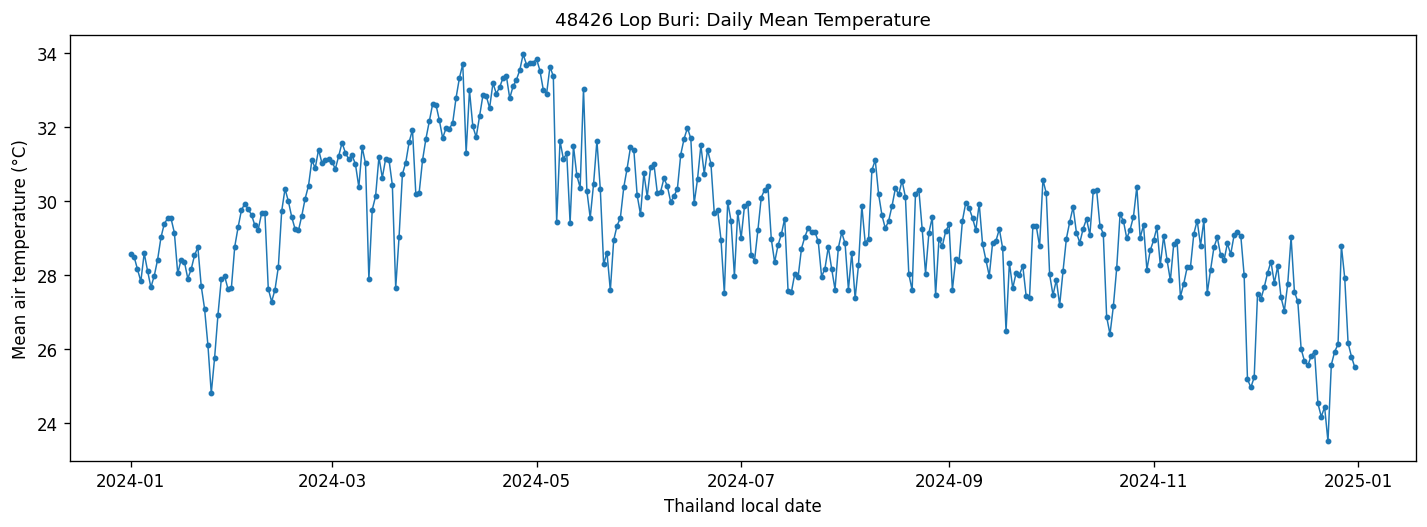

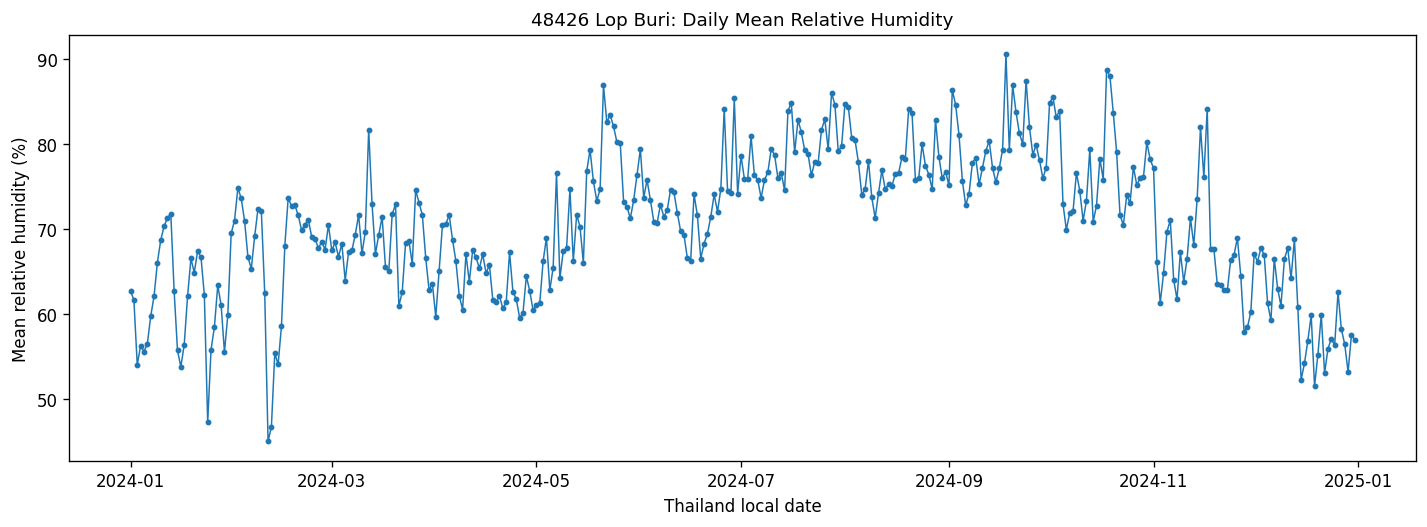

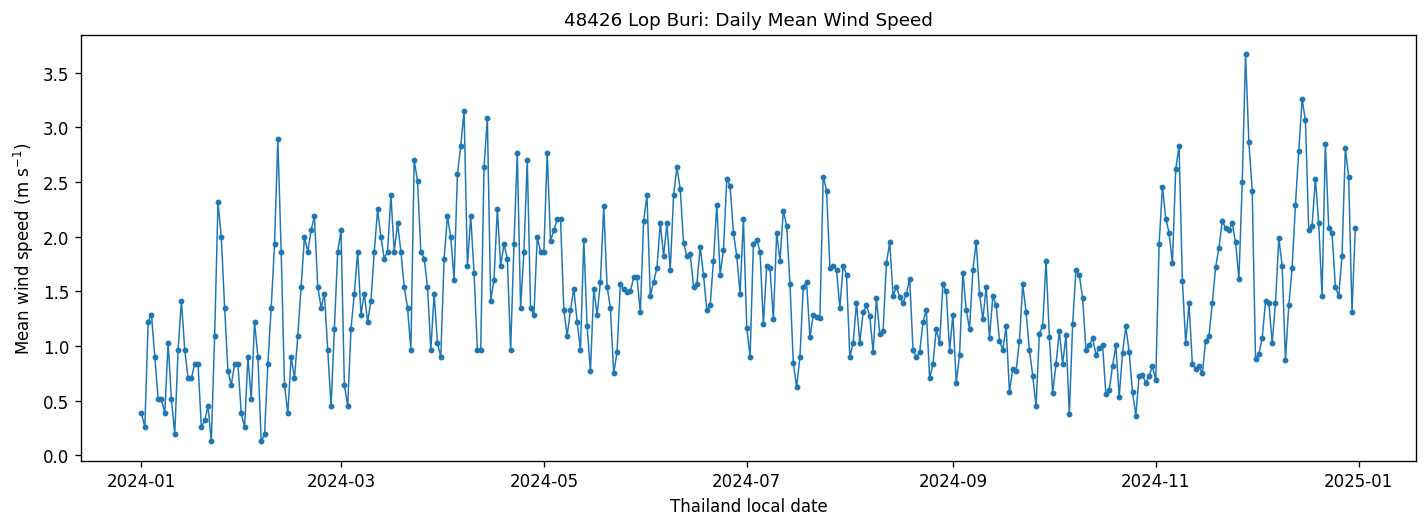

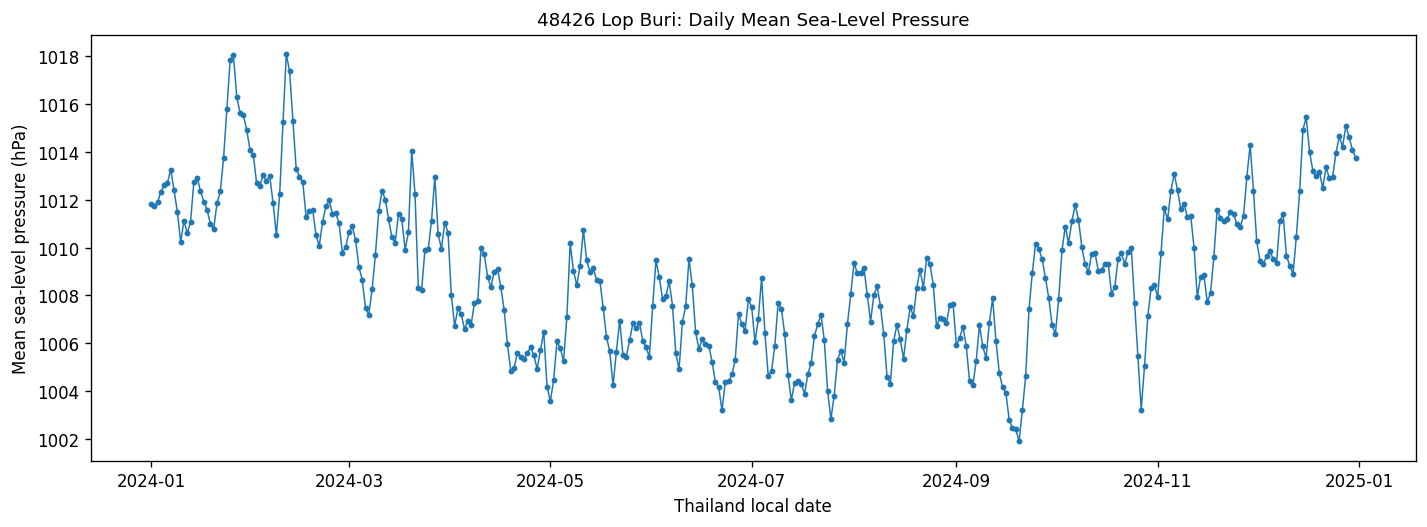

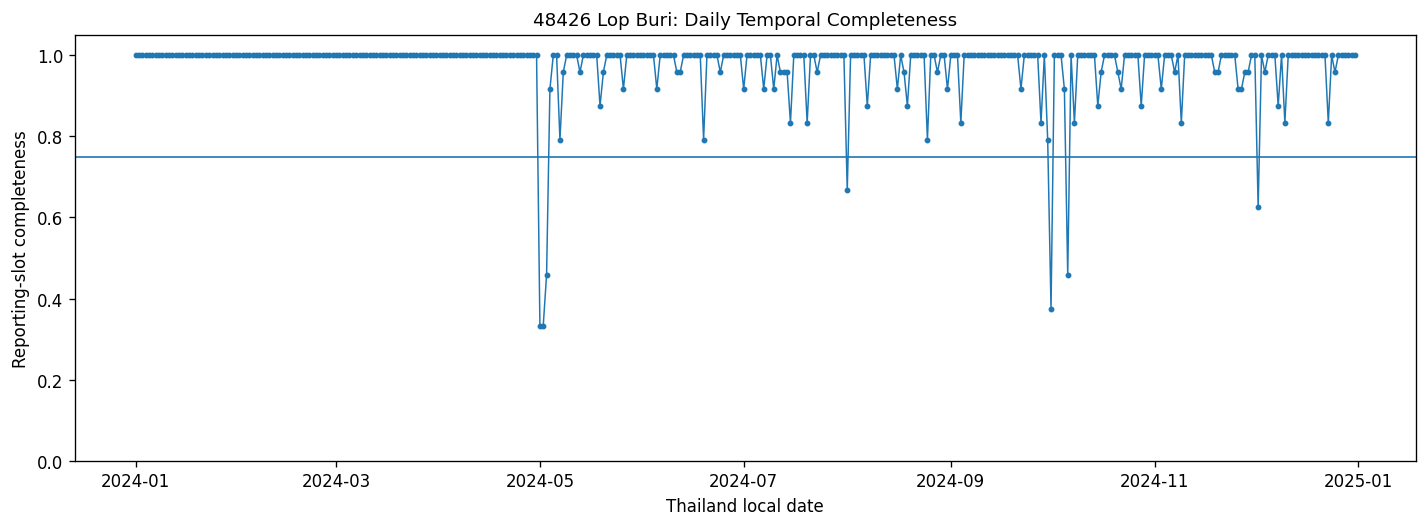

Saved diagnostic figures:
  /content/drive/MyDrive/Saraburi_PM25_Meteorology/LopBuri_48426/figures/Fig01_daily_temperature.png
  /content/drive/MyDrive/Saraburi_PM25_Meteorology/LopBuri_48426/figures/Fig02_daily_relative_humidity.png
  /content/drive/MyDrive/Saraburi_PM25_Meteorology/LopBuri_48426/figures/Fig03_daily_wind_speed.png
  /content/drive/MyDrive/Saraburi_PM25_Meteorology/LopBuri_48426/figures/Fig04_daily_sea_level_pressure.png
  /content/drive/MyDrive/Saraburi_PM25_Meteorology/LopBuri_48426/figures/Fig05_daily_reporting_completeness.png

✅ Cell 14 completed.
station station_name   mode selected_start_date selected_end_date  n_requested_local_days  n_manifest_resolved_local_days  n_manifest_unresolved_local_days  n_actual_zero_observation_days  n_actual_partial_or_QA_fail_days  n_subdaily_observations  n_daily_rows  n_daily_all_core_QA_pass
  48426     Lop Buri CUSTOM          2024-01-01        2024-12-31                     366                             366                

In [ ]:
# =====================================================================
# CELL 02 — STATION METADATA
# =====================================================================

STATION_META = {
    "wmo": STATION_WMO,
    "name": STATION_NAME,
    "latitude": 14 + 47/60 + 58/3600,
    "longitude": 100 + 37/60 + 41/3600,
    "altitude_m": 10,
    "country": "Thailand"
}

station_meta_df = pd.DataFrame(
    [STATION_META]
)

station_meta_df.to_csv(
    ROOT_DIR / "station_metadata.csv",
    index=False,
    encoding="utf-8-sig"
)

print(station_meta_df.to_string(index=False))
print("\n✅ Cell 02 completed.")



# =====================================================================
# CELL 03 — THAILAND-LOCAL DATE → SAFE UTC REQUEST WINDOW
# =====================================================================

def local_dates_to_utc_request_dates(
    local_start_date,
    local_end_date
):
    """
    Convert an inclusive Asia/Bangkok local-date interval to the UTC
    calendar dates that Ogimet must retrieve to fully cover that interval.
    """

    local_start = pd.Timestamp(
        local_start_date,
        tz=LOCAL_TZ
    )

    local_end_exclusive = (
        pd.Timestamp(
            local_end_date,
            tz=LOCAL_TZ
        )
        +
        pd.Timedelta(days=1)
    )

    utc_start = local_start.tz_convert(
        "UTC"
    )

    utc_end_exclusive = (
        local_end_exclusive.tz_convert(
            "UTC"
        )
    )

    utc_request_start = (
        utc_start.floor("D").date()
    )

    utc_request_end = (
        (
            utc_end_exclusive
            -
            pd.Timedelta(microseconds=1)
        )
        .floor("D")
        .date()
    )

    return (
        str(utc_request_start),
        str(utc_request_end)
    )


def crop_to_exact_local_dates(
    df,
    local_start_date,
    local_end_date,
    datetime_utc_col="datetime_utc"
):
    """
    Convert UTC timestamps to Asia/Bangkok and keep only observations
    within the requested inclusive Thailand-local calendar dates.
    """

    d = df.copy()

    d[datetime_utc_col] = pd.to_datetime(
        d[datetime_utc_col],
        utc=True,
        errors="coerce"
    )

    d["datetime_local"] = (
        d[datetime_utc_col]
        .dt.tz_convert(LOCAL_TZ)
    )

    start_local = pd.Timestamp(
        local_start_date,
        tz=LOCAL_TZ
    )

    end_local_exclusive = (
        pd.Timestamp(
            local_end_date,
            tz=LOCAL_TZ
        )
        +
        pd.Timedelta(days=1)
    )

    d = d[
        (
            d["datetime_local"]
            >=
            start_local
        )
        &
        (
            d["datetime_local"]
            <
            end_local_exclusive
        )
    ].copy()

    d["date_local"] = (
        d["datetime_local"]
        .dt.date
    )

    d["hour_local"] = (
        d["datetime_local"]
        .dt.hour
    )

    return d


utc_request_start, utc_request_end = (
    local_dates_to_utc_request_dates(
        SELECTED_START_DATE,
        SELECTED_END_DATE
    )
)

print(
    "Requested Thailand-local dates:",
    SELECTED_START_DATE,
    "to",
    SELECTED_END_DATE
)
print(
    "Safe Ogimet UTC calendar dates:",
    utc_request_start,
    "to",
    utc_request_end
)

print("\n✅ Cell 03 completed.")


# ============================================================================================
# COPY AS CODE CELL 04
# ============================================================================================
# =====================================================================
# CELL 04 — CREATE R OGIMET SYNOP WORKER
# =====================================================================

R_WORKER = Path(
    "/content/lopburi_ogimet_worker.R"
)

R_WORKER.write_text(
    r"""
site_lib <- "/usr/local/lib/R/site-library"
.libPaths(c(site_lib, .libPaths()))

args <- commandArgs(trailingOnly = TRUE)

if (length(args) < 6) {
  stop(
    "Usage: Rscript worker.R MODE STATION START END OUT_COMPACT OUT_FULL"
  )
}

mode <- args[1]
station <- args[2]
start_date <- args[3]
end_date <- args[4]
out_compact <- args[5]
out_full <- args[6]

suppressPackageStartupMessages(
  library(
    climate,
    lib.loc = site_lib
  )
)

safe_write <- function(x, path) {
  if (is.null(x)) return(FALSE)

  if (!is.data.frame(x)) {
    x <- as.data.frame(x)
  }

  write.csv(
    x,
    path,
    row.names = FALSE,
    na = ""
  )

  TRUE
}

if (mode == "synop") {

  result <- tryCatch(
    climate::meteo_ogimet(
      interval = "hourly",
      date = c(
        start_date,
        end_date
      ),
      station = station,
      source = "synop",
      return_list = TRUE,
      allow_failure = TRUE
    ),
    error = function(e) {
      message(
        "ERROR: ",
        conditionMessage(e)
      )

      NULL
    }
  )

  if (is.null(result)) {
    quit(
      status = 2
    )
  }

  compact <- result$data
  full <- result$full

  if (
    is.null(compact)
    ||
    nrow(compact) == 0
  ) {
    quit(
      status = 3
    )
  }

  if ("date" %in% names(compact)) {
    compact$date_utc_iso <- format(
      as.POSIXct(
        compact$date,
        tz = "UTC"
      ),
      "%Y-%m-%dT%H:%M:%SZ",
      tz = "UTC"
    )
  }

  if (
    !is.null(full)
    &&
    nrow(full) > 0
    &&
    "Date" %in% names(full)
  ) {
    full$date_utc_iso <- format(
      as.POSIXct(
        full$Date,
        tz = "UTC"
      ),
      "%Y-%m-%dT%H:%M:%SZ",
      tz = "UTC"
    )
  }

  ok1 <- safe_write(
    compact,
    out_compact
  )

  ok2 <- safe_write(
    full,
    out_full
  )

  cat(
    "Compact rows:",
    nrow(compact),
    "\n"
  )

  cat(
    "Full rows:",
    ifelse(
      is.null(full),
      0,
      nrow(full)
    ),
    "\n"
  )

  if (!ok1) {
    quit(
      status = 4
    )
  }

} else {

  stop(
    "Unknown mode: ",
    mode
  )
}
""",
    encoding="utf-8"
)

print("R worker created:", R_WORKER)
print(
    R_WORKER.read_text(
        encoding="utf-8"
    )[:1800]
)

print("\n✅ Cell 04 completed.")



# =====================================================================
# CELL 05 — ADAPTIVE + RESUMABLE DOWNLOADER
# =====================================================================

MASTER_MANIFEST = (
    LOG_DIR
    /
    "download_manifest.csv"
)


def normalize_station_id(
    value
):
    return (
        str(value)
        .strip()
        .replace(".0", "")
        .zfill(5)
    )


def run_r_synop_request(
    station,
    utc_start_date,
    utc_end_date,
    compact_file,
    full_file,
    timeout_seconds=300
):
    """
    Execute one climate::meteo_ogimet() request in a separate R process.
    """

    cmd = [
        "Rscript",
        str(R_WORKER),
        "synop",
        normalize_station_id(station),
        str(utc_start_date),
        str(utc_end_date),
        str(compact_file),
        str(full_file),
    ]

    started = time.time()

    try:

        proc = subprocess.run(
            cmd,
            capture_output=True,
            text=True,
            timeout=timeout_seconds
        )

        return {
            "status":
            (
                "SUCCESS"
                if proc.returncode == 0
                else "FAILED"
            ),
            "returncode":
            proc.returncode,
            "elapsed_s":
            round(
                time.time()
                -
                started,
                1
            ),
            "stdout":
            proc.stdout.strip(),
            "stderr":
            proc.stderr.strip()
        }

    except subprocess.TimeoutExpired as e:

        return {
            "status":
            "TIMEOUT",
            "returncode":
            np.nan,
            "elapsed_s":
            round(
                time.time()
                -
                started,
                1
            ),
            "stdout":
            str(
                e.stdout
                or ""
            ),
            "stderr":
            str(
                e.stderr
                or ""
            )
        }


def chunk_file_paths(
    local_start,
    local_end
):
    """
    Stable file names are based on Thailand-local dates.
    """

    local_start_text = str(
        pd.Timestamp(
            local_start
        ).date()
    )

    local_end_text = str(
        pd.Timestamp(
            local_end
        ).date()
    )

    stem = (
        f"{STATION_WMO}_"
        f"{local_start_text}_"
        f"{local_end_text}"
    )

    return (
        RAW_COMPACT_DIR
        /
        f"{stem}_compact.csv",
        RAW_FULL_DIR
        /
        f"{stem}_full.csv"
    )


def validate_existing_compact_file(
    compact_file
):
    """
    A cached chunk is considered reusable only if it exists and contains
    at least one decoded observation.
    """

    compact_file = Path(
        compact_file
    )

    if not compact_file.exists():
        return False, 0

    try:

        d = pd.read_csv(
            compact_file
        )

        return (
            len(d) > 0,
            len(d)
        )

    except Exception:

        return False, 0


def request_one_local_block(
    local_start,
    local_end,
    overwrite=False
):
    """
    Request one Thailand-local block with retry waits.

    Returns a manifest row. A failed multi-day block may later be split.
    """

    local_start = pd.Timestamp(
        local_start
    ).date()

    local_end = pd.Timestamp(
        local_end
    ).date()

    compact_file, full_file = (
        chunk_file_paths(
            local_start,
            local_end
        )
    )

    if not overwrite:

        cached_ok, cached_rows = (
            validate_existing_compact_file(
                compact_file
            )
        )

        if cached_ok:

            utc_start, utc_end = (
                local_dates_to_utc_request_dates(
                    local_start,
                    local_end
                )
            )

            return {
                "station":
                STATION_WMO,
                "local_start_date":
                str(local_start),
                "local_end_date":
                str(local_end),
                "utc_request_start_date":
                utc_start,
                "utc_request_end_date":
                utc_end,
                "n_local_days":
                (
                    pd.Timestamp(local_end)
                    -
                    pd.Timestamp(local_start)
                ).days
                +
                1,
                "status":
                "SUCCESS_CACHED",
                "success":
                True,
                "n_messages":
                cached_rows,
                "attempts":
                0,
                "compact_file":
                str(compact_file),
                "full_file":
                str(full_file),
                "stderr":
                ""
            }

    utc_start, utc_end = (
        local_dates_to_utc_request_dates(
            local_start,
            local_end
        )
    )

    last_log = {}

    for attempt, wait_seconds in enumerate(
        RETRY_WAITS_SECONDS,
        start=1
    ):

        if wait_seconds > 0:
            time.sleep(
                wait_seconds
            )

        log = run_r_synop_request(
            station=STATION_WMO,
            utc_start_date=utc_start,
            utc_end_date=utc_end,
            compact_file=compact_file,
            full_file=full_file,
            timeout_seconds=300
        )

        last_log = log

        if (
            log["status"]
            ==
            "SUCCESS"
        ):

            ok, n_rows = (
                validate_existing_compact_file(
                    compact_file
                )
            )

            if ok:

                return {
                    "station":
                    STATION_WMO,
                    "local_start_date":
                    str(local_start),
                    "local_end_date":
                    str(local_end),
                    "utc_request_start_date":
                    utc_start,
                    "utc_request_end_date":
                    utc_end,
                    "n_local_days":
                    (
                        pd.Timestamp(local_end)
                        -
                        pd.Timestamp(local_start)
                    ).days
                    +
                    1,
                    "status":
                    "SUCCESS_DOWNLOADED",
                    "success":
                    True,
                    "n_messages":
                    n_rows,
                    "attempts":
                    attempt,
                    "compact_file":
                    str(compact_file),
                    "full_file":
                    str(full_file),
                    "stderr":
                    log.get(
                        "stderr",
                        ""
                    )[:500]
                }

    return {
        "station":
        STATION_WMO,
        "local_start_date":
        str(local_start),
        "local_end_date":
        str(local_end),
        "utc_request_start_date":
        utc_start,
        "utc_request_end_date":
        utc_end,
        "n_local_days":
        (
            pd.Timestamp(local_end)
            -
            pd.Timestamp(local_start)
        ).days
        +
        1,
        "status":
        "UNRESOLVED_NO_RETURN",
        "success":
        False,
        "n_messages":
        0,
        "attempts":
        len(RETRY_WAITS_SECONDS),
        "compact_file":
        str(compact_file),
        "full_file":
        str(full_file),
        "stderr":
        last_log.get(
            "stderr",
            ""
        )[:500]
    }


def adaptive_download_local_block(
    local_start,
    local_end,
    overwrite=False
):
    """
    Recursively split a failed local-date block until one-day blocks.
    """

    local_start = pd.Timestamp(
        local_start
    ).date()

    local_end = pd.Timestamp(
        local_end
    ).date()

    final_rows = []

    def recurse(
        start_i,
        end_i,
        depth=0
    ):

        result = request_one_local_block(
            start_i,
            end_i,
            overwrite=overwrite
        )

        result["depth"] = depth

        if result["success"]:

            final_rows.append(
                result
            )

            return

        n_days = (
            pd.Timestamp(end_i)
            -
            pd.Timestamp(start_i)
        ).days + 1

        if n_days <= 1:

            final_rows.append(
                result
            )

            return

        left_days = (
            n_days
            //
            2
        )

        left_end = (
            pd.Timestamp(start_i)
            +
            pd.Timedelta(
                days=left_days - 1
            )
        ).date()

        right_start = (
            pd.Timestamp(left_end)
            +
            pd.Timedelta(days=1)
        ).date()

        recurse(
            start_i,
            left_end,
            depth + 1
        )

        recurse(
            right_start,
            end_i,
            depth + 1
        )

    recurse(
        local_start,
        local_end,
        depth=0
    )

    return pd.DataFrame(
        final_rows
    )


def successful_coverage_dates_from_manifest(
    manifest_df
):
    """
    Convert successful manifest ranges to a set of resolved Thailand-local dates.
    """

    covered = set()

    if manifest_df.empty:
        return covered

    successful = manifest_df[
        manifest_df["success"] == True
    ]

    for _, row in successful.iterrows():

        dates = pd.date_range(
            row["local_start_date"],
            row["local_end_date"],
            freq="D"
        )

        for d in dates:
            covered.add(
                d.date()
            )

    return covered


def load_master_manifest():
    if not MASTER_MANIFEST.exists():
        return pd.DataFrame()

    try:
        return pd.read_csv(
            MASTER_MANIFEST
        )
    except Exception:
        return pd.DataFrame()


def save_master_manifest(
    new_rows
):
    """
    Append new rows and remove exact duplicate manifest records.
    """

    old = load_master_manifest()

    combined = pd.concat(
        [
            old,
            new_rows
        ],
        ignore_index=True
    )

    if not combined.empty:

        combined = (
            combined
            .drop_duplicates(
                subset=[
                    "station",
                    "local_start_date",
                    "local_end_date",
                    "status",
                    "compact_file"
                ],
                keep="last"
            )
            .reset_index(
                drop=True
            )
        )

    combined.to_csv(
        MASTER_MANIFEST,
        index=False,
        encoding="utf-8-sig"
    )

    return combined


print("Adaptive/resumable downloader is ready.")
print("Manifest:", MASTER_MANIFEST)
print("\n✅ Cell 05 completed.")


# ============================================================================================
# COPY AS CODE CELL 06
# ============================================================================================
# =====================================================================
# CELL 06 — DOWNLOAD SELECTED DATE RANGE
# =====================================================================

existing_manifest = (
    load_master_manifest()
)

resolved_dates = (
    successful_coverage_dates_from_manifest(
        existing_manifest
    )
)

selected_dates = pd.date_range(
    SELECTED_START_DATE,
    SELECTED_END_DATE,
    freq="D"
)

unresolved_dates = [
    d.date()
    for d in selected_dates
    if d.date()
    not in resolved_dates
]

print(
    "Selected local days:",
    len(selected_dates)
)

print(
    "Already resolved from manifest:",
    len(selected_dates)
    -
    len(unresolved_dates)
)

print(
    "Still to process:",
    len(unresolved_dates)
)


if unresolved_dates:

    # Build consecutive top-level blocks from unresolved dates.
    unresolved_dates = sorted(
        unresolved_dates
    )

    block_starts = []

    current_start = unresolved_dates[0]
    current_end = unresolved_dates[0]

    for next_date in unresolved_dates[1:]:

        consecutive = (
            next_date
            ==
            current_end
            +
            timedelta(days=1)
        )

        current_length = (
            current_end
            -
            current_start
        ).days + 1

        if (
            consecutive
            and
            current_length
            <
            INITIAL_LOCAL_CHUNK_DAYS
        ):

            current_end = next_date

        else:

            block_starts.append(
                (
                    current_start,
                    current_end
                )
            )

            current_start = next_date
            current_end = next_date

    block_starts.append(
        (
            current_start,
            current_end
        )
    )

    print(
        "Top-level blocks:",
        len(block_starts)
    )

    for block_number, (
        block_start,
        block_end
    ) in enumerate(
        block_starts,
        start=1
    ):

        print(
            f"\n[{block_number}/{len(block_starts)}] "
            f"Thailand local: {block_start} → {block_end}"
        )

        block_manifest = (
            adaptive_download_local_block(
                block_start,
                block_end,
                overwrite=False
            )
        )

        if not block_manifest.empty:

            print(
                block_manifest[
                    [
                        "local_start_date",
                        "local_end_date",
                        "status",
                        "n_messages",
                        "attempts",
                        "depth"
                    ]
                ]
                .to_string(
                    index=False
                )
            )

            master_manifest = (
                save_master_manifest(
                    block_manifest
                )
            )

        time.sleep(
            PAUSE_BETWEEN_TOPLEVEL_CHUNKS_SECONDS
        )

else:

    print(
        "All selected days are already covered by successful cached chunks."
    )


master_manifest = (
    load_master_manifest()
)

master_manifest.to_csv(
    LOG_DIR / "download_manifest_current.csv",
    index=False,
    encoding="utf-8-sig"
)

print(
    "\nCurrent manifest rows:",
    len(master_manifest)
)

print(
    "Successful manifest rows:",
    int(
        master_manifest[
            "success"
        ]
        .fillna(False)
        .sum()
    )
    if (
        not master_manifest.empty
        and
        "success"
        in master_manifest.columns
    )
    else 0
)

print(
    "\n✅ Cell 06 completed."
)


# ============================================================================================
# COPY AS CODE CELL 07
# ============================================================================================
# =====================================================================
# CELL 07 — COMBINE + DEDUPLICATE COMPACT SYNOP
# =====================================================================

compact_parts = []

for path in sorted(
    RAW_COMPACT_DIR.glob(
        "*_compact.csv"
    )
):

    try:

        d = pd.read_csv(
            path
        )

        if d.empty:
            continue

        d["source_compact_file"] = (
            path.name
        )

        if "station" in d.columns:

            d["station"] = (
                d["station"]
                .map(
                    normalize_station_id
                )
            )

        else:

            d["station"] = STATION_WMO

        if "date_utc_iso" in d.columns:

            d["datetime_utc"] = pd.to_datetime(
                d["date_utc_iso"],
                utc=True,
                errors="coerce"
            )

        elif "date" in d.columns:

            d["datetime_utc"] = pd.to_datetime(
                d["date"],
                utc=True,
                errors="coerce"
            )

        else:

            continue

        compact_parts.append(
            d
        )

    except Exception as e:

        print(
            "Could not read:",
            path.name,
            repr(e)
        )


if not compact_parts:

    raise RuntimeError(
        "No compact SYNOP data files were found."
    )


compact_all = pd.concat(
    compact_parts,
    ignore_index=True
)


compact_all = (
    compact_all
    .dropna(
        subset=[
            "datetime_utc"
        ]
    )
    .drop_duplicates(
        subset=[
            "station",
            "datetime_utc"
        ],
        keep="last"
    )
    .sort_values(
        "datetime_utc"
    )
    .reset_index(
        drop=True
    )
)


compact_selected = (
    crop_to_exact_local_dates(
        compact_all,
        SELECTED_START_DATE,
        SELECTED_END_DATE,
        datetime_utc_col=
        "datetime_utc"
    )
)


numeric_compact_cols = [
    "t2m",
    "dpt2m",
    "rel_hum",
    "tmax",
    "tmin",
    "wd",
    "ws",
    "gust",
    "press",
    "slp",
    "press_tend",
    "precip",
    "Nt",
    "Nh",
    "N_base",
    "insol",
    "visibility",
    "snow"
]


for column in numeric_compact_cols:

    if column in compact_selected.columns:

        compact_selected[
            column
        ] = pd.to_numeric(
            compact_selected[
                column
            ],
            errors="coerce"
        )


compact_selected.to_csv(
    PROCESSED_DIR
    /
    (
        f"{STATION_WMO}_{STATION_NAME.replace(' ', '')}_"
        f"compact_subdaily_"
        f"{SELECTED_START_DATE}_{SELECTED_END_DATE}.csv"
    ),
    index=False,
    encoding="utf-8-sig"
)


print(
    "Compact observations after deduplication/cropping:",
    len(compact_selected)
)

print(
    "Local span:",
    compact_selected[
        "datetime_local"
    ].min(),
    "to",
    compact_selected[
        "datetime_local"
    ].max()
)

print(
    "\nCompact fields:"
)
print(
    compact_selected.columns.tolist()
)

print(
    "\n✅ Cell 07 completed."
)


# ============================================================================================
# COPY AS CODE CELL 08
# ============================================================================================
# =====================================================================
# CELL 08 — COMBINE + DEDUPLICATE FULL SYNOP PARSER OUTPUT
# =====================================================================

full_parts = []

for path in sorted(
    RAW_FULL_DIR.glob(
        "*_full.csv"
    )
):

    try:

        f = pd.read_csv(
            path
        )

        if f.empty:
            continue

        f["source_full_file"] = (
            path.name
        )

        station_col = (
            "station_id"
            if "station_id" in f.columns
            else None
        )

        if station_col is not None:

            f["station"] = (
                f[station_col]
                .map(
                    normalize_station_id
                )
            )

        else:

            f["station"] = (
                STATION_WMO
            )

        if "date_utc_iso" in f.columns:

            f["datetime_utc"] = (
                pd.to_datetime(
                    f["date_utc_iso"],
                    utc=True,
                    errors="coerce"
                )
            )

        elif "Date" in f.columns:

            f["datetime_utc"] = (
                pd.to_datetime(
                    f["Date"],
                    utc=True,
                    errors="coerce"
                )
            )

        else:

            continue

        full_parts.append(
            f
        )

    except Exception as e:

        print(
            "Could not read:",
            path.name,
            repr(e)
        )


if full_parts:

    full_all = pd.concat(
        full_parts,
        ignore_index=True
    )

    full_all = (
        full_all
        .dropna(
            subset=[
                "datetime_utc"
            ]
        )
        .drop_duplicates(
            subset=[
                "station",
                "datetime_utc"
            ],
            keep="last"
        )
        .sort_values(
            "datetime_utc"
        )
        .reset_index(
            drop=True
        )
    )

    full_selected = (
        crop_to_exact_local_dates(
            full_all,
            SELECTED_START_DATE,
            SELECTED_END_DATE,
            datetime_utc_col=
            "datetime_utc"
        )
    )

else:

    full_selected = pd.DataFrame()


full_output_path = (
    PROCESSED_DIR
    /
    (
        f"{STATION_WMO}_{STATION_NAME.replace(' ', '')}_"
        f"full_SYNOP_parser_"
        f"{SELECTED_START_DATE}_{SELECTED_END_DATE}.csv"
    )
)


full_selected.to_csv(
    full_output_path,
    index=False,
    encoding="utf-8-sig"
)


print(
    "Full-parser observations after deduplication/cropping:",
    len(full_selected)
)

print(
    "Full parser saved to:",
    full_output_path
)

print(
    "\n✅ Cell 08 completed."
)


# ============================================================================================
# COPY AS CODE CELL 09
# ============================================================================================
# =====================================================================
# CELL 09 — HARMONIZE SUBDAILY DATA + CORRECT WIND UNITS
#
# PRODUCTION v2 additions:
#   - explicit RH provenance:
#       rh_raw_pct
#       rh_calculated_pct
#       rh_used_pct
#       rh_source = REPORTED / CALCULATED_T_TD / MISSING
#   - correctly decoded wind units from the full SYNOP parser
# =====================================================================

def convert_wind_speed_to_ms(speed, unit):
    """
    Convert decoded full-SYNOP wind speed to m/s using the reported unit.
    """
    if pd.isna(speed):
        return np.nan

    unit = str(unit).strip().upper()

    if unit in {
        "M/S", "MPS", "MS", "M S-1", "M S^-1"
    }:
        return float(speed)

    if unit in {
        "KT", "KTS", "KNOT", "KNOTS"
    }:
        return float(speed) * 0.514444

    return np.nan


# Start with compact variables.
subdaily = compact_selected.copy()

# Preserve compact wind as diagnostic only.
if "ws" in subdaily.columns:
    subdaily = subdaily.rename(
        columns={
            "ws": "wind_speed_compact_raw"
        }
    )

if "wd" in subdaily.columns:
    subdaily = subdaily.rename(
        columns={
            "wd": "wind_direction_compact_deg"
        }
    )


# ---------------------------------------------------------------------
# Add full-parser wind variables.
# ---------------------------------------------------------------------
if not full_selected.empty:

    wind_cols = [
        c for c in [
            "station",
            "datetime_utc",
            "wind_speed",
            "wind_direction",
            "wind_unit",
            "wind_estimated"
        ]
        if c in full_selected.columns
    ]

    full_wind = full_selected[wind_cols].copy()

    rename_wind = {}

    if "wind_speed" in full_wind.columns:
        rename_wind["wind_speed"] = "wind_speed_raw"

    if "wind_direction" in full_wind.columns:
        rename_wind["wind_direction"] = "wind_direction_deg"

    if "wind_unit" in full_wind.columns:
        rename_wind["wind_unit"] = "wind_unit_raw"

    full_wind = full_wind.rename(
        columns=rename_wind
    )

    subdaily = subdaily.merge(
        full_wind,
        on=["station", "datetime_utc"],
        how="left"
    )

else:

    subdaily["wind_speed_raw"] = np.nan
    subdaily["wind_direction_deg"] = np.nan
    subdaily["wind_unit_raw"] = "UNKNOWN"


subdaily["wind_speed_raw"] = pd.to_numeric(
    subdaily["wind_speed_raw"],
    errors="coerce"
)

subdaily["wind_direction_deg"] = pd.to_numeric(
    subdaily["wind_direction_deg"],
    errors="coerce"
)

subdaily["wind_speed_ms"] = [
    convert_wind_speed_to_ms(speed, unit)
    for speed, unit
    in zip(
        subdaily["wind_speed_raw"],
        subdaily["wind_unit_raw"]
    )
]


# Calm wind with missing direction is still usable as a zero vector.
calm = (
    subdaily["wind_speed_ms"] == 0
)

subdaily.loc[
    calm & subdaily["wind_direction_deg"].isna(),
    "wind_direction_deg"
] = 0.0


valid_wind = (
    subdaily["wind_speed_ms"].notna()
    &
    subdaily["wind_direction_deg"].between(
        0,
        360,
        inclusive="both"
    )
)

theta = np.deg2rad(
    subdaily.loc[
        valid_wind,
        "wind_direction_deg"
    ]
)

speed = subdaily.loc[
    valid_wind,
    "wind_speed_ms"
]

subdaily["u_ms"] = np.nan
subdaily["v_ms"] = np.nan

subdaily.loc[
    valid_wind,
    "u_ms"
] = (
    -speed * np.sin(theta)
)

subdaily.loc[
    valid_wind,
    "v_ms"
] = (
    -speed * np.cos(theta)
)


# ---------------------------------------------------------------------
# Relative humidity with explicit provenance.
# ---------------------------------------------------------------------
def rh_from_t_td(t_c, td_c):
    """
    Magnus-type RH estimate from air temperature and dew point.
    """
    if pd.isna(t_c) or pd.isna(td_c):
        return np.nan

    a = 17.625
    b = 243.04

    es_td = np.exp(
        a * td_c / (b + td_c)
    )

    es_t = np.exp(
        a * t_c / (b + t_c)
    )

    rh = 100.0 * es_td / es_t

    return float(
        np.clip(
            rh,
            0,
            100
        )
    )


if "rel_hum" in subdaily.columns:
    subdaily["rh_raw_pct"] = pd.to_numeric(
        subdaily["rel_hum"],
        errors="coerce"
    )
else:
    subdaily["rh_raw_pct"] = np.nan


subdaily["rh_calculated_pct"] = [
    rh_from_t_td(t, td)
    for t, td
    in zip(
        subdaily.get(
            "t2m",
            pd.Series(
                np.nan,
                index=subdaily.index
            )
        ),
        subdaily.get(
            "dpt2m",
            pd.Series(
                np.nan,
                index=subdaily.index
            )
        )
    )
]


if DERIVE_RH_FROM_T_TD_IF_MISSING:

    subdaily["rh_used_pct"] = (
        subdaily["rh_raw_pct"]
        .where(
            subdaily["rh_raw_pct"].notna(),
            subdaily["rh_calculated_pct"]
        )
    )

else:

    subdaily["rh_used_pct"] = (
        subdaily["rh_raw_pct"]
    )


subdaily["rh_source"] = np.select(
    [
        subdaily["rh_raw_pct"].notna(),
        (
            subdaily["rh_raw_pct"].isna()
            &
            subdaily["rh_calculated_pct"].notna()
            &
            DERIVE_RH_FROM_T_TD_IF_MISSING
        )
    ],
    [
        "REPORTED",
        "CALCULATED_T_TD"
    ],
    default="MISSING"
)


# ---------------------------------------------------------------------
# Wind unit audit.
# ---------------------------------------------------------------------
wind_unit_audit = (
    subdaily
    .groupby(
        "wind_unit_raw",
        dropna=False
    )
    .size()
    .rename("n_observations")
    .reset_index()
)

wind_unit_audit.to_csv(
    QA_DIR / "wind_unit_audit.csv",
    index=False,
    encoding="utf-8-sig"
)


# RH provenance audit.
rh_source_audit = (
    subdaily
    .groupby(
        "rh_source",
        dropna=False
    )
    .size()
    .rename("n_observations")
    .reset_index()
)

rh_source_audit.to_csv(
    QA_DIR / "rh_source_audit.csv",
    index=False,
    encoding="utf-8-sig"
)


subdaily_output = (
    PROCESSED_DIR
    /
    (
        f"{STATION_WMO}_{STATION_NAME.replace(' ', '')}_"
        f"subdaily_harmonized_"
        f"{SELECTED_START_DATE}_{SELECTED_END_DATE}.csv"
    )
)

subdaily.to_csv(
    subdaily_output,
    index=False,
    encoding="utf-8-sig"
)


print("\nWIND UNIT AUDIT")
print(
    wind_unit_audit.to_string(index=False)
)

print("\nRH SOURCE AUDIT")
print(
    rh_source_audit.to_string(index=False)
)

print(
    "\nHarmonized subdaily rows:",
    len(subdaily)
)

print(
    "Saved:",
    subdaily_output
)

print("\n✅ Cell 09 completed.")


# ============================================================================================
# COPY AS CODE CELL 10
# ============================================================================================
# =====================================================================
# CELL 10 — INFER STATION-MONTH REPORTING FREQUENCY
# =====================================================================

subdaily[
    "year"
] = (
    subdaily[
        "datetime_local"
    ]
    .dt.year
)

subdaily[
    "month"
] = (
    subdaily[
        "datetime_local"
    ]
    .dt.month
)

subdaily[
    "date_local"
] = (
    subdaily[
        "datetime_local"
    ]
    .dt.date
)

subdaily[
    "hour_local"
] = (
    subdaily[
        "datetime_local"
    ]
    .dt.hour
)


daily_slot_counts = (
    subdaily
    .groupby(
        [
            "year",
            "month",
            "date_local"
        ]
    )
    .agg(
        n_observations=(
            "datetime_local",
            "size"
        ),
        n_unique_hours=(
            "hour_local",
            "nunique"
        )
    )
    .reset_index()
)


def reporting_regime_label(
    expected_slots
):

    if pd.isna(expected_slots):
        return "UNKNOWN"

    expected_slots = float(
        expected_slots
    )

    if expected_slots >= 18:
        return "APPROX_HOURLY"

    if expected_slots >= 6:
        return "APPROX_3_HOURLY_OR_MIXED"

    if expected_slots >= 3:
        return "APPROX_6_HOURLY_OR_MIXED"

    return "SPARSE_OR_IRREGULAR"


frequency_rows = []

for (
    year,
    month
), g in daily_slot_counts.groupby(
    [
        "year",
        "month"
    ]
):

    # q75 avoids treating truncated boundary days as the expected schedule.
    q75_slots = (
        g[
            "n_unique_hours"
        ]
        .quantile(
            0.75
        )
    )

    expected_slots = max(
        1,
        int(
            round(
                q75_slots
            )
        )
    )

    frequency_rows.append({
        "year":
        int(year),
        "month":
        int(month),
        "n_days_with_data":
        len(g),
        "median_observations_per_day":
        g[
            "n_observations"
        ].median(),
        "q75_unique_hours_per_day":
        q75_slots,
        "expected_slots_per_day":
        expected_slots,
        "reporting_regime":
        reporting_regime_label(
            expected_slots
        )
    })


reporting_frequency = pd.DataFrame(
    frequency_rows
)


reporting_frequency.to_csv(
    QA_DIR
    /
    "reporting_frequency_by_station_month.csv",
    index=False,
    encoding="utf-8-sig"
)


print(
    reporting_frequency
    .to_string(
        index=False
    )
)

print(
    "\n✅ Cell 10 completed."
)


# ============================================================================================
# COPY AS CODE CELL 11
# ============================================================================================
# =====================================================================
# CELL 11 — DAYPART-BASED DAILY QA
#
# PRODUCTION v2 additions:
#   - separate RH raw and RH used coverage/QA
#   - robust pressure coverage using the best available of
#     station pressure or sea-level pressure
# =====================================================================

def assign_daypart(hour):

    hour = int(hour)

    if 0 <= hour < 6:
        return "00-06"

    if 6 <= hour < 12:
        return "06-12"

    if 12 <= hour < 18:
        return "12-18"

    return "18-24"


subdaily["daypart"] = (
    subdaily["hour_local"]
    .map(assign_daypart)
)

subdaily = subdaily.merge(
    reporting_frequency[
        [
            "year",
            "month",
            "expected_slots_per_day",
            "reporting_regime"
        ]
    ],
    on=["year", "month"],
    how="left"
)


def safe_max_coverage(a, b):
    """
    Robust max for coverage fractions.
    If one is NaN and the other is valid, return the valid value.
    If both are NaN, return NaN.
    """
    vals = [
        x
        for x in [a, b]
        if pd.notna(x)
    ]

    if not vals:
        return np.nan

    return max(vals)


qa_rows = []

for date_local, g in subdaily.groupby(
    "date_local",
    sort=True
):

    expected_slots_values = (
        g["expected_slots_per_day"]
        .dropna()
    )

    expected_slots = (
        int(expected_slots_values.iloc[0])
        if len(expected_slots_values)
        else np.nan
    )

    unique_hours = (
        g["hour_local"]
        .nunique()
    )

    slot_fraction = (
        min(
            1.0,
            unique_hours / expected_slots
        )
        if (
            pd.notna(expected_slots)
            and
            expected_slots > 0
        )
        else np.nan
    )

    dayparts_present = (
        g["daypart"]
        .dropna()
        .nunique()
    )

    time_qa_pass = bool(
        pd.notna(slot_fraction)
        and
        slot_fraction >= DAILY_SLOT_COMPLETENESS_MIN
        and
        dayparts_present >= DAILY_MIN_DAYPARTS
    )

    def valid_fraction(column):

        if column not in g.columns:
            return np.nan

        return (
            g[column]
            .notna()
            .mean()
        )

    temp_fraction = valid_fraction(
        "t2m"
    )

    rh_raw_fraction = valid_fraction(
        "rh_raw_pct"
    )

    rh_used_fraction = valid_fraction(
        "rh_used_pct"
    )

    station_pressure_fraction = valid_fraction(
        "press"
    )

    slp_fraction = valid_fraction(
        "slp"
    )

    pressure_fraction = safe_max_coverage(
        station_pressure_fraction,
        slp_fraction
    )

    wind_usable = (
        g["wind_speed_ms"].notna()
        &
        g["u_ms"].notna()
        &
        g["v_ms"].notna()
    )

    wind_fraction = (
        wind_usable.mean()
    )

    rh_reported_n = int(
        (
            g["rh_source"] == "REPORTED"
        ).sum()
    )

    rh_calculated_n = int(
        (
            g["rh_source"] == "CALCULATED_T_TD"
        ).sum()
    )

    qa_rows.append({
        "date_local":
        pd.Timestamp(date_local),
        "n_observations":
        len(g),
        "n_unique_hours":
        unique_hours,
        "expected_slots_per_day":
        expected_slots,
        "slot_completeness_fraction":
        slot_fraction,
        "n_dayparts_present":
        dayparts_present,
        "dayparts_present":
        "|".join(
            sorted(
                g["daypart"]
                .dropna()
                .unique()
                .tolist()
            )
        ),
        "daily_time_QA_pass":
        time_qa_pass,
        "temperature_valid_fraction":
        temp_fraction,
        "rh_raw_valid_fraction":
        rh_raw_fraction,
        "rh_used_valid_fraction":
        rh_used_fraction,
        "rh_reported_n":
        rh_reported_n,
        "rh_calculated_n":
        rh_calculated_n,
        "wind_valid_fraction":
        wind_fraction,
        "station_pressure_valid_fraction":
        station_pressure_fraction,
        "slp_valid_fraction":
        slp_fraction,
        "pressure_valid_fraction":
        pressure_fraction,
        "temperature_QA_pass":
        bool(
            time_qa_pass
            and
            pd.notna(temp_fraction)
            and
            temp_fraction >= VARIABLE_VALID_FRACTION_MIN
        ),
        "rh_raw_QA_pass":
        bool(
            time_qa_pass
            and
            pd.notna(rh_raw_fraction)
            and
            rh_raw_fraction >= VARIABLE_VALID_FRACTION_MIN
        ),
        "rh_used_QA_pass":
        bool(
            time_qa_pass
            and
            pd.notna(rh_used_fraction)
            and
            rh_used_fraction >= VARIABLE_VALID_FRACTION_MIN
        ),
        "wind_QA_pass":
        bool(
            time_qa_pass
            and
            pd.notna(wind_fraction)
            and
            wind_fraction >= VARIABLE_VALID_FRACTION_MIN
        ),
        "pressure_QA_pass":
        bool(
            time_qa_pass
            and
            pd.notna(pressure_fraction)
            and
            pressure_fraction >= VARIABLE_VALID_FRACTION_MIN
        )
    })


daily_qa = pd.DataFrame(
    qa_rows
)

daily_qa["all_core_variables_QA_pass"] = (
    daily_qa[
        [
            "temperature_QA_pass",
            "rh_used_QA_pass",
            "wind_QA_pass",
            "pressure_QA_pass"
        ]
    ]
    .all(axis=1)
)


daily_qa.to_csv(
    QA_DIR
    /
    (
        f"daily_QA_"
        f"{SELECTED_START_DATE}_{SELECTED_END_DATE}.csv"
    ),
    index=False,
    encoding="utf-8-sig"
)


print(
    daily_qa.to_string(index=False)
)

print("\nQA pass fractions:")

for column in [
    "daily_time_QA_pass",
    "temperature_QA_pass",
    "rh_raw_QA_pass",
    "rh_used_QA_pass",
    "wind_QA_pass",
    "pressure_QA_pass",
    "all_core_variables_QA_pass"
]:

    print(
        f"{column:30s}",
        round(
            daily_qa[column].mean(),
            3
        )
    )


print("\n✅ Cell 11 completed.")


# ============================================================================================
# COPY AS CODE CELL 12
# ============================================================================================
# =====================================================================
# CELL 12 — CREATE DAILY METEOROLOGICAL DATASET
#
# PRODUCTION v2:
#   - Build the complete requested Thailand-local calendar first.
#   - Dates with zero SYNOP observations remain explicitly present.
#   - Missing dates are never silently absent from the daily table.
# =====================================================================

def resultant_direction_from_uv(
    u_mean,
    v_mean
):

    if (
        not np.isfinite(u_mean)
        or
        not np.isfinite(v_mean)
    ):

        return np.nan

    if (
        u_mean == 0
        and
        v_mean == 0
    ):

        return np.nan

    return (
        np.degrees(
            np.arctan2(
                -u_mean,
                -v_mean
            )
        )
        +
        360
    ) % 360


observed_daily_rows = []

for date_local, g in subdaily.groupby(
    "date_local",
    sort=True
):

    def mean_if(column):

        if column not in g.columns:
            return np.nan

        return g[column].mean()

    def min_if(column):

        if column not in g.columns:
            return np.nan

        return g[column].min()

    def max_if(column):

        if column not in g.columns:
            return np.nan

        return g[column].max()

    u_mean = mean_if(
        "u_ms"
    )

    v_mean = mean_if(
        "v_ms"
    )

    wind_resultant_ms = (
        np.sqrt(
            u_mean**2
            +
            v_mean**2
        )
        if (
            np.isfinite(u_mean)
            and
            np.isfinite(v_mean)
        )
        else np.nan
    )

    rh_source_mode = (
        g["rh_source"]
        .mode()
    )

    rh_source_mode = (
        rh_source_mode.iloc[0]
        if len(rh_source_mode)
        else "MISSING"
    )

    observed_daily_rows.append({
        "date_local":
        pd.Timestamp(date_local),
        "station":
        STATION_WMO,
        "station_name":
        STATION_NAME,
        "latitude":
        STATION_META["latitude"],
        "longitude":
        STATION_META["longitude"],
        "altitude_m":
        STATION_META["altitude_m"],
        "n_observations":
        len(g),
        "temperature_mean_c":
        mean_if("t2m"),
        "temperature_min_observed_c":
        min_if("t2m"),
        "temperature_max_observed_c":
        max_if("t2m"),
        "dewpoint_mean_c":
        mean_if("dpt2m"),
        "rh_raw_mean_pct":
        mean_if("rh_raw_pct"),
        "rh_calculated_mean_pct":
        mean_if("rh_calculated_pct"),
        "rh_mean_pct":
        mean_if("rh_used_pct"),
        "rh_primary_source":
        rh_source_mode,
        "rh_reported_fraction":
        (
            (g["rh_source"] == "REPORTED")
            .mean()
        ),
        "rh_calculated_fraction":
        (
            (g["rh_source"] == "CALCULATED_T_TD")
            .mean()
        ),
        "wind_speed_scalar_mean_ms":
        mean_if("wind_speed_ms"),
        "wind_speed_max_ms":
        max_if("wind_speed_ms"),
        "u_mean_ms":
        u_mean,
        "v_mean_ms":
        v_mean,
        "wind_speed_resultant_ms":
        wind_resultant_ms,
        "wind_direction_resultant_deg":
        resultant_direction_from_uv(
            u_mean,
            v_mean
        ),
        "station_pressure_mean_hpa":
        mean_if("press"),
        "sea_level_pressure_mean_hpa":
        mean_if("slp"),
        "cloud_cover_mean_okta":
        mean_if("Nt"),
        "visibility_mean":
        mean_if("visibility")
    })


observed_daily = pd.DataFrame(
    observed_daily_rows
)


# ---------------------------------------------------------------------
# Complete requested Thailand-local calendar.
# ---------------------------------------------------------------------
requested_calendar = pd.DataFrame({
    "date_local":
    pd.date_range(
        SELECTED_START_DATE,
        SELECTED_END_DATE,
        freq="D"
    )
})


daily_met = requested_calendar.merge(
    observed_daily,
    on="date_local",
    how="left"
)


# Fill station metadata for zero-observation dates.
daily_met["station"] = (
    daily_met["station"]
    .fillna(STATION_WMO)
)

daily_met["station_name"] = (
    daily_met["station_name"]
    .fillna(STATION_NAME)
)

daily_met["latitude"] = (
    daily_met["latitude"]
    .fillna(STATION_META["latitude"])
)

daily_met["longitude"] = (
    daily_met["longitude"]
    .fillna(STATION_META["longitude"])
)

daily_met["altitude_m"] = (
    daily_met["altitude_m"]
    .fillna(STATION_META["altitude_m"])
)

daily_met["n_observations"] = (
    daily_met["n_observations"]
    .fillna(0)
    .astype(int)
)


# Merge daily QA. Dates with no observations remain explicit failures.
daily_met = daily_met.merge(
    daily_qa,
    on=[
        "date_local",
        "n_observations"
    ],
    how="left"
)


boolean_qa_columns = [
    "daily_time_QA_pass",
    "temperature_QA_pass",
    "rh_raw_QA_pass",
    "rh_used_QA_pass",
    "wind_QA_pass",
    "pressure_QA_pass",
    "all_core_variables_QA_pass"
]


for column in boolean_qa_columns:

    if column not in daily_met.columns:
        daily_met[column] = False

    daily_met[column] = (
        daily_met[column]
        .fillna(False)
        .astype(bool)
    )


# Explicit daily availability class.
daily_met["daily_data_status"] = np.select(
    [
        daily_met["n_observations"] == 0,
        daily_met["all_core_variables_QA_pass"],
        daily_met["n_observations"] > 0
    ],
    [
        "NO_OBSERVATIONS",
        "PASS",
        "PARTIAL_OR_QA_FAIL"
    ],
    default="UNKNOWN"
)


daily_met_output = (
    PROCESSED_DIR
    /
    (
        f"{STATION_WMO}_{STATION_NAME.replace(' ', '')}_"
        f"daily_meteorology_"
        f"{SELECTED_START_DATE}_{SELECTED_END_DATE}.csv"
    )
)


daily_met.to_csv(
    daily_met_output,
    index=False,
    encoding="utf-8-sig"
)


daily_met_pass = daily_met[
    daily_met[
        "all_core_variables_QA_pass"
    ] == True
].copy()


daily_met_pass_output = (
    PROCESSED_DIR
    /
    (
        f"{STATION_WMO}_{STATION_NAME.replace(' ', '')}_"
        f"daily_meteorology_QA_PASS_"
        f"{SELECTED_START_DATE}_{SELECTED_END_DATE}.csv"
    )
)


daily_met_pass.to_csv(
    daily_met_pass_output,
    index=False,
    encoding="utf-8-sig"
)


print(
    "Requested calendar days:",
    len(requested_calendar)
)

print(
    "Daily rows:",
    len(daily_met)
)

print(
    "Zero-observation days:",
    int(
        (
            daily_met["n_observations"] == 0
        ).sum()
    )
)

print(
    "All-core-variable QA PASS days:",
    len(daily_met_pass)
)


print("\nDaily status counts:")

print(
    daily_met[
        "daily_data_status"
    ]
    .value_counts(
        dropna=False
    )
    .to_string()
)


print("\nDaily meteorology:")

print(
    daily_met
    .head(20)
    .round(3)
    .to_string(index=False)
)


print("\nSaved:")
print(daily_met_output)
print(daily_met_pass_output)

print("\n✅ Cell 12 completed.")


# ============================================================================================
# COPY AS CODE CELL 13
# ============================================================================================
# =====================================================================
# CELL 13 — PRECIPITATION-INTERVAL ARCHIVE + OVERLAP DIAGNOSTIC
#
# No final daily rainfall is created here.
# =====================================================================

precip_intervals = pd.DataFrame()
precip_overlap_summary = pd.DataFrame()


if (
    not full_selected.empty
    and
    "precipitation_amount"
    in full_selected.columns
    and
    "precipitation_time"
    in full_selected.columns
):

    precip_intervals = full_selected.copy()

    precip_intervals[
        "precipitation_amount"
    ] = pd.to_numeric(
        precip_intervals[
            "precipitation_amount"
        ],
        errors="coerce"
    )

    precip_intervals[
        "precipitation_time"
    ] = pd.to_numeric(
        precip_intervals[
            "precipitation_time"
        ],
        errors="coerce"
    )

    precip_intervals = precip_intervals[
        precip_intervals[
            "precipitation_amount"
        ].notna()
        &
        precip_intervals[
            "precipitation_time"
        ].notna()
        &
        (
            precip_intervals[
                "precipitation_time"
            ]
            >
            0
        )
        &
        (
            precip_intervals[
                "precipitation_time"
            ]
            <=
            24
        )
    ].copy()

    precip_intervals[
        "accumulation_end_utc"
    ] = (
        precip_intervals[
            "datetime_utc"
        ]
    )

    precip_intervals[
        "accumulation_start_utc"
    ] = (
        precip_intervals[
            "accumulation_end_utc"
        ]
        -
        pd.to_timedelta(
            precip_intervals[
                "precipitation_time"
            ],
            unit="h"
        )
    )

    precip_intervals[
        "accumulation_end_local"
    ] = (
        precip_intervals[
            "accumulation_end_utc"
        ]
        .dt.tz_convert(
            LOCAL_TZ
        )
    )

    precip_intervals[
        "accumulation_start_local"
    ] = (
        precip_intervals[
            "accumulation_start_utc"
        ]
        .dt.tz_convert(
            LOCAL_TZ
        )
    )

    precip_intervals[
        "end_date_local"
    ] = (
        precip_intervals[
            "accumulation_end_local"
        ]
        .dt.date
    )

    precip_output = (
        PROCESSED_DIR
        /
        (
            f"{STATION_WMO}_{STATION_NAME.replace(' ', '')}_"
            f"precipitation_intervals_"
            f"{SELECTED_START_DATE}_{SELECTED_END_DATE}.csv"
        )
    )

    precip_cols = [
        c
        for c in [
            "station",
            "datetime_utc",
            "datetime_local",
            "accumulation_start_utc",
            "accumulation_end_utc",
            "accumulation_start_local",
            "accumulation_end_local",
            "precipitation_amount",
            "precipitation_time",
            "source"
        ]
        if c in precip_intervals.columns
    ]

    precip_intervals[
        precip_cols
    ].to_csv(
        precip_output,
        index=False,
        encoding="utf-8-sig"
    )

    overlap_rows = []

    for local_date, g in precip_intervals.groupby(
        "end_date_local",
        sort=True
    ):

        g = g.sort_values(
            "accumulation_start_utc"
        )

        previous_intervals = []
        overlaps = 0

        for _, row in g.iterrows():

            current_start = row[
                "accumulation_start_utc"
            ]

            current_end = row[
                "accumulation_end_utc"
            ]

            for prior_start, prior_end in previous_intervals:

                if (
                    current_start < prior_end
                    and
                    current_end > prior_start
                ):

                    overlaps += 1
                    break

            previous_intervals.append(
                (
                    current_start,
                    current_end
                )
            )

        overlap_rows.append({
            "date_local":
            str(local_date),
            "n_precipitation_reports":
            len(g),
            "n_overlapping_reports":
            overlaps,
            "reported_interval_hours_total":
            g[
                "precipitation_time"
            ].sum(),
            "naive_sum_mm_DIAGNOSTIC_ONLY":
            g[
                "precipitation_amount"
            ].sum(),
            "daily_rainfall_status":
            (
                "DO_NOT_NAIVELY_SUM_OVERLAPS_PRESENT"
                if overlaps > 0
                else
                "NO_OVERLAP_DETECTED_STILL_CHECK_DAY_BOUNDARY"
            )
        })

    precip_overlap_summary = pd.DataFrame(
        overlap_rows
    )

    precip_overlap_summary.to_csv(
        QA_DIR
        /
        "precipitation_overlap_diagnostic.csv",
        index=False,
        encoding="utf-8-sig"
    )

    print(
        precip_overlap_summary
        .head(
            30
        )
        .to_string(
            index=False
        )
    )

    print(
        "\nPrecipitation interval archive:",
        precip_output
    )

else:

    print(
        "No usable precipitation_amount / precipitation_time "
        "fields were available in the full parser."
    )


print(
    "\nNo final daily rainfall variable is created in this notebook."
)

print(
    "\n✅ Cell 13 completed."
)


# ============================================================================================
# COPY AS CODE CELL 14
# ============================================================================================
# =====================================================================
# CELL 14 — DIAGNOSTIC FIGURES
# =====================================================================

# ---------------- Temperature ----------------
fig, ax = plt.subplots(
    figsize=(
        12,
        4.5
    )
)

ax.plot(
    daily_met[
        "date_local"
    ],
    daily_met[
        "temperature_mean_c"
    ],
    marker="o",
    markersize=2.5,
    linewidth=0.9
)

ax.set_xlabel(
    "Thailand local date"
)

ax.set_ylabel(
    "Mean air temperature (°C)"
)

ax.set_title(
    f"{STATION_WMO} {STATION_NAME}: Daily Mean Temperature"
)

plt.tight_layout()

fig_temp = (
    FIG_DIR
    /
    "Fig01_daily_temperature.png"
)

plt.savefig(
    fig_temp,
    dpi=FIG_DPI,
    bbox_inches="tight"
)

plt.show()


# ---------------- Relative humidity ----------------
fig, ax = plt.subplots(
    figsize=(
        12,
        4.5
    )
)

ax.plot(
    daily_met[
        "date_local"
    ],
    daily_met[
        "rh_mean_pct"
    ],
    marker="o",
    markersize=2.5,
    linewidth=0.9
)

ax.set_xlabel(
    "Thailand local date"
)

ax.set_ylabel(
    "Mean relative humidity (%)"
)

ax.set_title(
    f"{STATION_WMO} {STATION_NAME}: Daily Mean Relative Humidity"
)

plt.tight_layout()

fig_rh = (
    FIG_DIR
    /
    "Fig02_daily_relative_humidity.png"
)

plt.savefig(
    fig_rh,
    dpi=FIG_DPI,
    bbox_inches="tight"
)

plt.show()


# ---------------- Wind speed ----------------
fig, ax = plt.subplots(
    figsize=(
        12,
        4.5
    )
)

ax.plot(
    daily_met[
        "date_local"
    ],
    daily_met[
        "wind_speed_scalar_mean_ms"
    ],
    marker="o",
    markersize=2.5,
    linewidth=0.9
)

ax.set_xlabel(
    "Thailand local date"
)

ax.set_ylabel(
    "Mean wind speed (m s$^{-1}$)"
)

ax.set_title(
    f"{STATION_WMO} {STATION_NAME}: Daily Mean Wind Speed"
)

plt.tight_layout()

fig_wind = (
    FIG_DIR
    /
    "Fig03_daily_wind_speed.png"
)

plt.savefig(
    fig_wind,
    dpi=FIG_DPI,
    bbox_inches="tight"
)

plt.show()


# ---------------- Pressure ----------------
fig, ax = plt.subplots(
    figsize=(
        12,
        4.5
    )
)

ax.plot(
    daily_met[
        "date_local"
    ],
    daily_met[
        "sea_level_pressure_mean_hpa"
    ],
    marker="o",
    markersize=2.5,
    linewidth=0.9
)

ax.set_xlabel(
    "Thailand local date"
)

ax.set_ylabel(
    "Mean sea-level pressure (hPa)"
)

ax.set_title(
    f"{STATION_WMO} {STATION_NAME}: Daily Mean Sea-Level Pressure"
)

plt.tight_layout()

fig_pressure = (
    FIG_DIR
    /
    "Fig04_daily_sea_level_pressure.png"
)

plt.savefig(
    fig_pressure,
    dpi=FIG_DPI,
    bbox_inches="tight"
)

plt.show()


# ---------------- QA completeness ----------------
fig, ax = plt.subplots(
    figsize=(
        12,
        4.5
    )
)

ax.plot(
    daily_qa[
        "date_local"
    ],
    daily_qa[
        "slot_completeness_fraction"
    ],
    marker="o",
    markersize=2.5,
    linewidth=0.9
)

ax.axhline(
    DAILY_SLOT_COMPLETENESS_MIN,
    linewidth=1.0
)

ax.set_ylim(
    0,
    1.05
)

ax.set_xlabel(
    "Thailand local date"
)

ax.set_ylabel(
    "Reporting-slot completeness"
)

ax.set_title(
    f"{STATION_WMO} {STATION_NAME}: Daily Temporal Completeness"
)

plt.tight_layout()

fig_qa = (
    FIG_DIR
    /
    "Fig05_daily_reporting_completeness.png"
)

plt.savefig(
    fig_qa,
    dpi=FIG_DPI,
    bbox_inches="tight"
)

plt.show()


print(
    "Saved diagnostic figures:"
)

for p in [
    fig_temp,
    fig_rh,
    fig_wind,
    fig_pressure,
    fig_qa
]:

    print(
        " ",
        p
    )


print(
    "\n✅ Cell 14 completed."
)


# ============================================================================================
# COPY AS CODE CELL 15
# ============================================================================================
# =====================================================================
# CELL 15 — DOWNLOAD / COVERAGE SUMMARY
#
# PRODUCTION v2:
#   manifest coverage is reported,
#   but actual daily availability is derived from the complete requested
#   calendar in daily_met.
# =====================================================================

manifest = (
    load_master_manifest()
)

coverage_days = (
    successful_coverage_dates_from_manifest(
        manifest
    )
)

selected_day_set = {
    d.date()
    for d in pd.date_range(
        SELECTED_START_DATE,
        SELECTED_END_DATE,
        freq="D"
    )
}

resolved_selected_days = (
    selected_day_set
    &
    coverage_days
)

manifest_unresolved_days = (
    selected_day_set
    -
    coverage_days
)


actual_no_observation_dates = (
    daily_met.loc[
        daily_met["n_observations"] == 0,
        "date_local"
    ]
    .dt.date
    .tolist()
)


actual_partial_dates = (
    daily_met.loc[
        daily_met["daily_data_status"]
        ==
        "PARTIAL_OR_QA_FAIL",
        "date_local"
    ]
    .dt.date
    .tolist()
)


summary = pd.DataFrame([
    {
        "station":
        STATION_WMO,
        "station_name":
        STATION_NAME,
        "mode":
        MODE,
        "selected_start_date":
        str(SELECTED_START_DATE),
        "selected_end_date":
        str(SELECTED_END_DATE),
        "n_requested_local_days":
        len(selected_day_set),
        "n_manifest_resolved_local_days":
        len(resolved_selected_days),
        "n_manifest_unresolved_local_days":
        len(manifest_unresolved_days),
        "n_actual_zero_observation_days":
        len(actual_no_observation_dates),
        "n_actual_partial_or_QA_fail_days":
        len(actual_partial_dates),
        "n_subdaily_observations":
        len(subdaily),
        "n_daily_rows":
        len(daily_met),
        "n_daily_all_core_QA_pass":
        int(
            daily_met[
                "all_core_variables_QA_pass"
            ]
            .fillna(False)
            .sum()
        )
    }
])


summary.to_csv(
    LOG_DIR
    /
    "download_and_coverage_summary.csv",
    index=False,
    encoding="utf-8-sig"
)


daily_issue_dates = pd.DataFrame({
    "date_local":
    pd.to_datetime(
        sorted(
            set(
                actual_no_observation_dates
                +
                actual_partial_dates
            )
        )
    )
})


if not daily_issue_dates.empty:

    daily_issue_dates = daily_issue_dates.merge(
        daily_met[
            [
                "date_local",
                "daily_data_status",
                "n_observations",
                "all_core_variables_QA_pass"
            ]
        ],
        on="date_local",
        how="left"
    )


daily_issue_dates.to_csv(
    LOG_DIR
    /
    "daily_dates_with_data_or_QA_issues.csv",
    index=False,
    encoding="utf-8-sig"
)


print(
    summary.to_string(index=False)
)


if len(actual_no_observation_dates):

    print(
        "\nDates with ZERO observations:"
    )

    for d in actual_no_observation_dates:
        print(" ", d)

else:

    print(
        "\nNo zero-observation dates in the requested local calendar."
    )


if len(actual_partial_dates):

    print(
        "\nDates with observations but incomplete/failed core QA:"
    )

    for d in actual_partial_dates:
        print(" ", d)

else:

    print(
        "\nNo partial/core-QA-failed dates."
    )


print("\n✅ Cell 15 completed.")


# ============================================================================================
# COPY AS CODE CELL 16
# ============================================================================================
# =====================================================================
# CELL 16 — CREATE PM2.5-MERGE-READY METEOROLOGICAL TABLE
#
# One row per requested Thailand-local calendar date.
# Missing meteorological dates are kept explicitly.
# Precipitation remains separate.
# =====================================================================

merge_ready_columns = [
    "date_local",
    "station",
    "station_name",
    "daily_data_status",
    "temperature_mean_c",
    "temperature_min_observed_c",
    "temperature_max_observed_c",
    "dewpoint_mean_c",
    "rh_raw_mean_pct",
    "rh_calculated_mean_pct",
    "rh_mean_pct",
    "rh_primary_source",
    "rh_reported_fraction",
    "rh_calculated_fraction",
    "wind_speed_scalar_mean_ms",
    "wind_speed_resultant_ms",
    "wind_direction_resultant_deg",
    "u_mean_ms",
    "v_mean_ms",
    "station_pressure_mean_hpa",
    "sea_level_pressure_mean_hpa",
    "cloud_cover_mean_okta",
    "visibility_mean",
    "n_observations",
    "expected_slots_per_day",
    "slot_completeness_fraction",
    "n_dayparts_present",
    "daily_time_QA_pass",
    "temperature_QA_pass",
    "rh_raw_QA_pass",
    "rh_used_QA_pass",
    "wind_QA_pass",
    "pressure_QA_pass",
    "all_core_variables_QA_pass"
]


merge_ready_columns = [
    c
    for c in merge_ready_columns
    if c in daily_met.columns
]


meteorology_merge_ready = daily_met[
    merge_ready_columns
].copy()


merge_ready_path = (
    PROCESSED_DIR
    /
    (
        f"{STATION_WMO}_{STATION_NAME.replace(' ', '')}_"
        f"PM25_merge_ready_"
        f"{SELECTED_START_DATE}_{SELECTED_END_DATE}.csv"
    )
)


meteorology_merge_ready.to_csv(
    merge_ready_path,
    index=False,
    encoding="utf-8-sig"
)


print(
    meteorology_merge_ready
    .head(20)
    .round(3)
    .to_string(index=False)
)

print(
    "\nDaily data-status counts:"
)

print(
    meteorology_merge_ready[
        "daily_data_status"
    ]
    .value_counts(
        dropna=False
    )
    .to_string()
)

print(
    "\nSaved:",
    merge_ready_path
)

print("\n✅ Cell 16 completed.")


# ============================================================================================
# COPY AS CODE CELL 17
# ============================================================================================
# =====================================================================
# CELL 16B — PRODUCTION INTEGRITY CHECKS
# =====================================================================

expected_n_days = (
    pd.Timestamp(SELECTED_END_DATE)
    -
    pd.Timestamp(SELECTED_START_DATE)
).days + 1

assert len(daily_met) == expected_n_days, (
    f"Daily table has {len(daily_met)} rows but expected {expected_n_days}."
)

assert daily_met["date_local"].is_unique, (
    "date_local is not unique in daily_met."
)

assert meteorology_merge_ready["date_local"].is_unique, (
    "date_local is not unique in PM2.5 merge-ready table."
)

expected_dates = pd.date_range(
    SELECTED_START_DATE,
    SELECTED_END_DATE,
    freq="D"
)

actual_dates = pd.DatetimeIndex(
    daily_met["date_local"]
)

missing_calendar_dates = expected_dates.difference(
    actual_dates
)

assert len(missing_calendar_dates) == 0, (
    f"Calendar integrity failed; missing dates: {missing_calendar_dates.tolist()}"
)

print("Requested days:", expected_n_days)
print("Daily rows    :", len(daily_met))
print("Unique dates  :", daily_met["date_local"].nunique())
print(
    "Zero-observation days:",
    int(
        (
            daily_met["n_observations"] == 0
        ).sum()
    )
)
print(
    "Core-QA PASS days:",
    int(
        daily_met[
            "all_core_variables_QA_pass"
        ].sum()
    )
)

print("\n✅ Production integrity checks passed.")


# ============================================================================================
# COPY AS CODE CELL 18
# ============================================================================================
# =====================================================================
# CELL 17 — FINAL OUTPUT INVENTORY
# =====================================================================

print(
    "\nFINAL OUTPUT DIRECTORY"
)
print(
    "="
    *
    100
)
print(
    ROOT_DIR
)


print(
    "\nRAW COMPACT FILES"
)
print(
    "="
    *
    100
)

for p in sorted(
    RAW_COMPACT_DIR.glob(
        "*.csv"
    )
):

    print(
        " ",
        p
    )


print(
    "\nRAW FULL-PARSER FILES"
)
print(
    "="
    *
    100
)

for p in sorted(
    RAW_FULL_DIR.glob(
        "*.csv"
    )
):

    print(
        " ",
        p
    )


print(
    "\nPROCESSED FILES"
)
print(
    "="
    *
    100
)

for p in sorted(
    PROCESSED_DIR.glob(
        "*.csv"
    )
):

    print(
        " ",
        p
    )


print(
    "\nQA FILES"
)
print(
    "="
    *
    100
)

for p in sorted(
    QA_DIR.glob(
        "*.csv"
    )
):

    print(
        " ",
        p
    )


print(
    "\nLOG FILES"
)
print(
    "="
    *
    100
)

for p in sorted(
    LOG_DIR.glob(
        "*.csv"
    )
):

    print(
        " ",
        p
    )


print(
    "\nFIGURES"
)
print(
    "="
    *
    100
)

for p in sorted(
    FIG_DIR.glob(
        "*.png"
    )
):

    print(
        " ",
        p
    )


print(
    "\nRecommended workflow:"
)
print(
    "1) First run CUSTOM for one month."
)
print(
    "2) Inspect wind_unit_audit.csv, daily_QA, and diagnostic figures."
)
print(
    "3) Confirm daily calendar integrity and RH/wind audits."
)
print(
    "4) If satisfactory, set MODE='FULL_2016_2025'."
)
print(
    "4) For the decade download, set SAVE_TO_DRIVE=True."
)
print(
    "5) Re-running the notebook reuses successful cached chunks."
)

print(
    "\n✅ Cell 17 completed successfully."
)

  wmo     name  latitude  longitude  altitude_m  country
48426 Lop Buri 14.799444 100.628056          10 Thailand

✅ Cell 02 completed.
Requested Thailand-local dates: 2024-01-01 to 2024-12-31
Safe Ogimet UTC calendar dates: 2023-12-31 to 2024-12-31

✅ Cell 03 completed.
R worker created: /content/lopburi_ogimet_worker.R

site_lib <- "/usr/local/lib/R/site-library"
.libPaths(c(site_lib, .libPaths()))

args <- commandArgs(trailingOnly = TRUE)

if (length(args) < 6) {
  stop(
    "Usage: Rscript worker.R MODE STATION START END OUT_COMPACT OUT_FULL"
  )
}

mode <- args[1]
station <- args[2]
start_date <- args[3]
end_date <- args[4]
out_compact <- args[5]
out_full <- args[6]

suppressPackageStartupMessages(
  library(
    climate,
    lib.loc = site_lib
  )
)

safe_write <- function(x, path) {
  if (is.null(x)) return(FALSE)

  if (!is.data.frame(x)) {
    x <- as.data.frame(x)
  }

  write.csv(
    x,
    path,
    row.names = FALSE,
    na = ""
  )

  TRUE
}

if (mode == "synop") {

  re

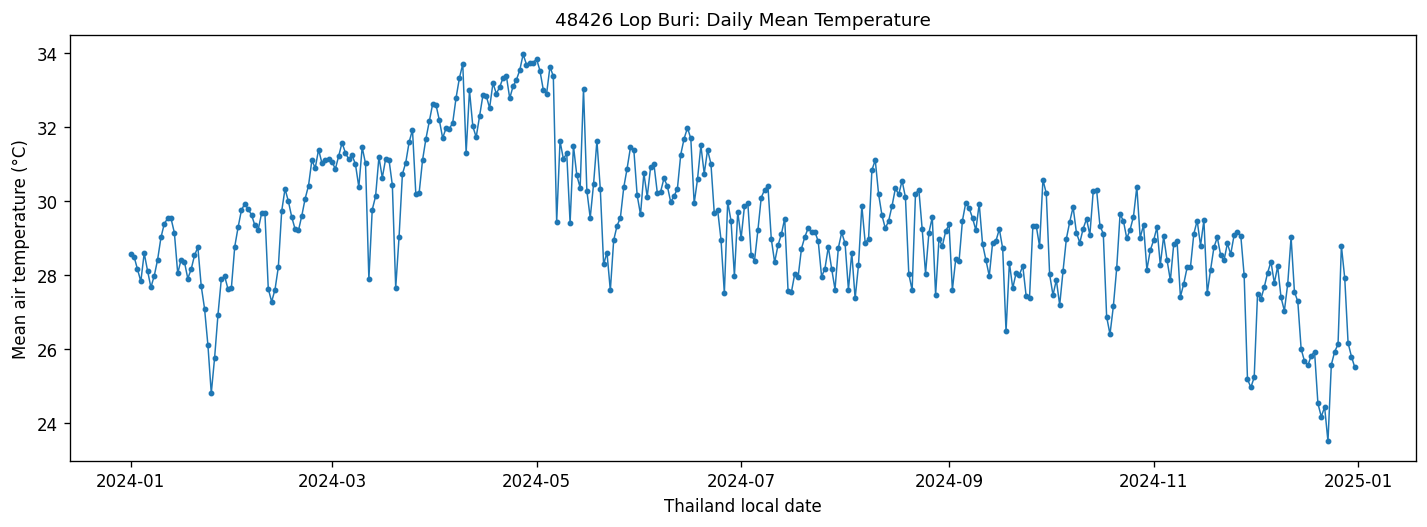

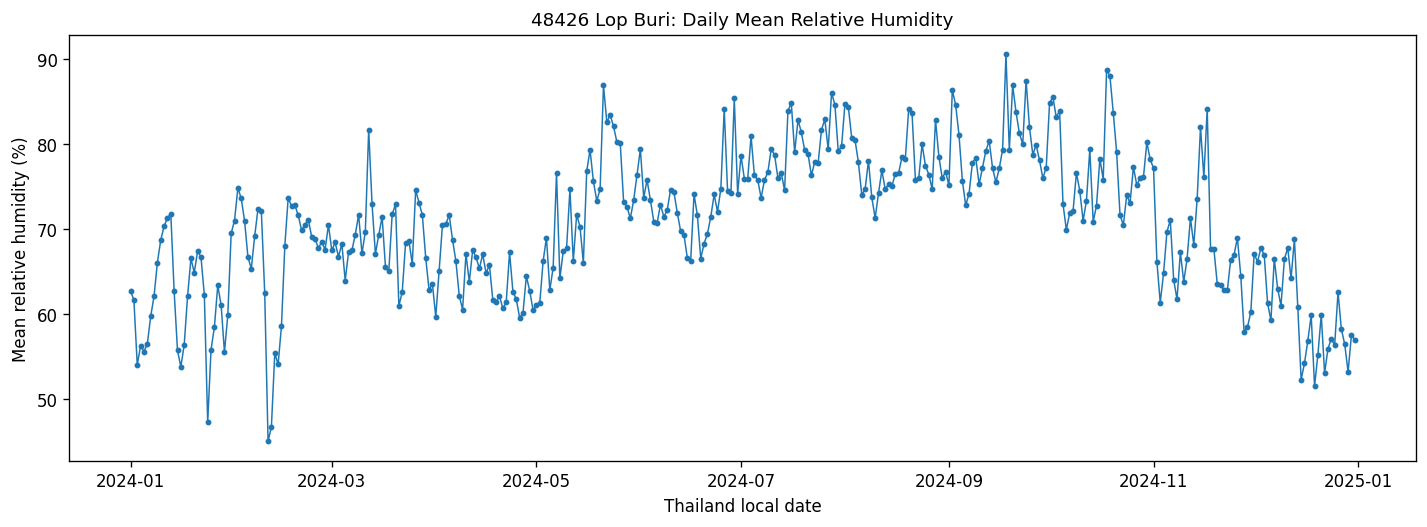

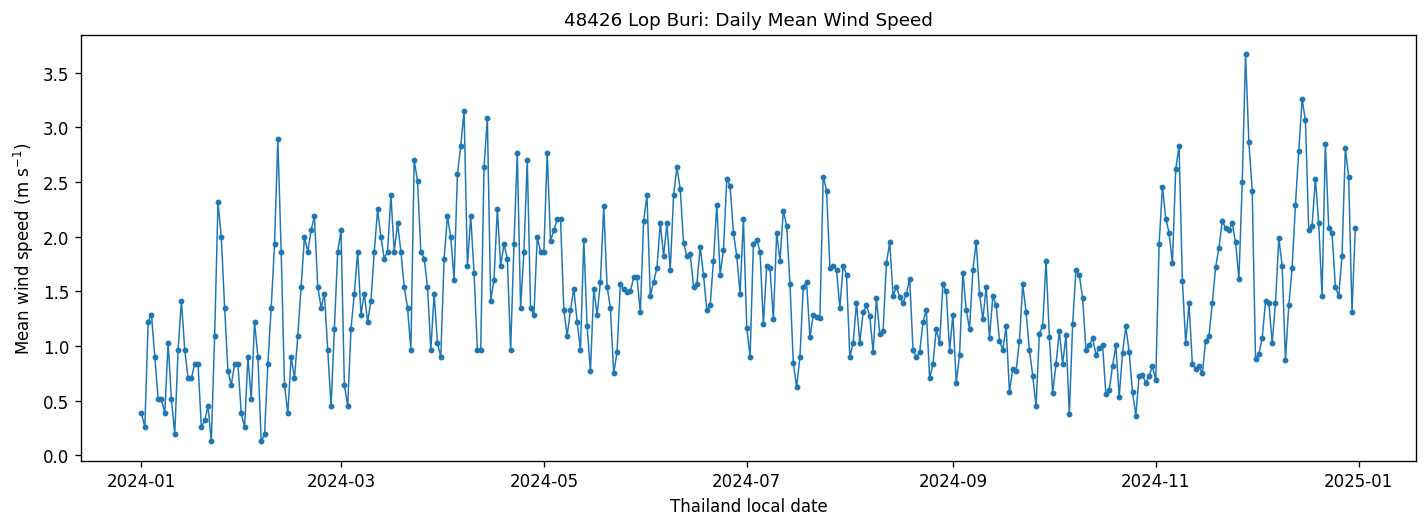

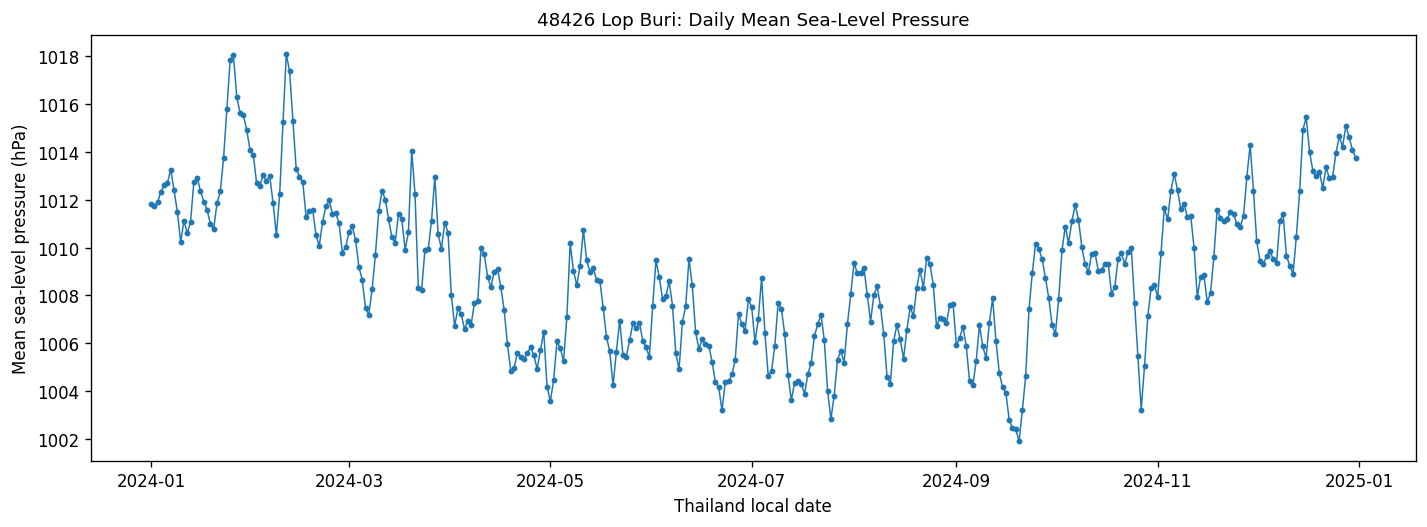

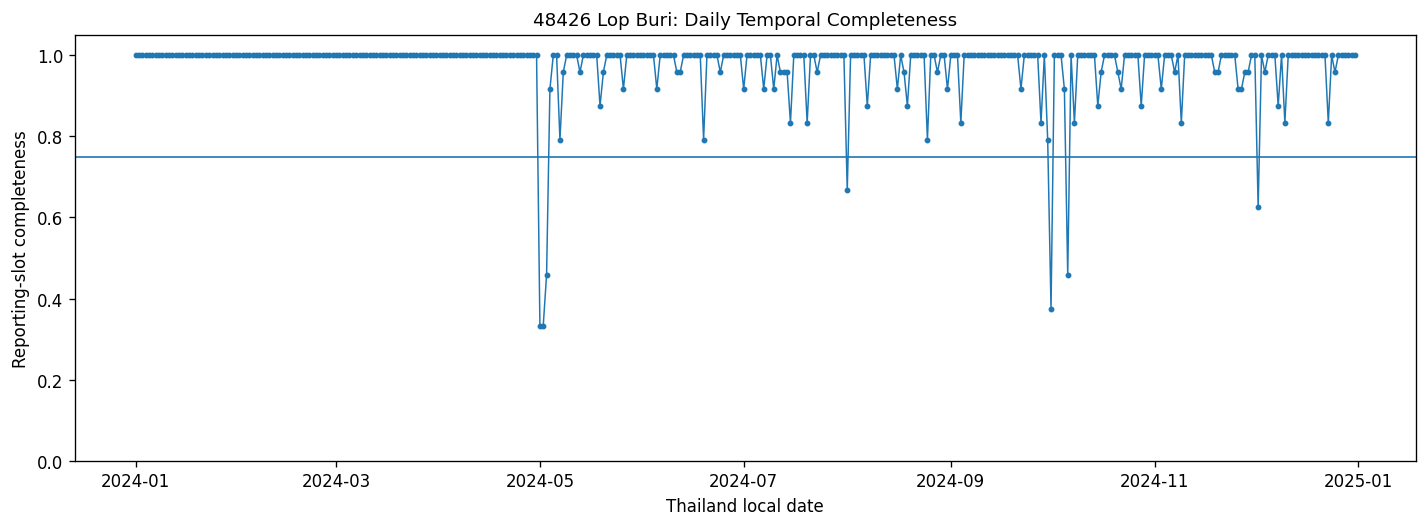

Saved diagnostic figures:
  /content/drive/MyDrive/Saraburi_PM25_Meteorology/LopBuri_48426/figures/Fig01_daily_temperature.png
  /content/drive/MyDrive/Saraburi_PM25_Meteorology/LopBuri_48426/figures/Fig02_daily_relative_humidity.png
  /content/drive/MyDrive/Saraburi_PM25_Meteorology/LopBuri_48426/figures/Fig03_daily_wind_speed.png
  /content/drive/MyDrive/Saraburi_PM25_Meteorology/LopBuri_48426/figures/Fig04_daily_sea_level_pressure.png
  /content/drive/MyDrive/Saraburi_PM25_Meteorology/LopBuri_48426/figures/Fig05_daily_reporting_completeness.png

✅ Cell 14 completed.
station station_name   mode selected_start_date selected_end_date  n_requested_local_days  n_manifest_resolved_local_days  n_unresolved_local_days  n_subdaily_observations  n_daily_rows  n_daily_all_core_QA_pass
  48426     Lop Buri CUSTOM          2024-01-01        2024-12-31                     366                             366                        0                     6639           366                       121


In [ ]:




# ==========================================================================================
# COPY AS CODE CELL 02
# ==========================================================================================
# =====================================================================
# CELL 02 — STATION METADATA
# =====================================================================

STATION_META = {
    "wmo": STATION_WMO,
    "name": STATION_NAME,
    "latitude": 14 + 47/60 + 58/3600,
    "longitude": 100 + 37/60 + 41/3600,
    "altitude_m": 10,
    "country": "Thailand"
}

station_meta_df = pd.DataFrame(
    [STATION_META]
)

station_meta_df.to_csv(
    ROOT_DIR / "station_metadata.csv",
    index=False,
    encoding="utf-8-sig"
)

print(station_meta_df.to_string(index=False))
print("\n✅ Cell 02 completed.")


# ==========================================================================================
# COPY AS CODE CELL 03
# ==========================================================================================
# =====================================================================
# CELL 03 — THAILAND-LOCAL DATE → SAFE UTC REQUEST WINDOW
# =====================================================================

def local_dates_to_utc_request_dates(
    local_start_date,
    local_end_date
):
    """
    Convert an inclusive Asia/Bangkok local-date interval to the UTC
    calendar dates that Ogimet must retrieve to fully cover that interval.
    """

    local_start = pd.Timestamp(
        local_start_date,
        tz=LOCAL_TZ
    )

    local_end_exclusive = (
        pd.Timestamp(
            local_end_date,
            tz=LOCAL_TZ
        )
        +
        pd.Timedelta(days=1)
    )

    utc_start = local_start.tz_convert(
        "UTC"
    )

    utc_end_exclusive = (
        local_end_exclusive.tz_convert(
            "UTC"
        )
    )

    utc_request_start = (
        utc_start.floor("D").date()
    )

    utc_request_end = (
        (
            utc_end_exclusive
            -
            pd.Timedelta(microseconds=1)
        )
        .floor("D")
        .date()
    )

    return (
        str(utc_request_start),
        str(utc_request_end)
    )


def crop_to_exact_local_dates(
    df,
    local_start_date,
    local_end_date,
    datetime_utc_col="datetime_utc"
):
    """
    Convert UTC timestamps to Asia/Bangkok and keep only observations
    within the requested inclusive Thailand-local calendar dates.
    """

    d = df.copy()

    d[datetime_utc_col] = pd.to_datetime(
        d[datetime_utc_col],
        utc=True,
        errors="coerce"
    )

    d["datetime_local"] = (
        d[datetime_utc_col]
        .dt.tz_convert(LOCAL_TZ)
    )

    start_local = pd.Timestamp(
        local_start_date,
        tz=LOCAL_TZ
    )

    end_local_exclusive = (
        pd.Timestamp(
            local_end_date,
            tz=LOCAL_TZ
        )
        +
        pd.Timedelta(days=1)
    )

    d = d[
        (
            d["datetime_local"]
            >=
            start_local
        )
        &
        (
            d["datetime_local"]
            <
            end_local_exclusive
        )
    ].copy()

    d["date_local"] = (
        d["datetime_local"]
        .dt.date
    )

    d["hour_local"] = (
        d["datetime_local"]
        .dt.hour
    )

    return d


utc_request_start, utc_request_end = (
    local_dates_to_utc_request_dates(
        SELECTED_START_DATE,
        SELECTED_END_DATE
    )
)

print(
    "Requested Thailand-local dates:",
    SELECTED_START_DATE,
    "to",
    SELECTED_END_DATE
)
print(
    "Safe Ogimet UTC calendar dates:",
    utc_request_start,
    "to",
    utc_request_end
)

print("\n✅ Cell 03 completed.")


# ==========================================================================================
# COPY AS CODE CELL 04
# ==========================================================================================
# =====================================================================
# CELL 04 — CREATE R OGIMET SYNOP WORKER
# =====================================================================

R_WORKER = Path(
    "/content/lopburi_ogimet_worker.R"
)

R_WORKER.write_text(
    r"""
site_lib <- "/usr/local/lib/R/site-library"
.libPaths(c(site_lib, .libPaths()))

args <- commandArgs(trailingOnly = TRUE)

if (length(args) < 6) {
  stop(
    "Usage: Rscript worker.R MODE STATION START END OUT_COMPACT OUT_FULL"
  )
}

mode <- args[1]
station <- args[2]
start_date <- args[3]
end_date <- args[4]
out_compact <- args[5]
out_full <- args[6]

suppressPackageStartupMessages(
  library(
    climate,
    lib.loc = site_lib
  )
)

safe_write <- function(x, path) {
  if (is.null(x)) return(FALSE)

  if (!is.data.frame(x)) {
    x <- as.data.frame(x)
  }

  write.csv(
    x,
    path,
    row.names = FALSE,
    na = ""
  )

  TRUE
}

if (mode == "synop") {

  result <- tryCatch(
    climate::meteo_ogimet(
      interval = "hourly",
      date = c(
        start_date,
        end_date
      ),
      station = station,
      source = "synop",
      return_list = TRUE,
      allow_failure = TRUE
    ),
    error = function(e) {
      message(
        "ERROR: ",
        conditionMessage(e)
      )

      NULL
    }
  )

  if (is.null(result)) {
    quit(
      status = 2
    )
  }

  compact <- result$data
  full <- result$full

  if (
    is.null(compact)
    ||
    nrow(compact) == 0
  ) {
    quit(
      status = 3
    )
  }

  if ("date" %in% names(compact)) {
    compact$date_utc_iso <- format(
      as.POSIXct(
        compact$date,
        tz = "UTC"
      ),
      "%Y-%m-%dT%H:%M:%SZ",
      tz = "UTC"
    )
  }

  if (
    !is.null(full)
    &&
    nrow(full) > 0
    &&
    "Date" %in% names(full)
  ) {
    full$date_utc_iso <- format(
      as.POSIXct(
        full$Date,
        tz = "UTC"
      ),
      "%Y-%m-%dT%H:%M:%SZ",
      tz = "UTC"
    )
  }

  ok1 <- safe_write(
    compact,
    out_compact
  )

  ok2 <- safe_write(
    full,
    out_full
  )

  cat(
    "Compact rows:",
    nrow(compact),
    "\n"
  )

  cat(
    "Full rows:",
    ifelse(
      is.null(full),
      0,
      nrow(full)
    ),
    "\n"
  )

  if (!ok1) {
    quit(
      status = 4
    )
  }

} else {

  stop(
    "Unknown mode: ",
    mode
  )
}
""",
    encoding="utf-8"
)

print("R worker created:", R_WORKER)
print(
    R_WORKER.read_text(
        encoding="utf-8"
    )[:1800]
)

print("\n✅ Cell 04 completed.")


# ==========================================================================================
# COPY AS CODE CELL 05
# ==========================================================================================
# =====================================================================
# CELL 05 — ADAPTIVE + RESUMABLE DOWNLOADER
# =====================================================================

MASTER_MANIFEST = (
    LOG_DIR
    /
    "download_manifest.csv"
)


def normalize_station_id(
    value
):
    return (
        str(value)
        .strip()
        .replace(".0", "")
        .zfill(5)
    )


def run_r_synop_request(
    station,
    utc_start_date,
    utc_end_date,
    compact_file,
    full_file,
    timeout_seconds=300
):
    """
    Execute one climate::meteo_ogimet() request in a separate R process.
    """

    cmd = [
        "Rscript",
        str(R_WORKER),
        "synop",
        normalize_station_id(station),
        str(utc_start_date),
        str(utc_end_date),
        str(compact_file),
        str(full_file),
    ]

    started = time.time()

    try:

        proc = subprocess.run(
            cmd,
            capture_output=True,
            text=True,
            timeout=timeout_seconds
        )

        return {
            "status":
            (
                "SUCCESS"
                if proc.returncode == 0
                else "FAILED"
            ),
            "returncode":
            proc.returncode,
            "elapsed_s":
            round(
                time.time()
                -
                started,
                1
            ),
            "stdout":
            proc.stdout.strip(),
            "stderr":
            proc.stderr.strip()
        }

    except subprocess.TimeoutExpired as e:

        return {
            "status":
            "TIMEOUT",
            "returncode":
            np.nan,
            "elapsed_s":
            round(
                time.time()
                -
                started,
                1
            ),
            "stdout":
            str(
                e.stdout
                or ""
            ),
            "stderr":
            str(
                e.stderr
                or ""
            )
        }


def chunk_file_paths(
    local_start,
    local_end
):
    """
    Stable file names are based on Thailand-local dates.
    """

    local_start_text = str(
        pd.Timestamp(
            local_start
        ).date()
    )

    local_end_text = str(
        pd.Timestamp(
            local_end
        ).date()
    )

    stem = (
        f"{STATION_WMO}_"
        f"{local_start_text}_"
        f"{local_end_text}"
    )

    return (
        RAW_COMPACT_DIR
        /
        f"{stem}_compact.csv",
        RAW_FULL_DIR
        /
        f"{stem}_full.csv"
    )


def validate_existing_compact_file(
    compact_file
):
    """
    A cached chunk is considered reusable only if it exists and contains
    at least one decoded observation.
    """

    compact_file = Path(
        compact_file
    )

    if not compact_file.exists():
        return False, 0

    try:

        d = pd.read_csv(
            compact_file
        )

        return (
            len(d) > 0,
            len(d)
        )

    except Exception:

        return False, 0


def request_one_local_block(
    local_start,
    local_end,
    overwrite=False
):
    """
    Request one Thailand-local block with retry waits.

    Returns a manifest row. A failed multi-day block may later be split.
    """

    local_start = pd.Timestamp(
        local_start
    ).date()

    local_end = pd.Timestamp(
        local_end
    ).date()

    compact_file, full_file = (
        chunk_file_paths(
            local_start,
            local_end
        )
    )

    if not overwrite:

        cached_ok, cached_rows = (
            validate_existing_compact_file(
                compact_file
            )
        )

        if cached_ok:

            utc_start, utc_end = (
                local_dates_to_utc_request_dates(
                    local_start,
                    local_end
                )
            )

            return {
                "station":
                STATION_WMO,
                "local_start_date":
                str(local_start),
                "local_end_date":
                str(local_end),
                "utc_request_start_date":
                utc_start,
                "utc_request_end_date":
                utc_end,
                "n_local_days":
                (
                    pd.Timestamp(local_end)
                    -
                    pd.Timestamp(local_start)
                ).days
                +
                1,
                "status":
                "SUCCESS_CACHED",
                "success":
                True,
                "n_messages":
                cached_rows,
                "attempts":
                0,
                "compact_file":
                str(compact_file),
                "full_file":
                str(full_file),
                "stderr":
                ""
            }

    utc_start, utc_end = (
        local_dates_to_utc_request_dates(
            local_start,
            local_end
        )
    )

    last_log = {}

    for attempt, wait_seconds in enumerate(
        RETRY_WAITS_SECONDS,
        start=1
    ):

        if wait_seconds > 0:
            time.sleep(
                wait_seconds
            )

        log = run_r_synop_request(
            station=STATION_WMO,
            utc_start_date=utc_start,
            utc_end_date=utc_end,
            compact_file=compact_file,
            full_file=full_file,
            timeout_seconds=300
        )

        last_log = log

        if (
            log["status"]
            ==
            "SUCCESS"
        ):

            ok, n_rows = (
                validate_existing_compact_file(
                    compact_file
                )
            )

            if ok:

                return {
                    "station":
                    STATION_WMO,
                    "local_start_date":
                    str(local_start),
                    "local_end_date":
                    str(local_end),
                    "utc_request_start_date":
                    utc_start,
                    "utc_request_end_date":
                    utc_end,
                    "n_local_days":
                    (
                        pd.Timestamp(local_end)
                        -
                        pd.Timestamp(local_start)
                    ).days
                    +
                    1,
                    "status":
                    "SUCCESS_DOWNLOADED",
                    "success":
                    True,
                    "n_messages":
                    n_rows,
                    "attempts":
                    attempt,
                    "compact_file":
                    str(compact_file),
                    "full_file":
                    str(full_file),
                    "stderr":
                    log.get(
                        "stderr",
                        ""
                    )[:500]
                }

    return {
        "station":
        STATION_WMO,
        "local_start_date":
        str(local_start),
        "local_end_date":
        str(local_end),
        "utc_request_start_date":
        utc_start,
        "utc_request_end_date":
        utc_end,
        "n_local_days":
        (
            pd.Timestamp(local_end)
            -
            pd.Timestamp(local_start)
        ).days
        +
        1,
        "status":
        "UNRESOLVED_NO_RETURN",
        "success":
        False,
        "n_messages":
        0,
        "attempts":
        len(RETRY_WAITS_SECONDS),
        "compact_file":
        str(compact_file),
        "full_file":
        str(full_file),
        "stderr":
        last_log.get(
            "stderr",
            ""
        )[:500]
    }


def adaptive_download_local_block(
    local_start,
    local_end,
    overwrite=False
):
    """
    Recursively split a failed local-date block until one-day blocks.
    """

    local_start = pd.Timestamp(
        local_start
    ).date()

    local_end = pd.Timestamp(
        local_end
    ).date()

    final_rows = []

    def recurse(
        start_i,
        end_i,
        depth=0
    ):

        result = request_one_local_block(
            start_i,
            end_i,
            overwrite=overwrite
        )

        result["depth"] = depth

        if result["success"]:

            final_rows.append(
                result
            )

            return

        n_days = (
            pd.Timestamp(end_i)
            -
            pd.Timestamp(start_i)
        ).days + 1

        if n_days <= 1:

            final_rows.append(
                result
            )

            return

        left_days = (
            n_days
            //
            2
        )

        left_end = (
            pd.Timestamp(start_i)
            +
            pd.Timedelta(
                days=left_days - 1
            )
        ).date()

        right_start = (
            pd.Timestamp(left_end)
            +
            pd.Timedelta(days=1)
        ).date()

        recurse(
            start_i,
            left_end,
            depth + 1
        )

        recurse(
            right_start,
            end_i,
            depth + 1
        )

    recurse(
        local_start,
        local_end,
        depth=0
    )

    return pd.DataFrame(
        final_rows
    )


def successful_coverage_dates_from_manifest(
    manifest_df
):
    """
    Convert successful manifest ranges to a set of resolved Thailand-local dates.
    """

    covered = set()

    if manifest_df.empty:
        return covered

    successful = manifest_df[
        manifest_df["success"] == True
    ]

    for _, row in successful.iterrows():

        dates = pd.date_range(
            row["local_start_date"],
            row["local_end_date"],
            freq="D"
        )

        for d in dates:
            covered.add(
                d.date()
            )

    return covered


def load_master_manifest():
    if not MASTER_MANIFEST.exists():
        return pd.DataFrame()

    try:
        return pd.read_csv(
            MASTER_MANIFEST
        )
    except Exception:
        return pd.DataFrame()


def save_master_manifest(
    new_rows
):
    """
    Append new rows and remove exact duplicate manifest records.
    """

    old = load_master_manifest()

    combined = pd.concat(
        [
            old,
            new_rows
        ],
        ignore_index=True
    )

    if not combined.empty:

        combined = (
            combined
            .drop_duplicates(
                subset=[
                    "station",
                    "local_start_date",
                    "local_end_date",
                    "status",
                    "compact_file"
                ],
                keep="last"
            )
            .reset_index(
                drop=True
            )
        )

    combined.to_csv(
        MASTER_MANIFEST,
        index=False,
        encoding="utf-8-sig"
    )

    return combined


print("Adaptive/resumable downloader is ready.")
print("Manifest:", MASTER_MANIFEST)
print("\n✅ Cell 05 completed.")


# ==========================================================================================
# COPY AS CODE CELL 06
# ==========================================================================================
# =====================================================================
# CELL 06 — DOWNLOAD SELECTED DATE RANGE
# =====================================================================

existing_manifest = (
    load_master_manifest()
)

resolved_dates = (
    successful_coverage_dates_from_manifest(
        existing_manifest
    )
)

selected_dates = pd.date_range(
    SELECTED_START_DATE,
    SELECTED_END_DATE,
    freq="D"
)

unresolved_dates = [
    d.date()
    for d in selected_dates
    if d.date()
    not in resolved_dates
]

print(
    "Selected local days:",
    len(selected_dates)
)

print(
    "Already resolved from manifest:",
    len(selected_dates)
    -
    len(unresolved_dates)
)

print(
    "Still to process:",
    len(unresolved_dates)
)


if unresolved_dates:

    # Build consecutive top-level blocks from unresolved dates.
    unresolved_dates = sorted(
        unresolved_dates
    )

    block_starts = []

    current_start = unresolved_dates[0]
    current_end = unresolved_dates[0]

    for next_date in unresolved_dates[1:]:

        consecutive = (
            next_date
            ==
            current_end
            +
            timedelta(days=1)
        )

        current_length = (
            current_end
            -
            current_start
        ).days + 1

        if (
            consecutive
            and
            current_length
            <
            INITIAL_LOCAL_CHUNK_DAYS
        ):

            current_end = next_date

        else:

            block_starts.append(
                (
                    current_start,
                    current_end
                )
            )

            current_start = next_date
            current_end = next_date

    block_starts.append(
        (
            current_start,
            current_end
        )
    )

    print(
        "Top-level blocks:",
        len(block_starts)
    )

    for block_number, (
        block_start,
        block_end
    ) in enumerate(
        block_starts,
        start=1
    ):

        print(
            f"\n[{block_number}/{len(block_starts)}] "
            f"Thailand local: {block_start} → {block_end}"
        )

        block_manifest = (
            adaptive_download_local_block(
                block_start,
                block_end,
                overwrite=False
            )
        )

        if not block_manifest.empty:

            print(
                block_manifest[
                    [
                        "local_start_date",
                        "local_end_date",
                        "status",
                        "n_messages",
                        "attempts",
                        "depth"
                    ]
                ]
                .to_string(
                    index=False
                )
            )

            master_manifest = (
                save_master_manifest(
                    block_manifest
                )
            )

        time.sleep(
            PAUSE_BETWEEN_TOPLEVEL_CHUNKS_SECONDS
        )

else:

    print(
        "All selected days are already covered by successful cached chunks."
    )


master_manifest = (
    load_master_manifest()
)

master_manifest.to_csv(
    LOG_DIR / "download_manifest_current.csv",
    index=False,
    encoding="utf-8-sig"
)

print(
    "\nCurrent manifest rows:",
    len(master_manifest)
)

print(
    "Successful manifest rows:",
    int(
        master_manifest[
            "success"
        ]
        .fillna(False)
        .sum()
    )
    if (
        not master_manifest.empty
        and
        "success"
        in master_manifest.columns
    )
    else 0
)

print(
    "\n✅ Cell 06 completed."
)


# ==========================================================================================
# COPY AS CODE CELL 07
# ==========================================================================================
# =====================================================================
# CELL 07 — COMBINE + DEDUPLICATE COMPACT SYNOP
# =====================================================================

compact_parts = []

for path in sorted(
    RAW_COMPACT_DIR.glob(
        "*_compact.csv"
    )
):

    try:

        d = pd.read_csv(
            path
        )

        if d.empty:
            continue

        d["source_compact_file"] = (
            path.name
        )

        if "station" in d.columns:

            d["station"] = (
                d["station"]
                .map(
                    normalize_station_id
                )
            )

        else:

            d["station"] = STATION_WMO

        if "date_utc_iso" in d.columns:

            d["datetime_utc"] = pd.to_datetime(
                d["date_utc_iso"],
                utc=True,
                errors="coerce"
            )

        elif "date" in d.columns:

            d["datetime_utc"] = pd.to_datetime(
                d["date"],
                utc=True,
                errors="coerce"
            )

        else:

            continue

        compact_parts.append(
            d
        )

    except Exception as e:

        print(
            "Could not read:",
            path.name,
            repr(e)
        )


if not compact_parts:

    raise RuntimeError(
        "No compact SYNOP data files were found."
    )


compact_all = pd.concat(
    compact_parts,
    ignore_index=True
)


compact_all = (
    compact_all
    .dropna(
        subset=[
            "datetime_utc"
        ]
    )
    .drop_duplicates(
        subset=[
            "station",
            "datetime_utc"
        ],
        keep="last"
    )
    .sort_values(
        "datetime_utc"
    )
    .reset_index(
        drop=True
    )
)


compact_selected = (
    crop_to_exact_local_dates(
        compact_all,
        SELECTED_START_DATE,
        SELECTED_END_DATE,
        datetime_utc_col=
        "datetime_utc"
    )
)


numeric_compact_cols = [
    "t2m",
    "dpt2m",
    "rel_hum",
    "tmax",
    "tmin",
    "wd",
    "ws",
    "gust",
    "press",
    "slp",
    "press_tend",
    "precip",
    "Nt",
    "Nh",
    "N_base",
    "insol",
    "visibility",
    "snow"
]


for column in numeric_compact_cols:

    if column in compact_selected.columns:

        compact_selected[
            column
        ] = pd.to_numeric(
            compact_selected[
                column
            ],
            errors="coerce"
        )


compact_selected.to_csv(
    PROCESSED_DIR
    /
    (
        f"{STATION_WMO}_{STATION_NAME.replace(' ', '')}_"
        f"compact_subdaily_"
        f"{SELECTED_START_DATE}_{SELECTED_END_DATE}.csv"
    ),
    index=False,
    encoding="utf-8-sig"
)


print(
    "Compact observations after deduplication/cropping:",
    len(compact_selected)
)

print(
    "Local span:",
    compact_selected[
        "datetime_local"
    ].min(),
    "to",
    compact_selected[
        "datetime_local"
    ].max()
)

print(
    "\nCompact fields:"
)
print(
    compact_selected.columns.tolist()
)

print(
    "\n✅ Cell 07 completed."
)


# ==========================================================================================
# COPY AS CODE CELL 08
# ==========================================================================================
# =====================================================================
# CELL 08 — COMBINE + DEDUPLICATE FULL SYNOP PARSER OUTPUT
# =====================================================================

full_parts = []

for path in sorted(
    RAW_FULL_DIR.glob(
        "*_full.csv"
    )
):

    try:

        f = pd.read_csv(
            path
        )

        if f.empty:
            continue

        f["source_full_file"] = (
            path.name
        )

        station_col = (
            "station_id"
            if "station_id" in f.columns
            else None
        )

        if station_col is not None:

            f["station"] = (
                f[station_col]
                .map(
                    normalize_station_id
                )
            )

        else:

            f["station"] = (
                STATION_WMO
            )

        if "date_utc_iso" in f.columns:

            f["datetime_utc"] = (
                pd.to_datetime(
                    f["date_utc_iso"],
                    utc=True,
                    errors="coerce"
                )
            )

        elif "Date" in f.columns:

            f["datetime_utc"] = (
                pd.to_datetime(
                    f["Date"],
                    utc=True,
                    errors="coerce"
                )
            )

        else:

            continue

        full_parts.append(
            f
        )

    except Exception as e:

        print(
            "Could not read:",
            path.name,
            repr(e)
        )


if full_parts:

    full_all = pd.concat(
        full_parts,
        ignore_index=True
    )

    full_all = (
        full_all
        .dropna(
            subset=[
                "datetime_utc"
            ]
        )
        .drop_duplicates(
            subset=[
                "station",
                "datetime_utc"
            ],
            keep="last"
        )
        .sort_values(
            "datetime_utc"
        )
        .reset_index(
            drop=True
        )
    )

    full_selected = (
        crop_to_exact_local_dates(
            full_all,
            SELECTED_START_DATE,
            SELECTED_END_DATE,
            datetime_utc_col=
            "datetime_utc"
        )
    )

else:

    full_selected = pd.DataFrame()


full_output_path = (
    PROCESSED_DIR
    /
    (
        f"{STATION_WMO}_{STATION_NAME.replace(' ', '')}_"
        f"full_SYNOPT_parser_"
        f"{SELECTED_START_DATE}_{SELECTED_END_DATE}.csv"
    )
)


full_selected.to_csv(
    full_output_path,
    index=False,
    encoding="utf-8-sig"
)


print(
    "Full-parser observations after deduplication/cropping:",
    len(full_selected)
)

print(
    "Full parser saved to:",
    full_output_path
)

print(
    "\n✅ Cell 08 completed."
)


# ==========================================================================================
# COPY AS CODE CELL 09
# ==========================================================================================
# =====================================================================
# CELL 09 — HARMONIZE SUBDAILY DATA + CORRECT WIND UNITS
# =====================================================================

def convert_wind_speed_to_ms(
    speed,
    unit
):
    """
    Convert decoded full-SYNOP wind speed to m/s using the reported unit.
    """

    if pd.isna(speed):
        return np.nan

    unit = str(
        unit
    ).strip().upper()

    if unit in {
        "M/S",
        "MPS",
        "MS",
        "M S-1",
        "M S^-1"
    }:

        return float(
            speed
        )

    if unit in {
        "KT",
        "KTS",
        "KNOT",
        "KNOTS"
    }:

        return (
            float(speed)
            *
            0.514444
        )

    return np.nan


# Start with compact variables.
subdaily = compact_selected.copy()


# Preserve compact wind as diagnostic only.
if "ws" in subdaily.columns:
    subdaily = subdaily.rename(
        columns={
            "ws":
            "wind_speed_compact_raw"
        }
    )

if "wd" in subdaily.columns:
    subdaily = subdaily.rename(
        columns={
            "wd":
            "wind_direction_compact_deg"
        }
    )


# Add full-parser wind variables.
if not full_selected.empty:

    wind_cols = [
        c
        for c in [
            "station",
            "datetime_utc",
            "wind_speed",
            "wind_direction",
            "wind_unit",
            "wind_estimated"
        ]
        if c in full_selected.columns
    ]

    full_wind = full_selected[
        wind_cols
    ].copy()

    rename_wind = {}

    if "wind_speed" in full_wind.columns:
        rename_wind[
            "wind_speed"
        ] = "wind_speed_raw"

    if "wind_direction" in full_wind.columns:
        rename_wind[
            "wind_direction"
        ] = "wind_direction_deg"

    if "wind_unit" in full_wind.columns:
        rename_wind[
            "wind_unit"
        ] = "wind_unit_raw"

    full_wind = full_wind.rename(
        columns=
        rename_wind
    )

    subdaily = subdaily.merge(
        full_wind,
        on=[
            "station",
            "datetime_utc"
        ],
        how="left"
    )

else:

    subdaily[
        "wind_speed_raw"
    ] = np.nan

    subdaily[
        "wind_direction_deg"
    ] = np.nan

    subdaily[
        "wind_unit_raw"
    ] = "UNKNOWN"


subdaily[
    "wind_speed_raw"
] = pd.to_numeric(
    subdaily[
        "wind_speed_raw"
    ],
    errors="coerce"
)


subdaily[
    "wind_direction_deg"
] = pd.to_numeric(
    subdaily[
        "wind_direction_deg"
    ],
    errors="coerce"
)


subdaily[
    "wind_speed_ms"
] = [
    convert_wind_speed_to_ms(
        speed,
        unit
    )
    for speed, unit
    in zip(
        subdaily[
            "wind_speed_raw"
        ],
        subdaily[
            "wind_unit_raw"
        ]
    )
]


# Calm wind with missing direction is still usable as a zero vector.
calm = (
    subdaily[
        "wind_speed_ms"
    ] == 0
)

subdaily.loc[
    calm
    &
    subdaily[
        "wind_direction_deg"
    ].isna(),
    "wind_direction_deg"
] = 0.0


valid_wind = (
    subdaily[
        "wind_speed_ms"
    ].notna()
    &
    subdaily[
        "wind_direction_deg"
    ].between(
        0,
        360,
        inclusive="both"
    )
)


theta = np.deg2rad(
    subdaily.loc[
        valid_wind,
        "wind_direction_deg"
    ]
)


speed = subdaily.loc[
    valid_wind,
    "wind_speed_ms"
]


subdaily[
    "u_ms"
] = np.nan

subdaily[
    "v_ms"
] = np.nan


subdaily.loc[
    valid_wind,
    "u_ms"
] = (
    -speed
    *
    np.sin(theta)
)


subdaily.loc[
    valid_wind,
    "v_ms"
] = (
    -speed
    *
    np.cos(theta)
)


# ---------------------------------------------------------------------
# Relative humidity fallback from T/Td.
# ---------------------------------------------------------------------
def rh_from_t_td(
    t_c,
    td_c
):
    """
    Magnus-type RH estimate from air temperature and dew point.
    """

    if (
        pd.isna(t_c)
        or
        pd.isna(td_c)
    ):
        return np.nan

    a = 17.625
    b = 243.04

    es_td = np.exp(
        a * td_c
        /
        (
            b
            +
            td_c
        )
    )

    es_t = np.exp(
        a * t_c
        /
        (
            b
            +
            t_c
        )
    )

    rh = (
        100.0
        *
        es_td
        /
        es_t
    )

    return float(
        np.clip(
            rh,
            0,
            100
        )
    )


subdaily[
    "rh_calculated_pct"
] = [
    rh_from_t_td(
        t,
        td
    )
    for t, td
    in zip(
        subdaily.get(
            "t2m",
            pd.Series(
                np.nan,
                index=subdaily.index
            )
        ),
        subdaily.get(
            "dpt2m",
            pd.Series(
                np.nan,
                index=subdaily.index
            )
        )
    )
]


if "rel_hum" in subdaily.columns:

    if DERIVE_RH_FROM_T_TD_IF_MISSING:

        subdaily[
            "rh_used_pct"
        ] = (
            subdaily[
                "rel_hum"
            ]
            .where(
                subdaily[
                    "rel_hum"
                ].notna(),
                subdaily[
                    "rh_calculated_pct"
                ]
            )
        )

    else:

        subdaily[
            "rh_used_pct"
        ] = (
            subdaily[
                "rel_hum"
            ]
        )

else:

    subdaily[
        "rh_used_pct"
    ] = (
        subdaily[
            "rh_calculated_pct"
        ]
        if DERIVE_RH_FROM_T_TD_IF_MISSING
        else np.nan
    )


# ---------------------------------------------------------------------
# Wind unit audit.
# ---------------------------------------------------------------------
wind_unit_audit = (
    subdaily
    .groupby(
        "wind_unit_raw",
        dropna=False
    )
    .size()
    .rename(
        "n_observations"
    )
    .reset_index()
)


wind_unit_audit.to_csv(
    QA_DIR
    /
    "wind_unit_audit.csv",
    index=False,
    encoding="utf-8-sig"
)


subdaily_output = (
    PROCESSED_DIR
    /
    (
        f"{STATION_WMO}_{STATION_NAME.replace(' ', '')}_"
        f"subdaily_harmonized_"
        f"{SELECTED_START_DATE}_{SELECTED_END_DATE}.csv"
    )
)


subdaily.to_csv(
    subdaily_output,
    index=False,
    encoding="utf-8-sig"
)


print(
    "\nWIND UNIT AUDIT"
)
print(
    wind_unit_audit.to_string(
        index=False
    )
)

print(
    "\nHarmonized subdaily rows:",
    len(subdaily)
)

print(
    "Saved:",
    subdaily_output
)

print(
    "\n✅ Cell 09 completed."
)


# ==========================================================================================
# COPY AS CODE CELL 10
# ==========================================================================================
# =====================================================================
# CELL 10 — INFER STATION-MONTH REPORTING FREQUENCY
# =====================================================================

subdaily[
    "year"
] = (
    subdaily[
        "datetime_local"
    ]
    .dt.year
)

subdaily[
    "month"
] = (
    subdaily[
        "datetime_local"
    ]
    .dt.month
)

subdaily[
    "date_local"
] = (
    subdaily[
        "datetime_local"
    ]
    .dt.date
)

subdaily[
    "hour_local"
] = (
    subdaily[
        "datetime_local"
    ]
    .dt.hour
)


daily_slot_counts = (
    subdaily
    .groupby(
        [
            "year",
            "month",
            "date_local"
        ]
    )
    .agg(
        n_observations=(
            "datetime_local",
            "size"
        ),
        n_unique_hours=(
            "hour_local",
            "nunique"
        )
    )
    .reset_index()
)


def reporting_regime_label(
    expected_slots
):

    if pd.isna(expected_slots):
        return "UNKNOWN"

    expected_slots = float(
        expected_slots
    )

    if expected_slots >= 18:
        return "APPROX_HOURLY"

    if expected_slots >= 6:
        return "APPROX_3_HOURLY_OR_MIXED"

    if expected_slots >= 3:
        return "APPROX_6_HOURLY_OR_MIXED"

    return "SPARSE_OR_IRREGULAR"


frequency_rows = []

for (
    year,
    month
), g in daily_slot_counts.groupby(
    [
        "year",
        "month"
    ]
):

    # q75 avoids treating truncated boundary days as the expected schedule.
    q75_slots = (
        g[
            "n_unique_hours"
        ]
        .quantile(
            0.75
        )
    )

    expected_slots = max(
        1,
        int(
            round(
                q75_slots
            )
        )
    )

    frequency_rows.append({
        "year":
        int(year),
        "month":
        int(month),
        "n_days_with_data":
        len(g),
        "median_observations_per_day":
        g[
            "n_observations"
        ].median(),
        "q75_unique_hours_per_day":
        q75_slots,
        "expected_slots_per_day":
        expected_slots,
        "reporting_regime":
        reporting_regime_label(
            expected_slots
        )
    })


reporting_frequency = pd.DataFrame(
    frequency_rows
)


reporting_frequency.to_csv(
    QA_DIR
    /
    "reporting_frequency_by_station_month.csv",
    index=False,
    encoding="utf-8-sig"
)


print(
    reporting_frequency
    .to_string(
        index=False
    )
)

print(
    "\n✅ Cell 10 completed."
)


# ==========================================================================================
# COPY AS CODE CELL 11
# ==========================================================================================
# =====================================================================
# CELL 11 — DAYPART-BASED DAILY QA
# =====================================================================

def assign_daypart(
    hour
):

    hour = int(
        hour
    )

    if 0 <= hour < 6:
        return "00-06"

    if 6 <= hour < 12:
        return "06-12"

    if 12 <= hour < 18:
        return "12-18"

    return "18-24"


subdaily[
    "daypart"
] = (
    subdaily[
        "hour_local"
    ]
    .map(
        assign_daypart
    )
)


subdaily = subdaily.merge(
    reporting_frequency[
        [
            "year",
            "month",
            "expected_slots_per_day",
            "reporting_regime"
        ]
    ],
    on=[
        "year",
        "month"
    ],
    how="left"
)


qa_rows = []

for date_local, g in subdaily.groupby(
    "date_local",
    sort=True
):

    expected_slots_values = (
        g[
            "expected_slots_per_day"
        ]
        .dropna()
    )

    expected_slots = (
        int(
            expected_slots_values.iloc[0]
        )
        if len(
            expected_slots_values
        )
        else np.nan
    )

    unique_hours = (
        g[
            "hour_local"
        ]
        .nunique()
    )

    slot_fraction = (
        min(
            1.0,
            unique_hours
            /
            expected_slots
        )
        if (
            pd.notna(
                expected_slots
            )
            and
            expected_slots > 0
        )
        else np.nan
    )

    dayparts_present = (
        g[
            "daypart"
        ]
        .dropna()
        .nunique()
    )

    time_qa_pass = bool(
        pd.notna(
            slot_fraction
        )
        and
        slot_fraction
        >=
        DAILY_SLOT_COMPLETENESS_MIN
        and
        dayparts_present
        >=
        DAILY_MIN_DAYPARTS
    )

    def valid_fraction(
        column
    ):

        if column not in g.columns:
            return np.nan

        return (
            g[
                column
            ]
            .notna()
            .mean()
        )

    temp_fraction = valid_fraction(
        "t2m"
    )

    rh_fraction = valid_fraction(
        "rh_used_pct"
    )

    pressure_fraction = (
        np.maximum(
            valid_fraction(
                "press"
            ),
            valid_fraction(
                "slp"
            )
        )
    )

    wind_usable = (
        g[
            "wind_speed_ms"
        ].notna()
        &
        g[
            "u_ms"
        ].notna()
        &
        g[
            "v_ms"
        ].notna()
    )

    wind_fraction = (
        wind_usable.mean()
    )

    qa_rows.append({
        "date_local":
        pd.Timestamp(
            date_local
        ),
        "n_observations":
        len(g),
        "n_unique_hours":
        unique_hours,
        "expected_slots_per_day":
        expected_slots,
        "slot_completeness_fraction":
        slot_fraction,
        "n_dayparts_present":
        dayparts_present,
        "dayparts_present":
        "|".join(
            sorted(
                g[
                    "daypart"
                ]
                .dropna()
                .unique()
                .tolist()
            )
        ),
        "daily_time_QA_pass":
        time_qa_pass,
        "temperature_valid_fraction":
        temp_fraction,
        "rh_valid_fraction":
        rh_fraction,
        "wind_valid_fraction":
        wind_fraction,
        "pressure_valid_fraction":
        pressure_fraction,
        "temperature_QA_pass":
        bool(
            time_qa_pass
            and
            pd.notna(
                temp_fraction
            )
            and
            temp_fraction
            >=
            VARIABLE_VALID_FRACTION_MIN
        ),
        "rh_QA_pass":
        bool(
            time_qa_pass
            and
            pd.notna(
                rh_fraction
            )
            and
            rh_fraction
            >=
            VARIABLE_VALID_FRACTION_MIN
        ),
        "wind_QA_pass":
        bool(
            time_qa_pass
            and
            pd.notna(
                wind_fraction
            )
            and
            wind_fraction
            >=
            VARIABLE_VALID_FRACTION_MIN
        ),
        "pressure_QA_pass":
        bool(
            time_qa_pass
            and
            pd.notna(
                pressure_fraction
            )
            and
            pressure_fraction
            >=
            VARIABLE_VALID_FRACTION_MIN
        )
    })


daily_qa = pd.DataFrame(
    qa_rows
)


daily_qa[
    "all_core_variables_QA_pass"
] = (
    daily_qa[
        [
            "temperature_QA_pass",
            "rh_QA_pass",
            "wind_QA_pass",
            "pressure_QA_pass"
        ]
    ]
    .all(
        axis=1
    )
)


daily_qa.to_csv(
    QA_DIR
    /
    (
        f"daily_QA_"
        f"{SELECTED_START_DATE}_{SELECTED_END_DATE}.csv"
    ),
    index=False,
    encoding="utf-8-sig"
)


print(
    daily_qa
    .to_string(
        index=False
    )
)

print(
    "\nQA pass fractions:"
)

for column in [
    "daily_time_QA_pass",
    "temperature_QA_pass",
    "rh_QA_pass",
    "wind_QA_pass",
    "pressure_QA_pass",
    "all_core_variables_QA_pass"
]:

    print(
        f"{column:30s}",
        round(
            daily_qa[
                column
            ].mean(),
            3
        )
    )


print(
    "\n✅ Cell 11 completed."
)


# ==========================================================================================
# COPY AS CODE CELL 12
# ==========================================================================================
# =====================================================================
# CELL 12 — CREATE DAILY METEOROLOGICAL DATASET
# =====================================================================

def resultant_direction_from_uv(
    u_mean,
    v_mean
):

    if (
        not np.isfinite(
            u_mean
        )
        or
        not np.isfinite(
            v_mean
        )
    ):

        return np.nan

    if (
        u_mean == 0
        and
        v_mean == 0
    ):

        return np.nan

    return (
        np.degrees(
            np.arctan2(
                -u_mean,
                -v_mean
            )
        )
        +
        360
    ) % 360


daily_rows = []

for date_local, g in subdaily.groupby(
    "date_local",
    sort=True
):

    def mean_if(
        column
    ):

        if column not in g.columns:
            return np.nan

        return g[
            column
        ].mean()

    def min_if(
        column
    ):

        if column not in g.columns:
            return np.nan

        return g[
            column
        ].min()

    def max_if(
        column
    ):

        if column not in g.columns:
            return np.nan

        return g[
            column
        ].max()

    u_mean = mean_if(
        "u_ms"
    )

    v_mean = mean_if(
        "v_ms"
    )

    wind_resultant_ms = (
        np.sqrt(
            u_mean**2
            +
            v_mean**2
        )
        if (
            np.isfinite(
                u_mean
            )
            and
            np.isfinite(
                v_mean
            )
        )
        else np.nan
    )

    daily_rows.append({
        "date_local":
        pd.Timestamp(
            date_local
        ),
        "station":
        STATION_WMO,
        "station_name":
        STATION_NAME,
        "latitude":
        STATION_META[
            "latitude"
        ],
        "longitude":
        STATION_META[
            "longitude"
        ],
        "altitude_m":
        STATION_META[
            "altitude_m"
        ],
        "n_observations":
        len(g),
        "temperature_mean_c":
        mean_if(
            "t2m"
        ),
        "temperature_min_observed_c":
        min_if(
            "t2m"
        ),
        "temperature_max_observed_c":
        max_if(
            "t2m"
        ),
        "dewpoint_mean_c":
        mean_if(
            "dpt2m"
        ),
        "rh_mean_pct":
        mean_if(
            "rh_used_pct"
        ),
        "rh_raw_mean_pct":
        mean_if(
            "rel_hum"
        ),
        "wind_speed_scalar_mean_ms":
        mean_if(
            "wind_speed_ms"
        ),
        "wind_speed_max_ms":
        max_if(
            "wind_speed_ms"
        ),
        "u_mean_ms":
        u_mean,
        "v_mean_ms":
        v_mean,
        "wind_speed_resultant_ms":
        wind_resultant_ms,
        "wind_direction_resultant_deg":
        resultant_direction_from_uv(
            u_mean,
            v_mean
        ),
        "station_pressure_mean_hpa":
        mean_if(
            "press"
        ),
        "sea_level_pressure_mean_hpa":
        mean_if(
            "slp"
        ),
        "cloud_cover_mean_okta":
        mean_if(
            "Nt"
        ),
        "visibility_mean":
        mean_if(
            "visibility"
        )
    })


daily_met = pd.DataFrame(
    daily_rows
)


daily_met = daily_met.merge(
    daily_qa,
    on=[
        "date_local",
        "n_observations"
    ],
    how="left"
)


daily_met_output = (
    PROCESSED_DIR
    /
    (
        f"{STATION_WMO}_{STATION_NAME.replace(' ', '')}_"
        f"daily_meteorology_"
        f"{SELECTED_START_DATE}_{SELECTED_END_DATE}.csv"
    )
)


daily_met.to_csv(
    daily_met_output,
    index=False,
    encoding="utf-8-sig"
)


daily_met_pass = daily_met[
    daily_met[
        "all_core_variables_QA_pass"
    ] == True
].copy()


daily_met_pass_output = (
    PROCESSED_DIR
    /
    (
        f"{STATION_WMO}_{STATION_NAME.replace(' ', '')}_"
        f"daily_meteorology_QA_PASS_"
        f"{SELECTED_START_DATE}_{SELECTED_END_DATE}.csv"
    )
)


daily_met_pass.to_csv(
    daily_met_pass_output,
    index=False,
    encoding="utf-8-sig"
)


print(
    "Daily rows:",
    len(daily_met)
)

print(
    "All-core-variable QA PASS days:",
    len(daily_met_pass)
)

print(
    "\nDaily meteorology:"
)

print(
    daily_met
    .head(
        20
    )
    .round(
        3
    )
    .to_string(
        index=False
    )
)

print(
    "\nSaved:"
)
print(
    daily_met_output
)
print(
    daily_met_pass_output
)

print(
    "\n✅ Cell 12 completed."
)


# ==========================================================================================
# COPY AS CODE CELL 13
# ==========================================================================================
# =====================================================================
# CELL 13 — PRECIPITATION-INTERVAL ARCHIVE + OVERLAP DIAGNOSTIC
#
# No final daily rainfall is created here.
# =====================================================================

precip_intervals = pd.DataFrame()
precip_overlap_summary = pd.DataFrame()


if (
    not full_selected.empty
    and
    "precipitation_amount"
    in full_selected.columns
    and
    "precipitation_time"
    in full_selected.columns
):

    precip_intervals = full_selected.copy()

    precip_intervals[
        "precipitation_amount"
    ] = pd.to_numeric(
        precip_intervals[
            "precipitation_amount"
        ],
        errors="coerce"
    )

    precip_intervals[
        "precipitation_time"
    ] = pd.to_numeric(
        precip_intervals[
            "precipitation_time"
        ],
        errors="coerce"
    )

    precip_intervals = precip_intervals[
        precip_intervals[
            "precipitation_amount"
        ].notna()
        &
        precip_intervals[
            "precipitation_time"
        ].notna()
        &
        (
            precip_intervals[
                "precipitation_time"
            ]
            >
            0
        )
        &
        (
            precip_intervals[
                "precipitation_time"
            ]
            <=
            24
        )
    ].copy()

    precip_intervals[
        "accumulation_end_utc"
    ] = (
        precip_intervals[
            "datetime_utc"
        ]
    )

    precip_intervals[
        "accumulation_start_utc"
    ] = (
        precip_intervals[
            "accumulation_end_utc"
        ]
        -
        pd.to_timedelta(
            precip_intervals[
                "precipitation_time"
            ],
            unit="h"
        )
    )

    precip_intervals[
        "accumulation_end_local"
    ] = (
        precip_intervals[
            "accumulation_end_utc"
        ]
        .dt.tz_convert(
            LOCAL_TZ
        )
    )

    precip_intervals[
        "accumulation_start_local"
    ] = (
        precip_intervals[
            "accumulation_start_utc"
        ]
        .dt.tz_convert(
            LOCAL_TZ
        )
    )

    precip_intervals[
        "end_date_local"
    ] = (
        precip_intervals[
            "accumulation_end_local"
        ]
        .dt.date
    )

    precip_output = (
        PROCESSED_DIR
        /
        (
            f"{STATION_WMO}_{STATION_NAME.replace(' ', '')}_"
            f"precipitation_intervals_"
            f"{SELECTED_START_DATE}_{SELECTED_END_DATE}.csv"
        )
    )

    precip_cols = [
        c
        for c in [
            "station",
            "datetime_utc",
            "datetime_local",
            "accumulation_start_utc",
            "accumulation_end_utc",
            "accumulation_start_local",
            "accumulation_end_local",
            "precipitation_amount",
            "precipitation_time",
            "source"
        ]
        if c in precip_intervals.columns
    ]

    precip_intervals[
        precip_cols
    ].to_csv(
        precip_output,
        index=False,
        encoding="utf-8-sig"
    )

    overlap_rows = []

    for local_date, g in precip_intervals.groupby(
        "end_date_local",
        sort=True
    ):

        g = g.sort_values(
            "accumulation_start_utc"
        )

        previous_intervals = []
        overlaps = 0

        for _, row in g.iterrows():

            current_start = row[
                "accumulation_start_utc"
            ]

            current_end = row[
                "accumulation_end_utc"
            ]

            for prior_start, prior_end in previous_intervals:

                if (
                    current_start < prior_end
                    and
                    current_end > prior_start
                ):

                    overlaps += 1
                    break

            previous_intervals.append(
                (
                    current_start,
                    current_end
                )
            )

        overlap_rows.append({
            "date_local":
            str(local_date),
            "n_precipitation_reports":
            len(g),
            "n_overlapping_reports":
            overlaps,
            "reported_interval_hours_total":
            g[
                "precipitation_time"
            ].sum(),
            "naive_sum_mm_DIAGNOSTIC_ONLY":
            g[
                "precipitation_amount"
            ].sum(),
            "daily_rainfall_status":
            (
                "DO_NOT_NAIVELY_SUM_OVERLAPS_PRESENT"
                if overlaps > 0
                else
                "NO_OVERLAP_DETECTED_STILL_CHECK_DAY_BOUNDARY"
            )
        })

    precip_overlap_summary = pd.DataFrame(
        overlap_rows
    )

    precip_overlap_summary.to_csv(
        QA_DIR
        /
        "precipitation_overlap_diagnostic.csv",
        index=False,
        encoding="utf-8-sig"
    )

    print(
        precip_overlap_summary
        .head(
            30
        )
        .to_string(
            index=False
        )
    )

    print(
        "\nPrecipitation interval archive:",
        precip_output
    )

else:

    print(
        "No usable precipitation_amount / precipitation_time "
        "fields were available in the full parser."
    )


print(
    "\nNo final daily rainfall variable is created in this notebook."
)

print(
    "\n✅ Cell 13 completed."
)


# ==========================================================================================
# COPY AS CODE CELL 14
# ==========================================================================================
# =====================================================================
# CELL 14 — DIAGNOSTIC FIGURES
# =====================================================================

# ---------------- Temperature ----------------
fig, ax = plt.subplots(
    figsize=(
        12,
        4.5
    )
)

ax.plot(
    daily_met[
        "date_local"
    ],
    daily_met[
        "temperature_mean_c"
    ],
    marker="o",
    markersize=2.5,
    linewidth=0.9
)

ax.set_xlabel(
    "Thailand local date"
)

ax.set_ylabel(
    "Mean air temperature (°C)"
)

ax.set_title(
    f"{STATION_WMO} {STATION_NAME}: Daily Mean Temperature"
)

plt.tight_layout()

fig_temp = (
    FIG_DIR
    /
    "Fig01_daily_temperature.png"
)

plt.savefig(
    fig_temp,
    dpi=FIG_DPI,
    bbox_inches="tight"
)

plt.show()


# ---------------- Relative humidity ----------------
fig, ax = plt.subplots(
    figsize=(
        12,
        4.5
    )
)

ax.plot(
    daily_met[
        "date_local"
    ],
    daily_met[
        "rh_mean_pct"
    ],
    marker="o",
    markersize=2.5,
    linewidth=0.9
)

ax.set_xlabel(
    "Thailand local date"
)

ax.set_ylabel(
    "Mean relative humidity (%)"
)

ax.set_title(
    f"{STATION_WMO} {STATION_NAME}: Daily Mean Relative Humidity"
)

plt.tight_layout()

fig_rh = (
    FIG_DIR
    /
    "Fig02_daily_relative_humidity.png"
)

plt.savefig(
    fig_rh,
    dpi=FIG_DPI,
    bbox_inches="tight"
)

plt.show()


# ---------------- Wind speed ----------------
fig, ax = plt.subplots(
    figsize=(
        12,
        4.5
    )
)

ax.plot(
    daily_met[
        "date_local"
    ],
    daily_met[
        "wind_speed_scalar_mean_ms"
    ],
    marker="o",
    markersize=2.5,
    linewidth=0.9
)

ax.set_xlabel(
    "Thailand local date"
)

ax.set_ylabel(
    "Mean wind speed (m s$^{-1}$)"
)

ax.set_title(
    f"{STATION_WMO} {STATION_NAME}: Daily Mean Wind Speed"
)

plt.tight_layout()

fig_wind = (
    FIG_DIR
    /
    "Fig03_daily_wind_speed.png"
)

plt.savefig(
    fig_wind,
    dpi=FIG_DPI,
    bbox_inches="tight"
)

plt.show()


# ---------------- Pressure ----------------
fig, ax = plt.subplots(
    figsize=(
        12,
        4.5
    )
)

ax.plot(
    daily_met[
        "date_local"
    ],
    daily_met[
        "sea_level_pressure_mean_hpa"
    ],
    marker="o",
    markersize=2.5,
    linewidth=0.9
)

ax.set_xlabel(
    "Thailand local date"
)

ax.set_ylabel(
    "Mean sea-level pressure (hPa)"
)

ax.set_title(
    f"{STATION_WMO} {STATION_NAME}: Daily Mean Sea-Level Pressure"
)

plt.tight_layout()

fig_pressure = (
    FIG_DIR
    /
    "Fig04_daily_sea_level_pressure.png"
)

plt.savefig(
    fig_pressure,
    dpi=FIG_DPI,
    bbox_inches="tight"
)

plt.show()


# ---------------- QA completeness ----------------
fig, ax = plt.subplots(
    figsize=(
        12,
        4.5
    )
)

ax.plot(
    daily_qa[
        "date_local"
    ],
    daily_qa[
        "slot_completeness_fraction"
    ],
    marker="o",
    markersize=2.5,
    linewidth=0.9
)

ax.axhline(
    DAILY_SLOT_COMPLETENESS_MIN,
    linewidth=1.0
)

ax.set_ylim(
    0,
    1.05
)

ax.set_xlabel(
    "Thailand local date"
)

ax.set_ylabel(
    "Reporting-slot completeness"
)

ax.set_title(
    f"{STATION_WMO} {STATION_NAME}: Daily Temporal Completeness"
)

plt.tight_layout()

fig_qa = (
    FIG_DIR
    /
    "Fig05_daily_reporting_completeness.png"
)

plt.savefig(
    fig_qa,
    dpi=FIG_DPI,
    bbox_inches="tight"
)

plt.show()


print(
    "Saved diagnostic figures:"
)

for p in [
    fig_temp,
    fig_rh,
    fig_wind,
    fig_pressure,
    fig_qa
]:

    print(
        " ",
        p
    )


print(
    "\n✅ Cell 14 completed."
)


# ==========================================================================================
# COPY AS CODE CELL 15
# ==========================================================================================
# =====================================================================
# CELL 15 — DOWNLOAD / COVERAGE SUMMARY
# =====================================================================

manifest = (
    load_master_manifest()
)


coverage_days = (
    successful_coverage_dates_from_manifest(
        manifest
    )
)


selected_day_set = {
    d.date()
    for d in pd.date_range(
        SELECTED_START_DATE,
        SELECTED_END_DATE,
        freq="D"
    )
}


resolved_selected_days = (
    selected_day_set
    &
    coverage_days
)


unresolved_selected_days = (
    selected_day_set
    -
    coverage_days
)


summary = pd.DataFrame([
    {
        "station":
        STATION_WMO,
        "station_name":
        STATION_NAME,
        "mode":
        MODE,
        "selected_start_date":
        str(
            SELECTED_START_DATE
        ),
        "selected_end_date":
        str(
            SELECTED_END_DATE
        ),
        "n_requested_local_days":
        len(
            selected_day_set
        ),
        "n_manifest_resolved_local_days":
        len(
            resolved_selected_days
        ),
        "n_unresolved_local_days":
        len(
            unresolved_selected_days
        ),
        "n_subdaily_observations":
        len(
            subdaily
        ),
        "n_daily_rows":
        len(
            daily_met
        ),
        "n_daily_all_core_QA_pass":
        int(
            daily_met[
                "all_core_variables_QA_pass"
            ]
            .fillna(False)
            .sum()
        )
    }
])


summary.to_csv(
    LOG_DIR
    /
    "download_and_coverage_summary.csv",
    index=False,
    encoding="utf-8-sig"
)


if unresolved_selected_days:

    unresolved_df = pd.DataFrame({
        "date_local":
        sorted(
            unresolved_selected_days
        )
    })

else:

    unresolved_df = pd.DataFrame(
        columns=[
            "date_local"
        ]
    )


unresolved_df.to_csv(
    LOG_DIR
    /
    "unresolved_local_dates.csv",
    index=False,
    encoding="utf-8-sig"
)


print(
    summary.to_string(
        index=False
    )
)


if unresolved_selected_days:

    print(
        "\nUnresolved local dates:"
    )

    print(
        unresolved_df
        .to_string(
            index=False
        )
    )

else:

    print(
        "\nAll selected local dates are covered by successful cached/downloaded blocks."
    )


print(
    "\n✅ Cell 15 completed."
)


# ==========================================================================================
# COPY AS CODE CELL 16
# ==========================================================================================
# =====================================================================
# CELL 16 — CREATE PM2.5-MERGE-READY METEOROLOGICAL TABLE
#
# One row per Thailand-local calendar date.
# This excludes precipitation because daily rainfall reconstruction is
# intentionally handled separately.
# =====================================================================

merge_ready_columns = [
    "date_local",
    "station",
    "station_name",
    "temperature_mean_c",
    "temperature_min_observed_c",
    "temperature_max_observed_c",
    "dewpoint_mean_c",
    "rh_mean_pct",
    "wind_speed_scalar_mean_ms",
    "wind_speed_resultant_ms",
    "wind_direction_resultant_deg",
    "u_mean_ms",
    "v_mean_ms",
    "station_pressure_mean_hpa",
    "sea_level_pressure_mean_hpa",
    "cloud_cover_mean_okta",
    "visibility_mean",
    "n_observations",
    "expected_slots_per_day",
    "slot_completeness_fraction",
    "n_dayparts_present",
    "daily_time_QA_pass",
    "temperature_QA_pass",
    "rh_QA_pass",
    "wind_QA_pass",
    "pressure_QA_pass",
    "all_core_variables_QA_pass"
]


merge_ready_columns = [
    c
    for c in merge_ready_columns
    if c in daily_met.columns
]


meteorology_merge_ready = daily_met[
    merge_ready_columns
].copy()


merge_ready_path = (
    PROCESSED_DIR
    /
    (
        f"{STATION_WMO}_{STATION_NAME.replace(' ', '')}_"
        f"PM25_merge_ready_"
        f"{SELECTED_START_DATE}_{SELECTED_END_DATE}.csv"
    )
)


meteorology_merge_ready.to_csv(
    merge_ready_path,
    index=False,
    encoding="utf-8-sig"
)


print(
    meteorology_merge_ready
    .head(
        20
    )
    .round(
        3
    )
    .to_string(
        index=False
    )
)

print(
    "\nSaved:",
    merge_ready_path
)

print(
    "\n✅ Cell 16 completed."
)


# ==========================================================================================
# COPY AS CODE CELL 17
# ==========================================================================================
# =====================================================================
# CELL 17 — FINAL OUTPUT INVENTORY
# =====================================================================

print(
    "\nFINAL OUTPUT DIRECTORY"
)
print(
    "="
    *
    100
)
print(
    ROOT_DIR
)


print(
    "\nRAW COMPACT FILES"
)
print(
    "="
    *
    100
)

for p in sorted(
    RAW_COMPACT_DIR.glob(
        "*.csv"
    )
):

    print(
        " ",
        p
    )


print(
    "\nRAW FULL-PARSER FILES"
)
print(
    "="
    *
    100
)

for p in sorted(
    RAW_FULL_DIR.glob(
        "*.csv"
    )
):

    print(
        " ",
        p
    )


print(
    "\nPROCESSED FILES"
)
print(
    "="
    *
    100
)

for p in sorted(
    PROCESSED_DIR.glob(
        "*.csv"
    )
):

    print(
        " ",
        p
    )


print(
    "\nQA FILES"
)
print(
    "="
    *
    100
)

for p in sorted(
    QA_DIR.glob(
        "*.csv"
    )
):

    print(
        " ",
        p
    )


print(
    "\nLOG FILES"
)
print(
    "="
    *
    100
)

for p in sorted(
    LOG_DIR.glob(
        "*.csv"
    )
):

    print(
        " ",
        p
    )


print(
    "\nFIGURES"
)
print(
    "="
    *
    100
)

for p in sorted(
    FIG_DIR.glob(
        "*.png"
    )
):

    print(
        " ",
        p
    )


print(
    "\nRecommended workflow:"
)
print(
    "1) First run CUSTOM for one month."
)
print(
    "2) Inspect wind_unit_audit.csv, daily_QA, and diagnostic figures."
)
print(
    "3) If satisfactory, set MODE='FULL_2016_2025'."
)
print(
    "4) For the decade download, set SAVE_TO_DRIVE=True."
)
print(
    "5) Re-running the notebook reuses successful cached chunks."
)

print(
    "\n✅ Cell 17 completed successfully."
)

# พลอต วิเคราะห์ข้อมูล ลม
* ทดสอบกับลมก่อน

All-available wind observations: 6639
Core-hour observations before daily QA: 2927
PRIMARY standardized observations: 2927
Standardized QA-pass days: 366
Core Thailand-local hours: [1, 4, 7, 10, 13, 16, 19, 22]
Minimum daily standardized slots: 6 / 8
Calm threshold: 0.5 m/s

REPORTING CADENCE / STANDARDIZATION AUDIT
 year  month  n_all_available_observations  n_standardized_observations  n_standardized_QA_pass_days  expected_standardized_observations_if_complete  standardized_observation_coverage
 2024      1                           248                          248                           31                                             248                              1.000
 2024      2                           232                          232                           29                                             232                              1.000
 2024      3                           248                          248                           31                              

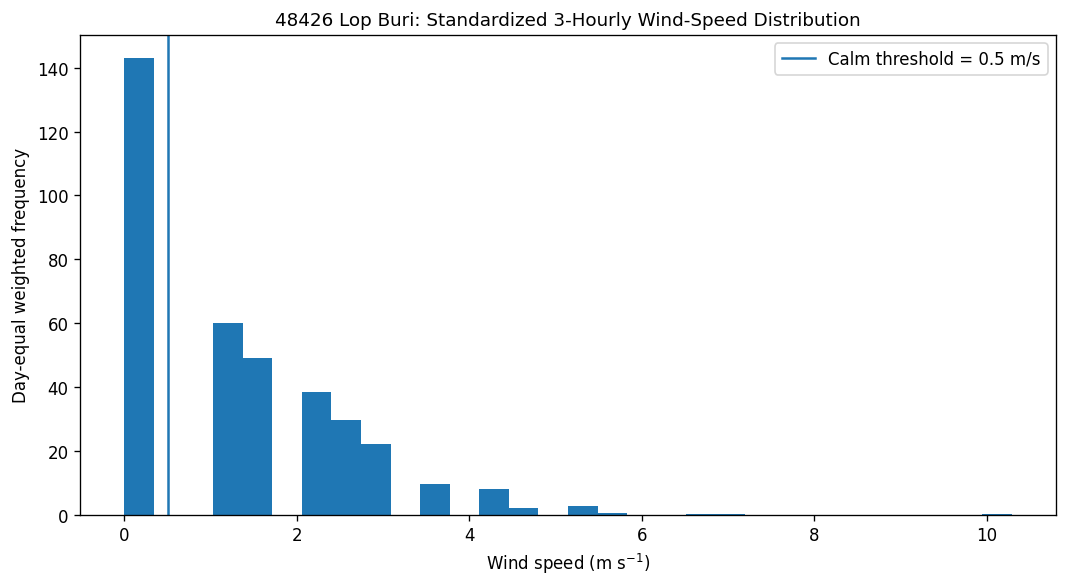


Saved: /content/drive/MyDrive/Saraburi_PM25_Meteorology/LopBuri_48426/figures/Fig06_STANDARDIZED_wind_speed_distribution.png

✅ Cell 19 completed.


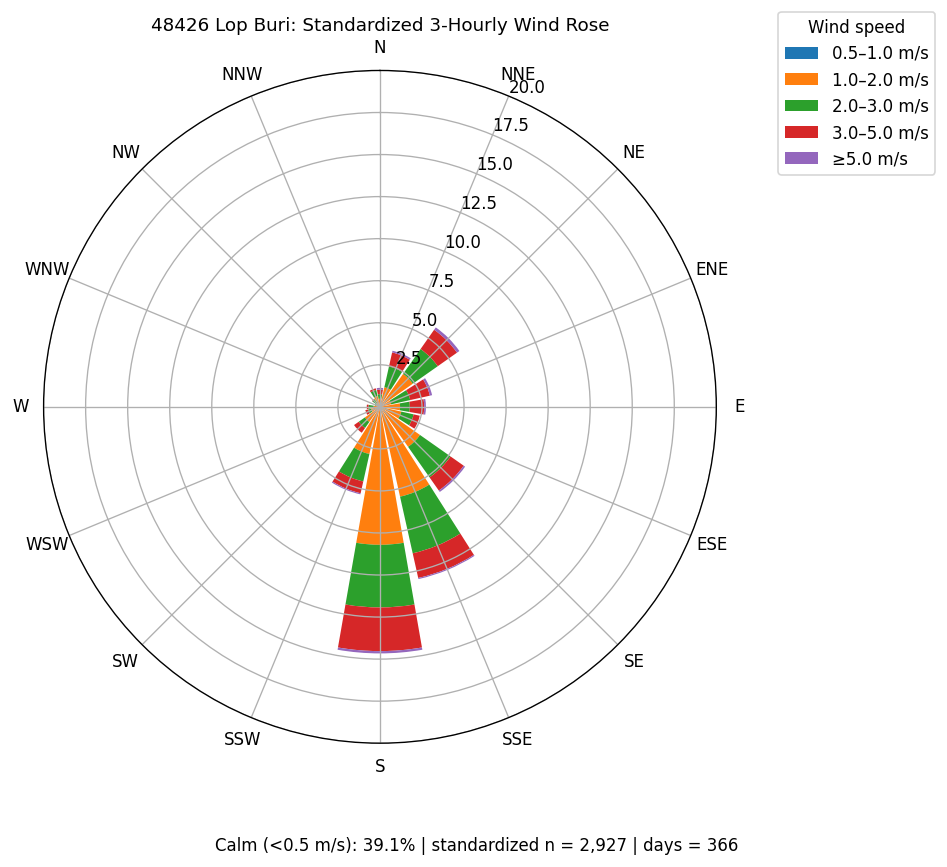

Common standardized radial maximum: 20.0
Saved: /content/drive/MyDrive/Saraburi_PM25_Meteorology/LopBuri_48426/figures/Fig07_STANDARDIZED_overall_16_sector_wind_rose.png

✅ Cell 20 completed.


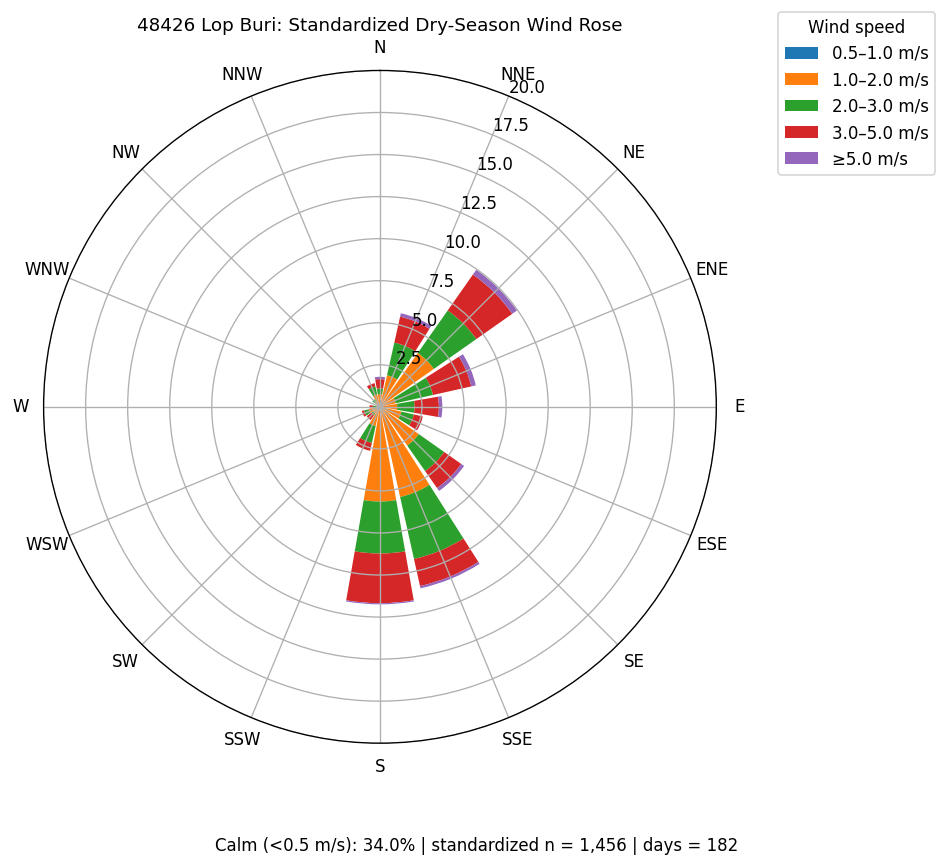

Saved: /content/drive/MyDrive/Saraburi_PM25_Meteorology/LopBuri_48426/figures/Fig08_STANDARDIZED_dry_season_wind_rose.png


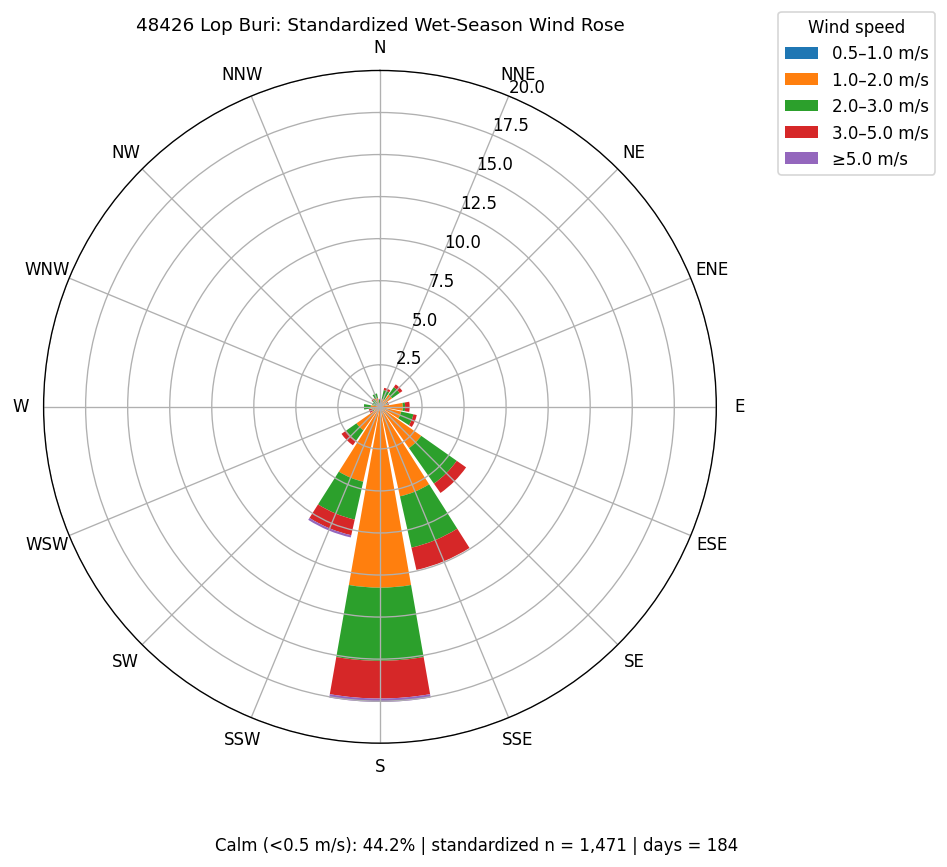

Saved: /content/drive/MyDrive/Saraburi_PM25_Meteorology/LopBuri_48426/figures/Fig09_STANDARDIZED_wet_season_wind_rose.png

STANDARDIZED SEASONAL WIND-ROSE SUMMARY
season  n_standardized_observations  n_days  calm_percent_day_weighted  radial_max_percent
   DRY                         1456     182                      34.00                20.0
   WET                         1471     184                      44.16                20.0

✅ Cell 21 completed.

STANDARDIZED 8-SECTOR WIND STATISTICS
sector  n_observations  day_weight_sum  percent_of_all_valid_day_weighted  percent_of_noncalm_day_weighted  weighted_mean_speed_ms  weighted_median_speed_ms  weighted_p75_speed_ms  weighted_p90_speed_ms  max_speed_ms  sector_vector_resultant_speed_ms  sector_vector_direction_deg  sector_persistence_ratio
     N              88          11.000                              3.005                            4.936                   2.233                     2.058                  2.572                  

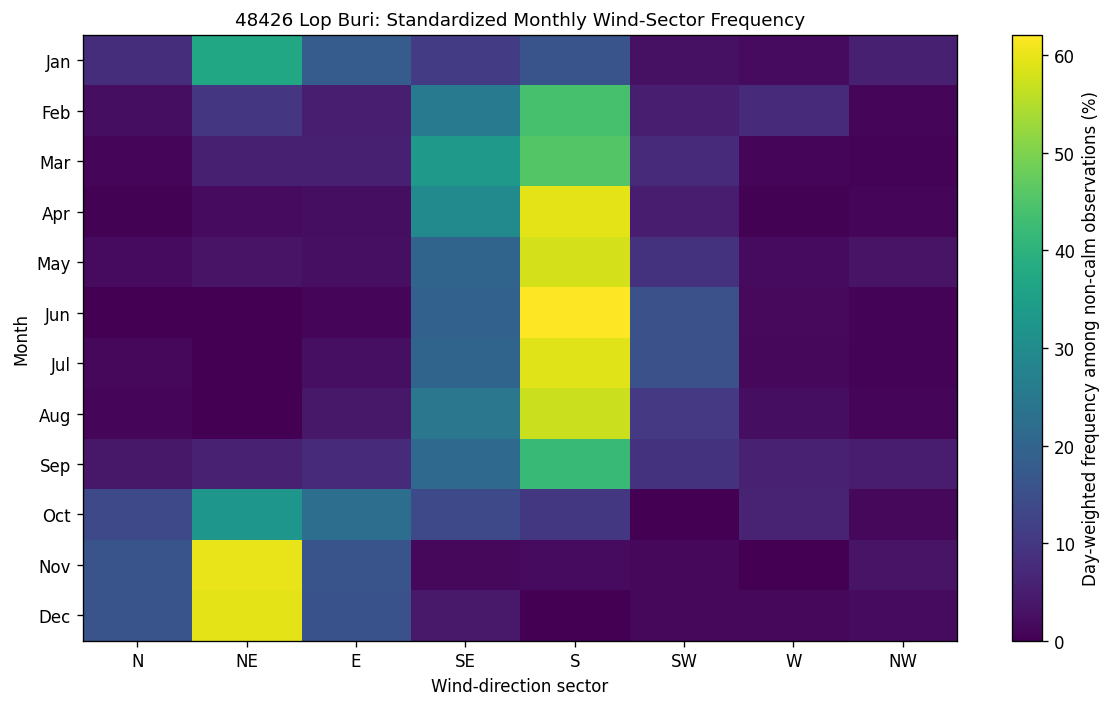


STANDARDIZED MONTHLY CALM-WIND STATISTICS
 month  n_standardized_observations  n_days  calm_percent_day_weighted
     1                          248      31                      55.24
     2                          232      29                      42.24
     3                          248      31                      24.60
     4                          240      30                      11.25
     5                          248      31                      37.50
     6                          240      30                      24.17
     7                          247      31                      36.69
     8                          248      31                      49.19
     9                          240      30                      49.17
    10                          248      31                      67.74
    11                          240      30                      35.42
    12                          248      31                      35.08

Saved: /content/drive/MyDrive/Sar

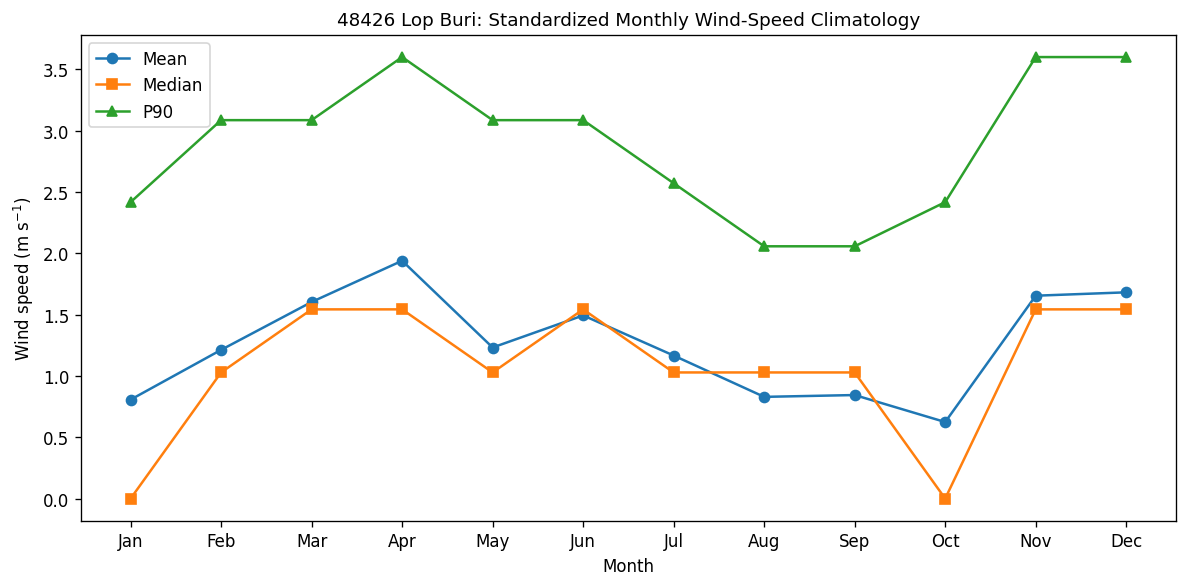

 month  n_standardized_observations  n_days  weighted_mean_speed_ms  weighted_median_speed_ms  weighted_p75_speed_ms  weighted_p90_speed_ms  calm_percent_day_weighted
     1                          248      31                   0.807                     0.000                  1.543                  2.418                     55.242
     2                          232      29                   1.213                     1.029                  2.058                  3.087                     42.241
     3                          248      31                   1.603                     1.543                  2.572                  3.087                     24.597
     4                          240      30                   1.940                     1.543                  2.572                  3.601                     11.250
     5                          248      31                   1.232                     1.029                  2.058                  3.087                     37.50

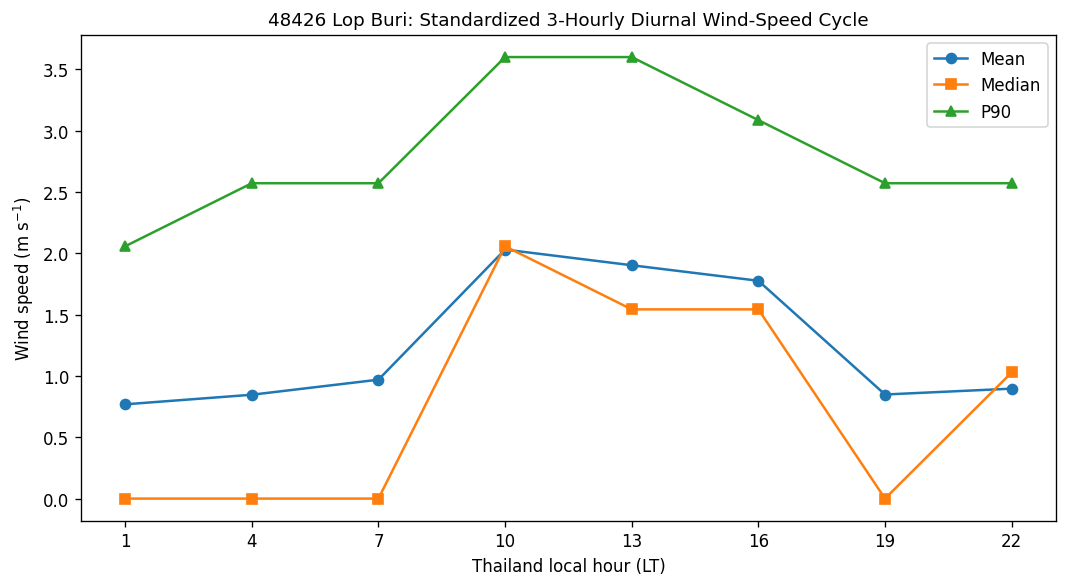

 hour_local  n_observations  n_days  mean_speed_ms  median_speed_ms  p75_speed_ms  p90_speed_ms  calm_percent
          1             366     366          0.769            0.000         1.543         2.058        54.098
          4             365     365          0.847            0.000         1.543         2.572        57.260
          7             366     366          0.970            0.000         1.543         2.572        51.639
         10             366     366          2.031            2.058         3.087         3.601        13.388
         13             366     366          1.903            1.543         2.572         3.601        14.481
         16             366     366          1.777            1.543         2.572         3.087        19.399
         19             366     366          0.849            0.000         1.543         2.572        53.005
         22             366     366          0.897            1.029         1.543         2.572        49.727

Saved: /c

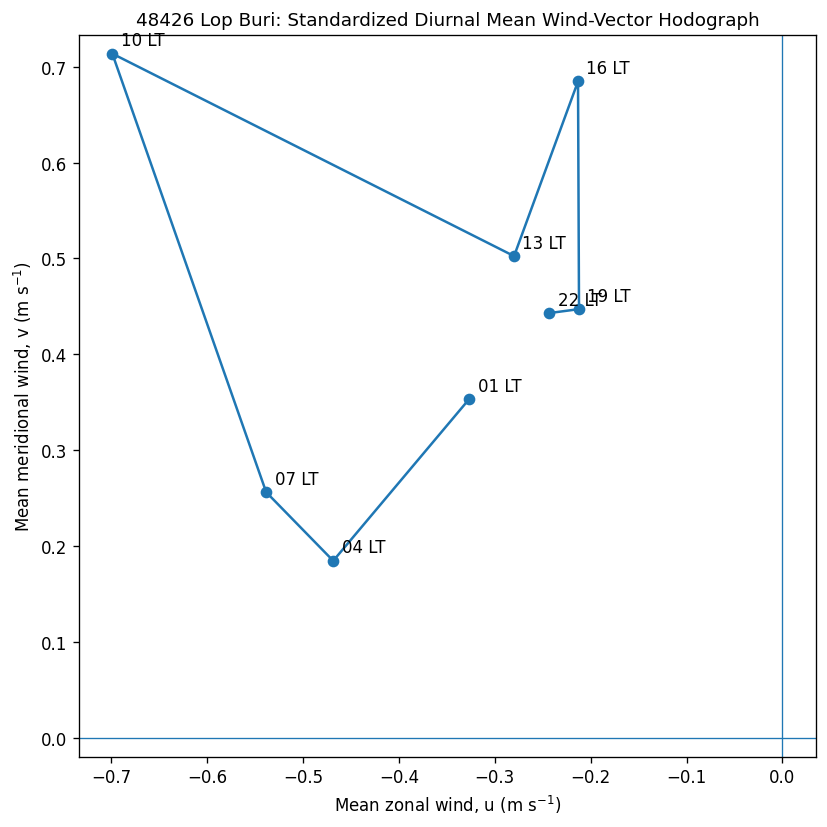

 hour_local  n_observations  n_days  u_mean_ms  v_mean_ms  scalar_mean_ms  resultant_speed_ms  resultant_direction_deg  persistence_ratio
          1             366     366     -0.327      0.354           0.769               0.481                  137.272              0.626
          4             365     365     -0.468      0.185           0.847               0.504                  111.516              0.594
          7             366     366     -0.538      0.256           0.970               0.596                  115.455              0.615
         10             366     366     -0.699      0.714           2.031               0.999                  135.598              0.492
         13             366     366     -0.280      0.502           1.903               0.575                  150.877              0.302
         16             366     366     -0.213      0.685           1.777               0.717                  162.702              0.404
         19             366     36

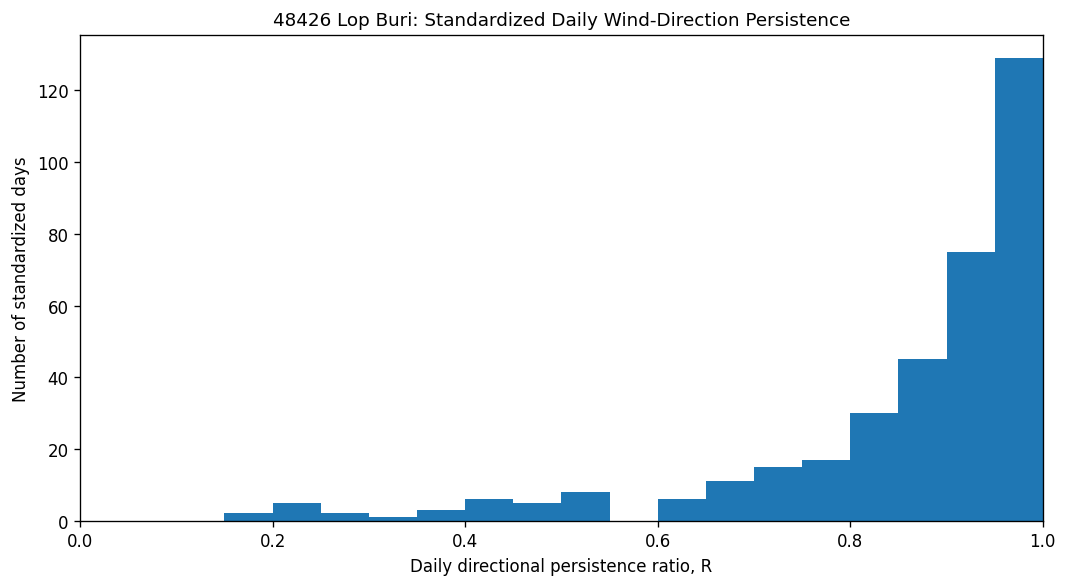

                     dataset  n_days  mean_R  std_R  p10_R  p25_R  median_R  p75_R  p90_R
STANDARDIZED_3HOURLY_PRIMARY     360   0.856  0.172  0.639  0.821     0.921  0.968   0.99

Saved: /content/drive/MyDrive/Saraburi_PM25_Meteorology/LopBuri_48426/figures/Fig14_STANDARDIZED_daily_wind_persistence_distribution.png

✅ Cell 27 completed.

STANDARDIZED DRY vs WET WIND-REGIME SUMMARY
season  n_standardized_observations  n_days  calm_percent_day_weighted  weighted_mean_speed_ms  weighted_median_speed_ms  weighted_p90_speed_ms  vector_resultant_speed_ms  vector_resultant_direction_deg  vector_persistence_ratio  median_daily_persistence_R
   DRY                         1456     182                     33.997                   1.483                     1.543                  3.087                      0.661                         108.542                     0.445                       0.925
   WET                         1471     184                     44.158                   1.030       

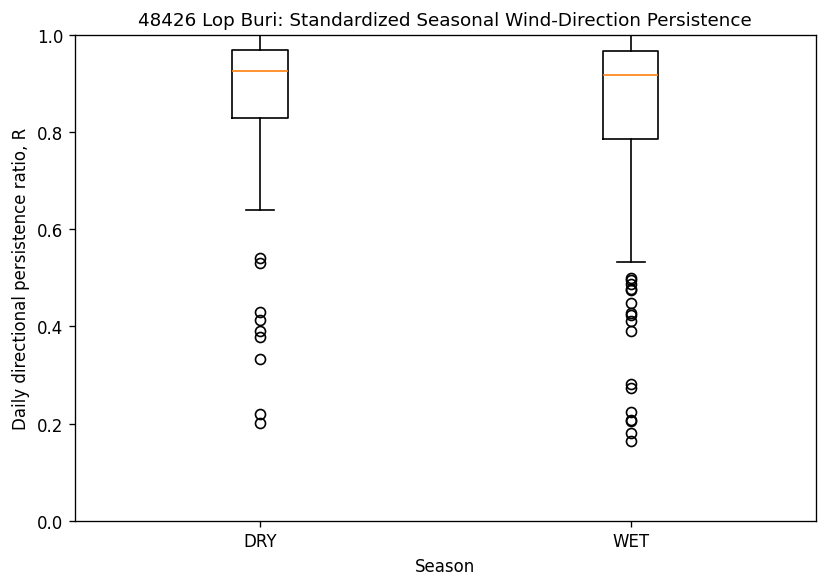


Saved: /content/drive/MyDrive/Saraburi_PM25_Meteorology/LopBuri_48426/figures/Fig15_STANDARDIZED_seasonal_wind_persistence.png

✅ Cell 28 completed.


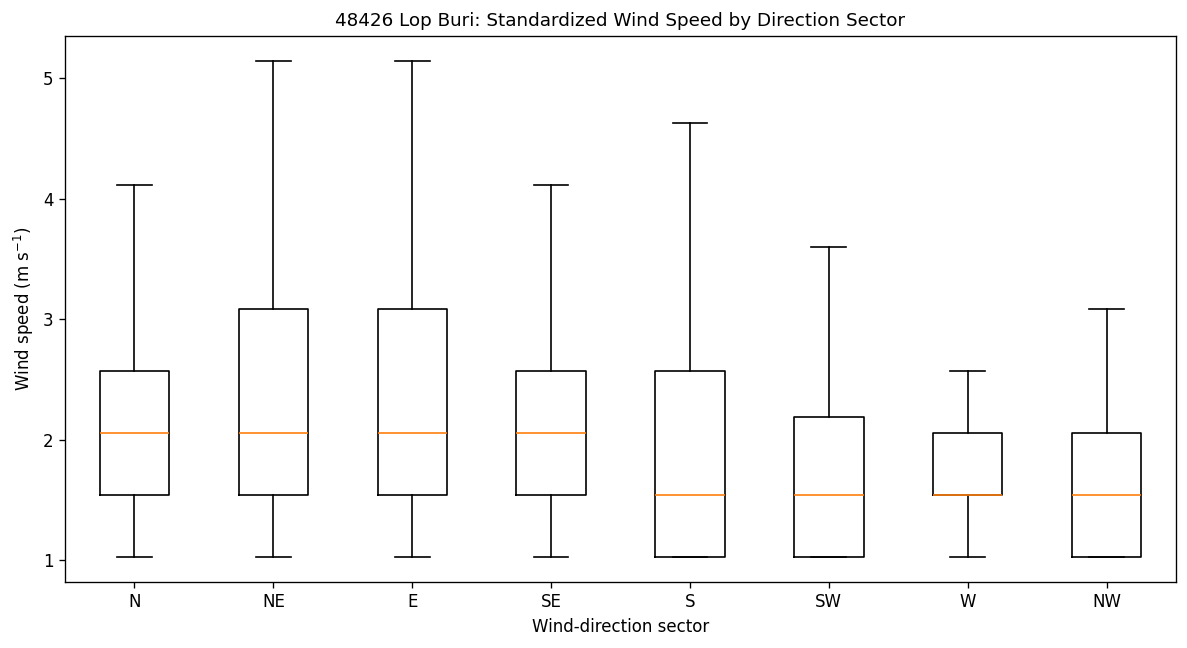

Saved: /content/drive/MyDrive/Saraburi_PM25_Meteorology/LopBuri_48426/figures/Fig16_STANDARDIZED_wind_speed_by_direction_sector.png

✅ Cell 29 completed.


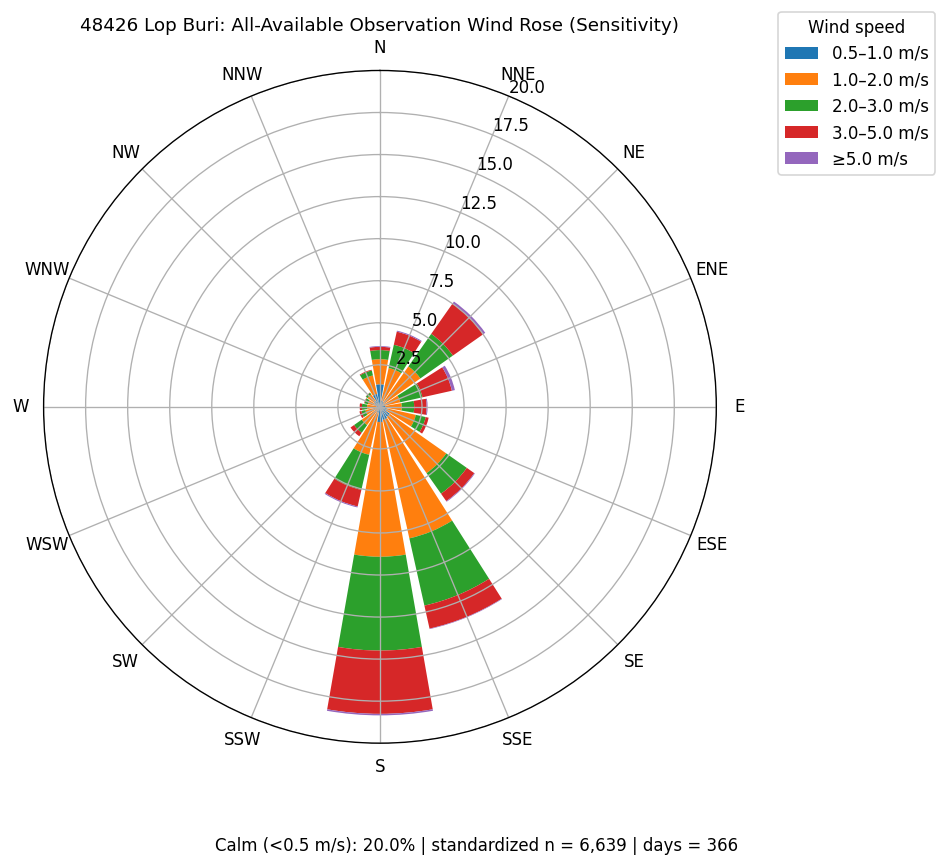


ALL-AVAILABLE vs STANDARDIZED SUMMARY
                     dataset  n_observations  n_days  calm_percent  mean_speed_ms  vector_resultant_speed_ms  vector_resultant_direction_deg  vector_persistence_ratio
   ALL_AVAILABLE_SENSITIVITY            6639     366        19.958          1.490                      0.626                         139.931                     0.420
STANDARDIZED_3HOURLY_PRIMARY            2927     366        39.105          1.255                      0.583                         140.291                     0.464

SECTOR-FREQUENCY SENSITIVITY
sector  all_available_percent_noncalm  standardized_percent_noncalm  standardized_minus_all_percentage_points
     N                          8.148                         4.936                                    -3.213
    NE                         16.805                        16.545                                    -0.260
     E                          6.869                         7.515                                 

In [ ]:
# ============================================================================================
# REPLACE / RUN AS CELL 18
# ============================================================================================
# =====================================================================
# CELL 18 — PREPARE STANDARDIZED WIND CLIMATOLOGY DATA
#
# PRIMARY CLIMATOLOGY:
#   Use only the common 3-hourly SYNOP schedule in Thailand local time:
#       01, 04, 07, 10, 13, 16, 19, 22 LT
#
# WHY:
#   Reporting cadence changed during 2024 (about 8/day early in the year
#   and near-hourly later). Using every available observation would
#   over-weight months with hourly reporting.
#
# PRIMARY RULE:
#   - retain the 8 common local-time slots
#   - require >= 75% of the 8 slots per day (>= 6 slots)
#   - give every retained day equal total statistical weight
#
# SENSITIVITY:
#   `wind_all` preserves every available SYNOP wind observation.
#
# No PM2.5 data are used in Cells 18–30.
# =====================================================================

# ---------------------------------------------------------------------
# Reload processed data only if needed.
# ---------------------------------------------------------------------
if (
    "subdaily" not in globals()
    or subdaily is None
    or len(subdaily) == 0
):

    candidates = sorted(
        PROCESSED_DIR.glob(
            f"{STATION_WMO}_{STATION_NAME.replace(' ', '')}_"
            "subdaily_harmonized_*.csv"
        )
    )

    if not candidates:
        raise RuntimeError(
            "No harmonized subdaily SYNOP file was found. "
            "Run Cells 00–17 first."
        )

    subdaily = pd.read_csv(candidates[-1])

    subdaily["datetime_utc"] = pd.to_datetime(
        subdaily["datetime_utc"],
        utc=True,
        errors="coerce"
    )

    subdaily["datetime_local"] = pd.to_datetime(
        subdaily["datetime_local"],
        utc=True,
        errors="coerce"
    ).dt.tz_convert(LOCAL_TZ)

    subdaily["date_local"] = pd.to_datetime(
        subdaily["date_local"],
        errors="coerce"
    ).dt.date

    subdaily["hour_local"] = (
        subdaily["datetime_local"]
        .dt.hour
    )


# ---------------------------------------------------------------------
# Wind-analysis settings.
# ---------------------------------------------------------------------
CALM_THRESHOLD_MS = 0.5

CORE_SYNOP_HOURS_LOCAL = [
    1,
    4,
    7,
    10,
    13,
    16,
    19,
    22
]

N_EXPECTED_CORE_SLOTS = len(
    CORE_SYNOP_HOURS_LOCAL
)

STANDARDIZED_DAY_MIN_FRACTION = 0.75

STANDARDIZED_DAY_MIN_SLOTS = int(
    np.ceil(
        N_EXPECTED_CORE_SLOTS
        *
        STANDARDIZED_DAY_MIN_FRACTION
    )
)

WIND_SPEED_EDGES = [
    CALM_THRESHOLD_MS,
    1.0,
    2.0,
    3.0,
    5.0,
    np.inf
]

WIND_SPEED_LABELS = [
    "0.5–1.0",
    "1.0–2.0",
    "2.0–3.0",
    "3.0–5.0",
    "≥5.0"
]

SECTOR16_LABELS = [
    "N",
    "NNE",
    "NE",
    "ENE",
    "E",
    "ESE",
    "SE",
    "SSE",
    "S",
    "SSW",
    "SW",
    "WSW",
    "W",
    "WNW",
    "NW",
    "NNW"
]

SECTOR8_LABELS = [
    "N",
    "NE",
    "E",
    "SE",
    "S",
    "SW",
    "W",
    "NW"
]


def season_from_month(month):
    return (
        "DRY"
        if int(month) in [
            11,
            12,
            1,
            2,
            3,
            4
        ]
        else
        "WET"
    )


def season_year_from_date(value):
    ts = pd.Timestamp(value)

    if ts.month in [
        11,
        12
    ]:
        return ts.year + 1

    return ts.year


def sector_index(direction_deg, n_sectors):

    if pd.isna(direction_deg):
        return np.nan

    width = 360.0 / n_sectors

    direction = (
        float(direction_deg)
        %
        360.0
    )

    return int(
        np.floor(
            (
                direction
                +
                width / 2.0
            )
            %
            360.0
            /
            width
        )
    )


def sector_label(direction_deg, labels):

    idx = sector_index(
        direction_deg,
        len(labels)
    )

    if pd.isna(idx):
        return np.nan

    return labels[int(idx)]


def weighted_mean(values, weights):

    values = np.asarray(
        values,
        dtype=float
    )

    weights = np.asarray(
        weights,
        dtype=float
    )

    mask = (
        np.isfinite(values)
        &
        np.isfinite(weights)
        &
        (
            weights > 0
        )
    )

    if not mask.any():
        return np.nan

    return np.average(
        values[mask],
        weights=weights[mask]
    )


def weighted_quantile(
    values,
    quantiles,
    sample_weight=None
):
    """
    Weighted empirical quantile.
    """

    values = np.asarray(
        values,
        dtype=float
    )

    quantiles = np.asarray(
        quantiles,
        dtype=float
    )

    if sample_weight is None:
        sample_weight = np.ones(
            len(values),
            dtype=float
        )

    sample_weight = np.asarray(
        sample_weight,
        dtype=float
    )

    mask = (
        np.isfinite(values)
        &
        np.isfinite(sample_weight)
        &
        (
            sample_weight > 0
        )
    )

    values = values[mask]
    sample_weight = sample_weight[mask]

    if len(values) == 0:
        return np.full(
            len(quantiles),
            np.nan
        )

    sorter = np.argsort(values)

    values = values[sorter]
    sample_weight = sample_weight[sorter]

    cumulative = (
        np.cumsum(sample_weight)
        -
        0.5 * sample_weight
    )

    cumulative = (
        cumulative
        /
        np.sum(sample_weight)
    )

    return np.interp(
        quantiles,
        cumulative,
        values
    )


def vector_summary(
    df,
    weight_col=None
):
    """
    Mean wind vector and persistence ratio.
    If `weight_col` is supplied, weighted means are used.
    """

    if df.empty:
        return {
            "u_mean_ms": np.nan,
            "v_mean_ms": np.nan,
            "scalar_mean_ms": np.nan,
            "resultant_speed_ms": np.nan,
            "resultant_direction_deg": np.nan,
            "persistence_ratio": np.nan
        }

    if (
        weight_col is not None
        and
        weight_col in df.columns
    ):

        weights = df[
            weight_col
        ].values

        u_mean = weighted_mean(
            df["u_ms"].values,
            weights
        )

        v_mean = weighted_mean(
            df["v_ms"].values,
            weights
        )

        scalar_mean = weighted_mean(
            df["wind_speed_ms"].values,
            weights
        )

    else:

        u_mean = df[
            "u_ms"
        ].mean()

        v_mean = df[
            "v_ms"
        ].mean()

        scalar_mean = df[
            "wind_speed_ms"
        ].mean()

    if (
        np.isfinite(u_mean)
        and
        np.isfinite(v_mean)
    ):

        resultant_speed = np.sqrt(
            u_mean**2
            +
            v_mean**2
        )

        if resultant_speed == 0:
            resultant_direction = np.nan

        else:
            resultant_direction = (
                np.degrees(
                    np.arctan2(
                        -u_mean,
                        -v_mean
                    )
                )
                +
                360.0
            ) % 360.0

    else:

        resultant_speed = np.nan
        resultant_direction = np.nan

    persistence_ratio = (
        resultant_speed
        /
        scalar_mean
        if (
            np.isfinite(resultant_speed)
            and
            np.isfinite(scalar_mean)
            and
            scalar_mean > 0
        )
        else np.nan
    )

    if np.isfinite(persistence_ratio):
        persistence_ratio = float(
            np.clip(
                persistence_ratio,
                0.0,
                1.0
            )
        )

    return {
        "u_mean_ms": u_mean,
        "v_mean_ms": v_mean,
        "scalar_mean_ms": scalar_mean,
        "resultant_speed_ms": resultant_speed,
        "resultant_direction_deg": resultant_direction,
        "persistence_ratio": persistence_ratio
    }


# ---------------------------------------------------------------------
# Prepare ALL AVAILABLE wind observations for sensitivity analysis.
# ---------------------------------------------------------------------
wind_all = subdaily.copy()

for column in [
    "wind_speed_ms",
    "wind_direction_deg",
    "u_ms",
    "v_ms"
]:

    wind_all[column] = pd.to_numeric(
        wind_all[column],
        errors="coerce"
    )


wind_all = wind_all[
    wind_all[
        "wind_speed_ms"
    ].notna()
    &
    (
        wind_all[
            "wind_speed_ms"
        ]
        >=
        0
    )
].copy()


wind_all[
    "date_local"
] = (
    pd.to_datetime(
        wind_all[
            "datetime_local"
        ]
    )
    .dt.tz_localize(
        None
    )
    .dt.normalize()
)

wind_all[
    "hour_local"
] = (
    pd.to_datetime(
        wind_all[
            "datetime_local"
        ]
    )
    .dt.hour
)

wind_all[
    "month"
] = (
    pd.to_datetime(
        wind_all[
            "datetime_local"
        ]
    )
    .dt.month
)

wind_all[
    "year"
] = (
    pd.to_datetime(
        wind_all[
            "datetime_local"
        ]
    )
    .dt.year
)

wind_all[
    "season"
] = (
    wind_all[
        "month"
    ]
    .map(
        season_from_month
    )
)

wind_all[
    "season_year"
] = [
    season_year_from_date(x)
    for x in wind_all[
        "datetime_local"
    ]
]

wind_all[
    "is_calm"
] = (
    wind_all[
        "wind_speed_ms"
    ]
    <
    CALM_THRESHOLD_MS
)


# ---------------------------------------------------------------------
# PRIMARY STANDARDIZED 3-HOURLY DATASET.
# ---------------------------------------------------------------------
wind_core = wind_all[
    wind_all[
        "hour_local"
    ]
    .isin(
        CORE_SYNOP_HOURS_LOCAL
    )
].copy()


# Remove duplicate station/time messages if any.
wind_core = (
    wind_core
    .drop_duplicates(
        subset=[
            "station",
            "datetime_local"
        ],
        keep="last"
    )
    .sort_values(
        "datetime_local"
    )
    .reset_index(
        drop=True
    )
)


# ---------------------------------------------------------------------
# Daily standardized-slot QA.
# ---------------------------------------------------------------------
standardized_day_rows = []

for date_local, g in wind_core.groupby(
    "date_local",
    sort=True
):

    n_unique_slots = (
        g[
            "hour_local"
        ]
        .nunique()
    )

    standardized_day_rows.append({
        "date_local":
        pd.Timestamp(
            date_local
        ),
        "n_standardized_slots":
        n_unique_slots,
        "standardized_slot_fraction":
        n_unique_slots
        /
        N_EXPECTED_CORE_SLOTS,
        "standardized_day_QA_pass":
        bool(
            n_unique_slots
            >=
            STANDARDIZED_DAY_MIN_SLOTS
        )
    })


standardized_day_qa = pd.DataFrame(
    standardized_day_rows
)


# Both tables now use the same named pandas datetime key.
standardized_day_qa[
    "date_local"
] = pd.to_datetime(
    standardized_day_qa[
        "date_local"
    ],
    errors="coerce"
)

wind_core[
    "date_local"
] = pd.to_datetime(
    wind_core[
        "date_local"
    ],
    errors="coerce"
)

wind_core = wind_core.merge(
    standardized_day_qa,
    on="date_local",
    how="left",
    validate="many_to_one"
)


# Keep only days passing the standardized-slot QA.
# Integrity check: date_local must survive the merge unchanged.
if "date_local" not in wind_core.columns:
    raise RuntimeError(
        "date_local disappeared during standardized-day QA merge."
    )

if wind_core[
    "date_local"
].isna().any():
    raise RuntimeError(
        "Unexpected missing date_local values after standardized-day QA merge."
    )

wind_std = wind_core[
    wind_core[
        "standardized_day_QA_pass"
    ] == True
].copy()


# Every retained day has total weight = 1.
wind_std[
    "day_weight"
] = (
    1.0
    /
    wind_std[
        "n_standardized_slots"
    ]
)


wind_std[
    "sector16"
] = [
    (
        sector_label(
            d,
            SECTOR16_LABELS
        )
        if not calm
        else np.nan
    )
    for d, calm
    in zip(
        wind_std[
            "wind_direction_deg"
        ],
        wind_std[
            "is_calm"
        ]
    )
]


wind_std[
    "sector8"
] = [
    (
        sector_label(
            d,
            SECTOR8_LABELS
        )
        if not calm
        else np.nan
    )
    for d, calm
    in zip(
        wind_std[
            "wind_direction_deg"
        ],
        wind_std[
            "is_calm"
        ]
    )
]


# ---------------------------------------------------------------------
# Reporting-cadence audit by month/year.
# ---------------------------------------------------------------------
cadence_rows = []

for (
    year,
    month
), g_all in wind_all.groupby(
    [
        "year",
        "month"
    ],
    sort=True
):

    g_std = wind_std[
        (
            wind_std[
                "year"
            ]
            ==
            year
        )
        &
        (
            wind_std[
                "month"
            ]
            ==
            month
        )
    ]

    n_days_calendar = pd.Period(
        f"{int(year)}-{int(month):02d}"
    ).days_in_month

    expected_standardized = (
        n_days_calendar
        *
        N_EXPECTED_CORE_SLOTS
    )

    cadence_rows.append({
        "year":
        int(
            year
        ),
        "month":
        int(
            month
        ),
        "n_all_available_observations":
        len(
            g_all
        ),
        "n_standardized_observations":
        len(
            g_std
        ),
        "n_standardized_QA_pass_days":
        g_std[
            "date_local"
        ].nunique(),
        "expected_standardized_observations_if_complete":
        expected_standardized,
        "standardized_observation_coverage":
        (
            len(
                g_std
            )
            /
            expected_standardized
            if expected_standardized > 0
            else np.nan
        )
    })


reporting_cadence_audit = pd.DataFrame(
    cadence_rows
)


reporting_cadence_audit.to_csv(
    QA_DIR
    /
    "wind_reporting_cadence_and_standardization_audit.csv",
    index=False,
    encoding="utf-8-sig"
)


standardized_day_qa.to_csv(
    QA_DIR
    /
    "wind_standardized_3hourly_daily_QA.csv",
    index=False,
    encoding="utf-8-sig"
)


wind_std.to_csv(
    PROCESSED_DIR
    /
    (
        f"{STATION_WMO}_{STATION_NAME.replace(' ', '')}_"
        "wind_standardized_3hourly.csv"
    ),
    index=False,
    encoding="utf-8-sig"
)


print(
    "All-available wind observations:",
    len(
        wind_all
    )
)

print(
    "Core-hour observations before daily QA:",
    len(
        wind_core
    )
)

print(
    "PRIMARY standardized observations:",
    len(
        wind_std
    )
)

print(
    "Standardized QA-pass days:",
    wind_std[
        "date_local"
    ].nunique()
)

print(
    "Core Thailand-local hours:",
    CORE_SYNOP_HOURS_LOCAL
)

print(
    "Minimum daily standardized slots:",
    STANDARDIZED_DAY_MIN_SLOTS,
    "/",
    N_EXPECTED_CORE_SLOTS
)

print(
    "Calm threshold:",
    CALM_THRESHOLD_MS,
    "m/s"
)

print(
    "\nREPORTING CADENCE / STANDARDIZATION AUDIT"
)

print(
    reporting_cadence_audit
    .round(
        3
    )
    .to_string(
        index=False
    )
)

print(
    "\nPrimary climatology in Cells 19–29 uses `wind_std`, "
    "not the all-available `wind_all` dataset."
)

print(
    "\n✅ Cell 18 completed."
)


# ============================================================================================
# REPLACE / RUN AS CELL 19
# ============================================================================================
# =====================================================================
# CELL 19 — STANDARDIZED WIND-SPEED STATISTICS + CALM DIAGNOSTICS
#
# Primary results use day-equal weights from the standardized 3-hourly
# dataset so months/days with more messages cannot dominate.
# =====================================================================

speed = (
    wind_std[
        "wind_speed_ms"
    ]
    .dropna()
)

speed_weights = (
    wind_std.loc[
        speed.index,
        "day_weight"
    ]
)


q = weighted_quantile(
    speed.values,
    [
        0.05,
        0.10,
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99
    ],
    sample_weight=
    speed_weights.values
)


weighted_mean_speed = weighted_mean(
    speed.values,
    speed_weights.values
)


weighted_variance = weighted_mean(
    (
        speed.values
        -
        weighted_mean_speed
    )**2,
    speed_weights.values
)


wind_speed_summary = pd.DataFrame([
    {
        "dataset":
        "STANDARDIZED_3HOURLY_PRIMARY",
        "n_observations":
        len(
            speed
        ),
        "n_days":
        wind_std[
            "date_local"
        ].nunique(),
        "weighted_mean_ms":
        weighted_mean_speed,
        "weighted_std_ms":
        np.sqrt(
            weighted_variance
        ),
        "min_ms":
        speed.min(),
        "p05_ms":
        q[
            0
        ],
        "p10_ms":
        q[
            1
        ],
        "p25_ms":
        q[
            2
        ],
        "median_ms":
        q[
            3
        ],
        "p75_ms":
        q[
            4
        ],
        "p90_ms":
        q[
            5
        ],
        "p95_ms":
        q[
            6
        ],
        "p99_ms":
        q[
            7
        ],
        "max_ms":
        speed.max()
    }
])


calm_threshold_rows = []

for threshold in [
    0.3,
    0.5,
    0.75,
    1.0
]:

    below = (
        wind_std[
            "wind_speed_ms"
        ]
        <
        threshold
    )

    weighted_pct = (
        100.0
        *
        wind_std.loc[
            below,
            "day_weight"
        ].sum()
        /
        wind_std[
            "day_weight"
        ].sum()
    )

    calm_threshold_rows.append({
        "threshold_ms":
        threshold,
        "n_observations_below":
        int(
            below.sum()
        ),
        "day_weighted_percent_below":
        weighted_pct
    })


calm_threshold_diagnostics = pd.DataFrame(
    calm_threshold_rows
)


wind_speed_summary.to_csv(
    QA_DIR
    /
    "wind_speed_descriptive_statistics_STANDARDIZED.csv",
    index=False,
    encoding="utf-8-sig"
)


calm_threshold_diagnostics.to_csv(
    QA_DIR
    /
    "calm_threshold_diagnostics_STANDARDIZED.csv",
    index=False,
    encoding="utf-8-sig"
)


print(
    "\nSTANDARDIZED WIND-SPEED DESCRIPTIVE STATISTICS"
)

print(
    wind_speed_summary
    .round(
        3
    )
    .to_string(
        index=False
    )
)


print(
    "\nCALM-THRESHOLD DIAGNOSTICS"
)

print(
    calm_threshold_diagnostics
    .round(
        2
    )
    .to_string(
        index=False
    )
)


fig, ax = plt.subplots(
    figsize=(
        9,
        5
    )
)

ax.hist(
    speed,
    bins=30,
    weights=
    speed_weights
)

ax.axvline(
    CALM_THRESHOLD_MS,
    linewidth=1.5,
    label=(
        f"Calm threshold = "
        f"{CALM_THRESHOLD_MS:.1f} m/s"
    )
)

ax.set_xlabel(
    "Wind speed (m s$^{-1}$)"
)

ax.set_ylabel(
    "Day-equal weighted frequency"
)

ax.set_title(
    f"{STATION_WMO} {STATION_NAME}: "
    "Standardized 3-Hourly Wind-Speed Distribution"
)

ax.legend()

plt.tight_layout()

fig19_path = (
    FIG_DIR
    /
    "Fig06_STANDARDIZED_wind_speed_distribution.png"
)

plt.savefig(
    fig19_path,
    dpi=FIG_DPI,
    bbox_inches="tight"
)

plt.show()

print(
    "\nSaved:",
    fig19_path
)

print(
    "\n✅ Cell 19 completed."
)


# ============================================================================================
# REPLACE / RUN AS CELL 20
# ============================================================================================
# =====================================================================
# CELL 20 — PRIMARY STANDARDIZED 16-SECTOR WIND ROSE
#
# Uses only `wind_std`.
# Each retained day has total statistical weight = 1.
# Calm observations are excluded from directional bars and reported
# separately.
# =====================================================================

def wind_rose_matrix(
    df,
    sector_labels=SECTOR16_LABELS,
    speed_edges=WIND_SPEED_EDGES,
    weight_col="day_weight"
):

    valid = df[
        df[
            "wind_speed_ms"
        ].notna()
    ].copy()

    if len(
        valid
    ) == 0:

        return (
            np.zeros(
                (
                    len(
                        sector_labels
                    ),
                    len(
                        speed_edges
                    )
                    -
                    1
                )
            ),
            np.nan,
            np.zeros(
                len(
                    sector_labels
                )
            )
        )

    if (
        weight_col is not None
        and
        weight_col in valid.columns
    ):

        weights = valid[
            weight_col
        ].astype(
            float
        )

    else:

        weights = pd.Series(
            1.0,
            index=
            valid.index
        )

    total_weight = weights.sum()

    calm_mask = (
        valid[
            "wind_speed_ms"
        ]
        <
        CALM_THRESHOLD_MS
    )

    calm_pct = (
        100.0
        *
        weights.loc[
            calm_mask
        ].sum()
        /
        total_weight
    )

    directional = valid[
        ~calm_mask
        &
        valid[
            "wind_direction_deg"
        ].notna()
    ].copy()

    matrix = np.zeros(
        (
            len(
                sector_labels
            ),
            len(
                speed_edges
            )
            -
            1
        ),
        dtype=float
    )

    for idx, row in directional.iterrows():

        s_idx = sector_index(
            row[
                "wind_direction_deg"
            ],
            len(
                sector_labels
            )
        )

        speed_value = float(
            row[
                "wind_speed_ms"
            ]
        )

        obs_weight = float(
            weights.loc[
                idx
            ]
        )

        bin_idx = None

        for j in range(
            len(
                speed_edges
            )
            -
            1
        ):

            lower = speed_edges[
                j
            ]

            upper = speed_edges[
                j + 1
            ]

            if (
                speed_value
                >=
                lower
                and
                (
                    speed_value
                    <
                    upper
                    or
                    (
                        np.isinf(
                            upper
                        )
                        and
                        speed_value
                        >=
                        lower
                    )
                )
            ):

                bin_idx = j
                break

        if bin_idx is not None:

            matrix[
                int(
                    s_idx
                ),
                bin_idx
            ] += obs_weight

    matrix = (
        matrix
        /
        total_weight
        *
        100.0
    )

    sector_totals = matrix.sum(
        axis=1
    )

    return (
        matrix,
        calm_pct,
        sector_totals
    )


def plot_wind_rose(
    df,
    title,
    output_path,
    radial_max=None,
    weight_col="day_weight"
):

    matrix, calm_pct, sector_totals = (
        wind_rose_matrix(
            df,
            weight_col=
            weight_col
        )
    )

    n_sectors = len(
        SECTOR16_LABELS
    )

    theta = np.deg2rad(
        np.arange(
            0,
            360,
            360.0
            /
            n_sectors
        )
    )

    width = np.deg2rad(
        360.0
        /
        n_sectors
        *
        0.88
    )

    fig = plt.figure(
        figsize=(
            8,
            8
        )
    )

    ax = fig.add_subplot(
        111,
        projection="polar"
    )

    ax.set_theta_zero_location(
        "N"
    )

    ax.set_theta_direction(
        -1
    )

    bottom = np.zeros(
        n_sectors
    )

    for j, label in enumerate(
        WIND_SPEED_LABELS
    ):

        values = matrix[
            :,
            j
        ]

        ax.bar(
            theta,
            values,
            width=width,
            bottom=bottom,
            label=(
                label
                +
                " m/s"
            )
        )

        bottom = (
            bottom
            +
            values
        )

    ax.set_xticks(
        theta
    )

    ax.set_xticklabels(
        SECTOR16_LABELS
    )

    if (
        radial_max is not None
        and
        np.isfinite(
            radial_max
        )
        and
        radial_max > 0
    ):

        ax.set_ylim(
            0,
            radial_max
        )

    ax.set_title(
        title,
        pad=24
    )

    ax.legend(
        loc="upper left",
        bbox_to_anchor=(
            1.08,
            1.10
        ),
        title="Wind speed"
    )

    fig.text(
        0.5,
        0.02,
        (
            f"Calm (<{CALM_THRESHOLD_MS:.1f} m/s): "
            f"{calm_pct:.1f}% | "
            f"standardized n = {len(df):,} | "
            f"days = {df['date_local'].nunique():,}"
        ),
        ha="center"
    )

    plt.tight_layout()

    plt.savefig(
        output_path,
        dpi=FIG_DPI,
        bbox_inches="tight"
    )

    plt.show()

    return {
        "calm_pct":
        calm_pct,
        "sector_totals":
        sector_totals,
        "radial_max_used":
        radial_max
    }


# ---------------------------------------------------------------------
# One common radial scale for annual + DRY + WET standardized roses.
# ---------------------------------------------------------------------
rose_groups_for_scale = [
    wind_std
]

for season_name in [
    "DRY",
    "WET"
]:

    season_group = wind_std[
        wind_std[
            "season"
        ]
        ==
        season_name
    ]

    if len(
        season_group
    ):

        rose_groups_for_scale.append(
            season_group
        )


max_sector_frequency = 0.0

for group in rose_groups_for_scale:

    _, _, sector_totals = (
        wind_rose_matrix(
            group
        )
    )

    if len(
        sector_totals
    ):

        max_sector_frequency = max(
            max_sector_frequency,
            float(
                np.nanmax(
                    sector_totals
                )
            )
        )


COMMON_WIND_ROSE_RADIAL_MAX = (
    np.ceil(
        max_sector_frequency
        /
        5.0
    )
    *
    5.0
)

if COMMON_WIND_ROSE_RADIAL_MAX <= 0:
    COMMON_WIND_ROSE_RADIAL_MAX = None


overall_wind_rose_path = (
    FIG_DIR
    /
    "Fig07_STANDARDIZED_overall_16_sector_wind_rose.png"
)


overall_rose_summary = plot_wind_rose(
    wind_std,
    (
        f"{STATION_WMO} {STATION_NAME}: "
        "Standardized 3-Hourly Wind Rose"
    ),
    overall_wind_rose_path,
    radial_max=
    COMMON_WIND_ROSE_RADIAL_MAX
)


print(
    "Common standardized radial maximum:",
    COMMON_WIND_ROSE_RADIAL_MAX
)

print(
    "Saved:",
    overall_wind_rose_path
)

print(
    "\n✅ Cell 20 completed."
)


# ============================================================================================
# REPLACE / RUN AS CELL 21
# ============================================================================================
# =====================================================================
# CELL 21 — STANDARDIZED DRY AND WET WIND ROSES
#
# DRY = Nov–Apr
# WET = May–Oct
#
# Same standardized 3-hourly schedule and same radial scale.
# =====================================================================

seasonal_rose_rows = []


for season_name in [
    "DRY",
    "WET"
]:

    season_wind = wind_std[
        wind_std[
            "season"
        ]
        ==
        season_name
    ].copy()

    if len(
        season_wind
    ) == 0:

        print(
            f"{season_name}: no standardized observations; "
            "wind rose skipped."
        )

        continue

    output_path = (
        FIG_DIR
        /
        (
            "Fig08_STANDARDIZED_dry_season_wind_rose.png"
            if season_name == "DRY"
            else
            "Fig09_STANDARDIZED_wet_season_wind_rose.png"
        )
    )

    result = plot_wind_rose(
        season_wind,
        (
            f"{STATION_WMO} {STATION_NAME}: "
            f"Standardized {season_name.title()}-Season Wind Rose"
        ),
        output_path,
        radial_max=
        COMMON_WIND_ROSE_RADIAL_MAX
    )

    seasonal_rose_rows.append({
        "season":
        season_name,
        "n_standardized_observations":
        len(
            season_wind
        ),
        "n_days":
        season_wind[
            "date_local"
        ].nunique(),
        "calm_percent_day_weighted":
        result[
            "calm_pct"
        ],
        "radial_max_percent":
        COMMON_WIND_ROSE_RADIAL_MAX
    })

    print(
        "Saved:",
        output_path
    )


seasonal_wind_rose_summary = pd.DataFrame(
    seasonal_rose_rows
)


seasonal_wind_rose_summary.to_csv(
    QA_DIR
    /
    "seasonal_wind_rose_summary_STANDARDIZED.csv",
    index=False,
    encoding="utf-8-sig"
)


print(
    "\nSTANDARDIZED SEASONAL WIND-ROSE SUMMARY"
)

if len(
    seasonal_wind_rose_summary
):

    print(
        seasonal_wind_rose_summary
        .round(
            2
        )
        .to_string(
            index=False
        )
    )

else:

    print(
        "No seasonal summaries were generated."
    )


print(
    "\n✅ Cell 21 completed."
)


# ============================================================================================
# REPLACE / RUN AS CELL 22
# ============================================================================================
# =====================================================================
# CELL 22 — STANDARDIZED 8-SECTOR FREQUENCY + SPEED STATISTICS
#
# Directional frequencies use equal-day weights.
# Calm observations are reported separately.
# =====================================================================

sector8_rows = []

total_weight = wind_std[
    "day_weight"
].sum()


noncalm = wind_std[
    ~wind_std[
        "is_calm"
    ]
    &
    wind_std[
        "sector8"
    ].notna()
].copy()


noncalm_weight = noncalm[
    "day_weight"
].sum()


for label in SECTOR8_LABELS:

    g = noncalm[
        noncalm[
            "sector8"
        ]
        ==
        label
    ]

    if len(
        g
    ):

        weights = g[
            "day_weight"
        ].values

        speeds = g[
            "wind_speed_ms"
        ].values

        speed_q = weighted_quantile(
            speeds,
            [
                0.50,
                0.75,
                0.90
            ],
            sample_weight=
            weights
        )

        vector = vector_summary(
            g,
            weight_col=
            "day_weight"
        )

        sector_weight = g[
            "day_weight"
        ].sum()

        sector8_rows.append({
            "sector":
            label,
            "n_observations":
            len(
                g
            ),
            "day_weight_sum":
            sector_weight,
            "percent_of_all_valid_day_weighted":
            100.0
            *
            sector_weight
            /
            total_weight,
            "percent_of_noncalm_day_weighted":
            100.0
            *
            sector_weight
            /
            noncalm_weight,
            "weighted_mean_speed_ms":
            weighted_mean(
                speeds,
                weights
            ),
            "weighted_median_speed_ms":
            speed_q[
                0
            ],
            "weighted_p75_speed_ms":
            speed_q[
                1
            ],
            "weighted_p90_speed_ms":
            speed_q[
                2
            ],
            "max_speed_ms":
            np.nanmax(
                speeds
            ),
            "sector_vector_resultant_speed_ms":
            vector[
                "resultant_speed_ms"
            ],
            "sector_vector_direction_deg":
            vector[
                "resultant_direction_deg"
            ],
            "sector_persistence_ratio":
            vector[
                "persistence_ratio"
            ]
        })

    else:

        sector8_rows.append({
            "sector":
            label,
            "n_observations":
            0,
            "day_weight_sum":
            0.0,
            "percent_of_all_valid_day_weighted":
            0.0,
            "percent_of_noncalm_day_weighted":
            0.0,
            "weighted_mean_speed_ms":
            np.nan,
            "weighted_median_speed_ms":
            np.nan,
            "weighted_p75_speed_ms":
            np.nan,
            "weighted_p90_speed_ms":
            np.nan,
            "max_speed_ms":
            np.nan,
            "sector_vector_resultant_speed_ms":
            np.nan,
            "sector_vector_direction_deg":
            np.nan,
            "sector_persistence_ratio":
            np.nan
        })


sector8_statistics = pd.DataFrame(
    sector8_rows
)


sector8_statistics.to_csv(
    PROCESSED_DIR
    /
    "wind_8sector_frequency_and_speed_statistics_STANDARDIZED.csv",
    index=False,
    encoding="utf-8-sig"
)


calm_weight = wind_std.loc[
    wind_std[
        "is_calm"
    ],
    "day_weight"
].sum()


calm_summary = pd.DataFrame([
    {
        "calm_threshold_ms":
        CALM_THRESHOLD_MS,
        "n_calm_observations":
        int(
            wind_std[
                "is_calm"
            ].sum()
        ),
        "day_weighted_percent_calm":
        100.0
        *
        calm_weight
        /
        total_weight
    }
])


calm_summary.to_csv(
    PROCESSED_DIR
    /
    "wind_calm_summary_STANDARDIZED.csv",
    index=False,
    encoding="utf-8-sig"
)


print(
    "\nSTANDARDIZED 8-SECTOR WIND STATISTICS"
)

print(
    sector8_statistics
    .round(
        3
    )
    .to_string(
        index=False
    )
)


print(
    "\nSTANDARDIZED CALM SUMMARY"
)

print(
    calm_summary
    .round(
        2
    )
    .to_string(
        index=False
    )
)


print(
    "\n✅ Cell 22 completed."
)


# ============================================================================================
# REPLACE / RUN AS CELL 23
# ============================================================================================
# =====================================================================
# CELL 23 — STANDARDIZED MONTH × WIND-SECTOR HEATMAP
#
# Uses the same 8 core 3-hourly slots throughout the analysis period.
# Frequencies are day-weighted among NON-CALM standardized observations.
# =====================================================================

month_sector_matrix = np.full(
    (
        12,
        len(
            SECTOR8_LABELS
        )
    ),
    np.nan,
    dtype=float
)


monthly_calm_rows = []


for month in range(
    1,
    13
):

    month_all = wind_std[
        wind_std[
            "month"
        ]
        ==
        month
    ]

    if len(
        month_all
    ) == 0:

        monthly_calm_rows.append({
            "month":
            month,
            "n_standardized_observations":
            0,
            "n_days":
            0,
            "calm_percent_day_weighted":
            np.nan
        })

        continue

    month_weight_total = month_all[
        "day_weight"
    ].sum()

    calm_weight = month_all.loc[
        month_all[
            "is_calm"
        ],
        "day_weight"
    ].sum()

    calm_pct = (
        100.0
        *
        calm_weight
        /
        month_weight_total
    )

    month_noncalm = month_all[
        ~month_all[
            "is_calm"
        ]
        &
        month_all[
            "sector8"
        ].notna()
    ]

    noncalm_weight = month_noncalm[
        "day_weight"
    ].sum()

    monthly_calm_rows.append({
        "month":
        month,
        "n_standardized_observations":
        len(
            month_all
        ),
        "n_days":
        month_all[
            "date_local"
        ].nunique(),
        "calm_percent_day_weighted":
        calm_pct
    })

    if noncalm_weight <= 0:
        continue

    for j, sector in enumerate(
        SECTOR8_LABELS
    ):

        sector_weight = month_noncalm.loc[
            month_noncalm[
                "sector8"
            ]
            ==
            sector,
            "day_weight"
        ].sum()

        month_sector_matrix[
            month - 1,
            j
        ] = (
            100.0
            *
            sector_weight
            /
            noncalm_weight
        )


monthly_calm_statistics = pd.DataFrame(
    monthly_calm_rows
)


monthly_calm_statistics.to_csv(
    PROCESSED_DIR
    /
    "monthly_calm_wind_statistics_STANDARDIZED.csv",
    index=False,
    encoding="utf-8-sig"
)


month_sector_df = pd.DataFrame(
    month_sector_matrix,
    columns=
    SECTOR8_LABELS
)

month_sector_df.insert(
    0,
    "month",
    np.arange(
        1,
        13
    )
)


month_sector_df.to_csv(
    PROCESSED_DIR
    /
    "monthly_wind_sector_frequency_percent_noncalm_STANDARDIZED.csv",
    index=False,
    encoding="utf-8-sig"
)


fig, ax = plt.subplots(
    figsize=(
        10,
        6
    )
)

masked = np.ma.masked_invalid(
    month_sector_matrix
)

image = ax.imshow(
    masked,
    aspect="auto"
)

ax.set_xticks(
    np.arange(
        len(
            SECTOR8_LABELS
        )
    )
)

ax.set_xticklabels(
    SECTOR8_LABELS
)

ax.set_yticks(
    np.arange(
        12
    )
)

ax.set_yticklabels(
    [
        "Jan",
        "Feb",
        "Mar",
        "Apr",
        "May",
        "Jun",
        "Jul",
        "Aug",
        "Sep",
        "Oct",
        "Nov",
        "Dec"
    ]
)

ax.set_xlabel(
    "Wind-direction sector"
)

ax.set_ylabel(
    "Month"
)

ax.set_title(
    f"{STATION_WMO} {STATION_NAME}: "
    "Standardized Monthly Wind-Sector Frequency"
)

cbar = fig.colorbar(
    image,
    ax=ax
)

cbar.set_label(
    "Day-weighted frequency among non-calm observations (%)"
)

plt.tight_layout()

fig23_path = (
    FIG_DIR
    /
    "Fig10_STANDARDIZED_monthly_wind_sector_heatmap.png"
)

plt.savefig(
    fig23_path,
    dpi=FIG_DPI,
    bbox_inches="tight"
)

plt.show()


print(
    "\nSTANDARDIZED MONTHLY CALM-WIND STATISTICS"
)

print(
    monthly_calm_statistics
    .round(
        2
    )
    .to_string(
        index=False
    )
)

print(
    "\nSaved:",
    fig23_path
)

print(
    "\n✅ Cell 23 completed."
)


# ============================================================================================
# REPLACE / RUN AS CELL 24
# ============================================================================================
# =====================================================================
# CELL 24 — STANDARDIZED MONTHLY WIND-SPEED CLIMATOLOGY
# =====================================================================

monthly_speed_rows = []


for month in range(
    1,
    13
):

    g = wind_std[
        wind_std[
            "month"
        ]
        ==
        month
    ]

    if len(
        g
    ) == 0:

        monthly_speed_rows.append({
            "month":
            month,
            "n_standardized_observations":
            0,
            "n_days":
            0,
            "weighted_mean_speed_ms":
            np.nan,
            "weighted_median_speed_ms":
            np.nan,
            "weighted_p75_speed_ms":
            np.nan,
            "weighted_p90_speed_ms":
            np.nan,
            "calm_percent_day_weighted":
            np.nan
        })

        continue

    weights = g[
        "day_weight"
    ].values

    speeds = g[
        "wind_speed_ms"
    ].values

    q = weighted_quantile(
        speeds,
        [
            0.50,
            0.75,
            0.90
        ],
        sample_weight=
        weights
    )

    month_weight = g[
        "day_weight"
    ].sum()

    calm_weight = g.loc[
        g[
            "is_calm"
        ],
        "day_weight"
    ].sum()

    monthly_speed_rows.append({
        "month":
        month,
        "n_standardized_observations":
        len(
            g
        ),
        "n_days":
        g[
            "date_local"
        ].nunique(),
        "weighted_mean_speed_ms":
        weighted_mean(
            speeds,
            weights
        ),
        "weighted_median_speed_ms":
        q[
            0
        ],
        "weighted_p75_speed_ms":
        q[
            1
        ],
        "weighted_p90_speed_ms":
        q[
            2
        ],
        "calm_percent_day_weighted":
        100.0
        *
        calm_weight
        /
        month_weight
    })


monthly_wind_speed = pd.DataFrame(
    monthly_speed_rows
)


monthly_wind_speed.to_csv(
    PROCESSED_DIR
    /
    "monthly_wind_speed_climatology_STANDARDIZED.csv",
    index=False,
    encoding="utf-8-sig"
)


fig, ax = plt.subplots(
    figsize=(
        10,
        5
    )
)

ax.plot(
    monthly_wind_speed[
        "month"
    ],
    monthly_wind_speed[
        "weighted_mean_speed_ms"
    ],
    marker="o",
    label="Mean"
)

ax.plot(
    monthly_wind_speed[
        "month"
    ],
    monthly_wind_speed[
        "weighted_median_speed_ms"
    ],
    marker="s",
    label="Median"
)

ax.plot(
    monthly_wind_speed[
        "month"
    ],
    monthly_wind_speed[
        "weighted_p90_speed_ms"
    ],
    marker="^",
    label="P90"
)

ax.set_xticks(
    np.arange(
        1,
        13
    )
)

ax.set_xticklabels(
    [
        "Jan",
        "Feb",
        "Mar",
        "Apr",
        "May",
        "Jun",
        "Jul",
        "Aug",
        "Sep",
        "Oct",
        "Nov",
        "Dec"
    ]
)

ax.set_xlabel(
    "Month"
)

ax.set_ylabel(
    "Wind speed (m s$^{-1}$)"
)

ax.set_title(
    f"{STATION_WMO} {STATION_NAME}: "
    "Standardized Monthly Wind-Speed Climatology"
)

ax.legend()

plt.tight_layout()

fig24_path = (
    FIG_DIR
    /
    "Fig11_STANDARDIZED_monthly_wind_speed_climatology.png"
)

plt.savefig(
    fig24_path,
    dpi=FIG_DPI,
    bbox_inches="tight"
)

plt.show()


print(
    monthly_wind_speed
    .round(
        3
    )
    .to_string(
        index=False
    )
)

print(
    "\nSaved:",
    fig24_path
)

print(
    "\n✅ Cell 24 completed."
)


# ============================================================================================
# REPLACE / RUN AS CELL 25
# ============================================================================================
# =====================================================================
# CELL 25 — STANDARDIZED DIURNAL WIND-SPEED CYCLE
#
# Only the 8 common Thailand-local SYNOP hours are used:
#   01, 04, 07, 10, 13, 16, 19, 22 LT
#
# Therefore every plotted hour has the same intended seasonal coverage.
# =====================================================================

diurnal_speed_rows = []


for hour in CORE_SYNOP_HOURS_LOCAL:

    g = wind_std[
        wind_std[
            "hour_local"
        ]
        ==
        hour
    ]

    if len(
        g
    ) == 0:

        diurnal_speed_rows.append({
            "hour_local":
            hour,
            "n_observations":
            0,
            "n_days":
            0,
            "mean_speed_ms":
            np.nan,
            "median_speed_ms":
            np.nan,
            "p75_speed_ms":
            np.nan,
            "p90_speed_ms":
            np.nan,
            "calm_percent":
            np.nan
        })

        continue

    speeds = g[
        "wind_speed_ms"
    ]

    diurnal_speed_rows.append({
        "hour_local":
        hour,
        "n_observations":
        len(
            g
        ),
        "n_days":
        g[
            "date_local"
        ].nunique(),
        "mean_speed_ms":
        speeds.mean(),
        "median_speed_ms":
        speeds.median(),
        "p75_speed_ms":
        speeds.quantile(
            0.75
        ),
        "p90_speed_ms":
        speeds.quantile(
            0.90
        ),
        "calm_percent":
        100.0
        *
        g[
            "is_calm"
        ].mean()
    })


diurnal_wind_speed = pd.DataFrame(
    diurnal_speed_rows
)


diurnal_wind_speed.to_csv(
    PROCESSED_DIR
    /
    "diurnal_wind_speed_cycle_STANDARDIZED.csv",
    index=False,
    encoding="utf-8-sig"
)


fig, ax = plt.subplots(
    figsize=(
        9,
        5
    )
)

ax.plot(
    diurnal_wind_speed[
        "hour_local"
    ],
    diurnal_wind_speed[
        "mean_speed_ms"
    ],
    marker="o",
    label="Mean"
)

ax.plot(
    diurnal_wind_speed[
        "hour_local"
    ],
    diurnal_wind_speed[
        "median_speed_ms"
    ],
    marker="s",
    label="Median"
)

ax.plot(
    diurnal_wind_speed[
        "hour_local"
    ],
    diurnal_wind_speed[
        "p90_speed_ms"
    ],
    marker="^",
    label="P90"
)

ax.set_xticks(
    CORE_SYNOP_HOURS_LOCAL
)

ax.set_xlabel(
    "Thailand local hour (LT)"
)

ax.set_ylabel(
    "Wind speed (m s$^{-1}$)"
)

ax.set_title(
    f"{STATION_WMO} {STATION_NAME}: "
    "Standardized 3-Hourly Diurnal Wind-Speed Cycle"
)

ax.legend()

plt.tight_layout()

fig25_path = (
    FIG_DIR
    /
    "Fig12_STANDARDIZED_diurnal_wind_speed_cycle.png"
)

plt.savefig(
    fig25_path,
    dpi=FIG_DPI,
    bbox_inches="tight"
)

plt.show()


print(
    diurnal_wind_speed
    .round(
        3
    )
    .to_string(
        index=False
    )
)

print(
    "\nSaved:",
    fig25_path
)

print(
    "\n✅ Cell 25 completed."
)


# ============================================================================================
# REPLACE / RUN AS CELL 26
# ============================================================================================
# =====================================================================
# CELL 26 — STANDARDIZED DIURNAL MEAN WIND-VECTOR HODOGRAPH
#
# Uses only the 8 common local-time slots.
# Each point therefore has comparable seasonal representation.
# =====================================================================

diurnal_vector_rows = []


for hour in CORE_SYNOP_HOURS_LOCAL:

    g = wind_std[
        wind_std[
            "hour_local"
        ]
        ==
        hour
    ]

    summary = vector_summary(
        g
    )

    diurnal_vector_rows.append({
        "hour_local":
        hour,
        "n_observations":
        len(
            g
        ),
        "n_days":
        g[
            "date_local"
        ].nunique(),
        **summary
    })


diurnal_wind_vector = pd.DataFrame(
    diurnal_vector_rows
)


diurnal_wind_vector.to_csv(
    PROCESSED_DIR
    /
    "diurnal_mean_wind_vector_climatology_STANDARDIZED.csv",
    index=False,
    encoding="utf-8-sig"
)


fig, ax = plt.subplots(
    figsize=(
        7,
        7
    )
)

ax.plot(
    diurnal_wind_vector[
        "u_mean_ms"
    ],
    diurnal_wind_vector[
        "v_mean_ms"
    ],
    marker="o"
)

for _, row in diurnal_wind_vector.iterrows():

    if (
        np.isfinite(
            row[
                "u_mean_ms"
            ]
        )
        and
        np.isfinite(
            row[
                "v_mean_ms"
            ]
        )
    ):

        ax.annotate(
            f"{int(row['hour_local']):02d} LT",
            (
                row[
                    "u_mean_ms"
                ],
                row[
                    "v_mean_ms"
                ]
            ),
            xytext=(
                5,
                5
            ),
            textcoords="offset points"
        )


ax.axhline(
    0,
    linewidth=0.8
)

ax.axvline(
    0,
    linewidth=0.8
)

ax.set_xlabel(
    "Mean zonal wind, u (m s$^{-1}$)"
)

ax.set_ylabel(
    "Mean meridional wind, v (m s$^{-1}$)"
)

ax.set_title(
    f"{STATION_WMO} {STATION_NAME}: "
    "Standardized Diurnal Mean Wind-Vector Hodograph"
)

ax.set_aspect(
    "equal",
    adjustable="datalim"
)

plt.tight_layout()

fig26_path = (
    FIG_DIR
    /
    "Fig13_STANDARDIZED_diurnal_mean_wind_vector_hodograph.png"
)

plt.savefig(
    fig26_path,
    dpi=FIG_DPI,
    bbox_inches="tight"
)

plt.show()


print(
    diurnal_wind_vector
    .round(
        3
    )
    .to_string(
        index=False
    )
)

print(
    "\nSaved:",
    fig26_path
)

print(
    "\n✅ Cell 26 completed."
)


# ============================================================================================
# REPLACE / RUN AS CELL 27
# ============================================================================================
# =====================================================================
# CELL 27 — DAILY DIRECTIONAL PERSISTENCE FROM STANDARDIZED 3-HOURLY WIND
#
# IMPORTANT:
#   Recomputed directly from `wind_std`.
#   It does NOT use the earlier all-available daily aggregation.
#
# R = resultant speed / scalar-mean speed
# =====================================================================

daily_standardized_rows = []


for date_local, g in wind_std.groupby(
    "date_local",
    sort=True
):

    vector = vector_summary(
        g
    )

    daily_standardized_rows.append({
        "date_local":
        pd.Timestamp(
            date_local
        ),
        "n_standardized_slots":
        g[
            "hour_local"
        ].nunique(),
        "standardized_slot_fraction":
        g[
            "hour_local"
        ].nunique()
        /
        N_EXPECTED_CORE_SLOTS,
        "scalar_mean_speed_ms":
        vector[
            "scalar_mean_ms"
        ],
        "u_mean_ms":
        vector[
            "u_mean_ms"
        ],
        "v_mean_ms":
        vector[
            "v_mean_ms"
        ],
        "resultant_speed_ms":
        vector[
            "resultant_speed_ms"
        ],
        "resultant_direction_deg":
        vector[
            "resultant_direction_deg"
        ],
        "wind_persistence_ratio":
        vector[
            "persistence_ratio"
        ]
    })


daily_wind = pd.DataFrame(
    daily_standardized_rows
)


daily_wind[
    "month"
] = (
    daily_wind[
        "date_local"
    ]
    .dt.month
)

daily_wind[
    "season"
] = (
    daily_wind[
        "month"
    ]
    .map(
        season_from_month
    )
)


persistence_values = (
    daily_wind[
        "wind_persistence_ratio"
    ]
    .dropna()
)


persistence_summary = pd.DataFrame([
    {
        "dataset":
        "STANDARDIZED_3HOURLY_PRIMARY",
        "n_days":
        len(
            persistence_values
        ),
        "mean_R":
        persistence_values.mean(),
        "std_R":
        persistence_values.std(),
        "p10_R":
        persistence_values.quantile(
            0.10
        ),
        "p25_R":
        persistence_values.quantile(
            0.25
        ),
        "median_R":
        persistence_values.median(),
        "p75_R":
        persistence_values.quantile(
            0.75
        ),
        "p90_R":
        persistence_values.quantile(
            0.90
        )
    }
])


daily_wind.to_csv(
    PROCESSED_DIR
    /
    "daily_wind_with_directional_persistence_STANDARDIZED.csv",
    index=False,
    encoding="utf-8-sig"
)


persistence_summary.to_csv(
    PROCESSED_DIR
    /
    "daily_wind_persistence_summary_STANDARDIZED.csv",
    index=False,
    encoding="utf-8-sig"
)


fig, ax = plt.subplots(
    figsize=(
        9,
        5
    )
)

ax.hist(
    persistence_values,
    bins=np.linspace(
        0,
        1,
        21
    )
)

ax.set_xlim(
    0,
    1
)

ax.set_xlabel(
    "Daily directional persistence ratio, R"
)

ax.set_ylabel(
    "Number of standardized days"
)

ax.set_title(
    f"{STATION_WMO} {STATION_NAME}: "
    "Standardized Daily Wind-Direction Persistence"
)

plt.tight_layout()

fig27_path = (
    FIG_DIR
    /
    "Fig14_STANDARDIZED_daily_wind_persistence_distribution.png"
)

plt.savefig(
    fig27_path,
    dpi=FIG_DPI,
    bbox_inches="tight"
)

plt.show()


print(
    persistence_summary
    .round(
        3
    )
    .to_string(
        index=False
    )
)

print(
    "\nSaved:",
    fig27_path
)

print(
    "\n✅ Cell 27 completed."
)


# ============================================================================================
# REPLACE / RUN AS CELL 28
# ============================================================================================
# =====================================================================
# CELL 28 — STANDARDIZED DRY vs WET WIND-REGIME SUMMARY
#
# Descriptive comparison only.
# All seasonal subdaily summaries use equal-day weights.
# =====================================================================

seasonal_wind_rows = []


for season_name in [
    "DRY",
    "WET"
]:

    sub = wind_std[
        wind_std[
            "season"
        ]
        ==
        season_name
    ]

    daily_sub = daily_wind[
        daily_wind[
            "season"
        ]
        ==
        season_name
    ]

    if len(
        sub
    ) == 0:

        seasonal_wind_rows.append({
            "season":
            season_name,
            "n_standardized_observations":
            0,
            "n_days":
            0,
            "calm_percent_day_weighted":
            np.nan,
            "weighted_mean_speed_ms":
            np.nan,
            "weighted_median_speed_ms":
            np.nan,
            "weighted_p90_speed_ms":
            np.nan,
            "vector_resultant_speed_ms":
            np.nan,
            "vector_resultant_direction_deg":
            np.nan,
            "vector_persistence_ratio":
            np.nan,
            "median_daily_persistence_R":
            np.nan
        })

        continue

    weights = sub[
        "day_weight"
    ].values

    speeds = sub[
        "wind_speed_ms"
    ].values

    q = weighted_quantile(
        speeds,
        [
            0.50,
            0.90
        ],
        sample_weight=
        weights
    )

    total_weight = sub[
        "day_weight"
    ].sum()

    calm_weight = sub.loc[
        sub[
            "is_calm"
        ],
        "day_weight"
    ].sum()

    vector = vector_summary(
        sub,
        weight_col=
        "day_weight"
    )

    seasonal_wind_rows.append({
        "season":
        season_name,
        "n_standardized_observations":
        len(
            sub
        ),
        "n_days":
        sub[
            "date_local"
        ].nunique(),
        "calm_percent_day_weighted":
        100.0
        *
        calm_weight
        /
        total_weight,
        "weighted_mean_speed_ms":
        weighted_mean(
            speeds,
            weights
        ),
        "weighted_median_speed_ms":
        q[
            0
        ],
        "weighted_p90_speed_ms":
        q[
            1
        ],
        "vector_resultant_speed_ms":
        vector[
            "resultant_speed_ms"
        ],
        "vector_resultant_direction_deg":
        vector[
            "resultant_direction_deg"
        ],
        "vector_persistence_ratio":
        vector[
            "persistence_ratio"
        ],
        "median_daily_persistence_R":
        daily_sub[
            "wind_persistence_ratio"
        ].median()
    })


seasonal_wind_summary = pd.DataFrame(
    seasonal_wind_rows
)


seasonal_wind_summary.to_csv(
    PROCESSED_DIR
    /
    "dry_wet_wind_regime_summary_STANDARDIZED.csv",
    index=False,
    encoding="utf-8-sig"
)


print(
    "\nSTANDARDIZED DRY vs WET WIND-REGIME SUMMARY"
)

print(
    seasonal_wind_summary
    .round(
        3
    )
    .to_string(
        index=False
    )
)


season_values = []

season_labels_present = []

for season_name in [
    "DRY",
    "WET"
]:

    vals = (
        daily_wind.loc[
            daily_wind[
                "season"
            ]
            ==
            season_name,
            "wind_persistence_ratio"
        ]
        .dropna()
        .values
    )

    if len(
        vals
    ):

        season_values.append(
            vals
        )

        season_labels_present.append(
            season_name
        )


if season_values:

    fig, ax = plt.subplots(
        figsize=(
            7,
            5
        )
    )

    ax.boxplot(
        season_values,
        tick_labels=
        season_labels_present
    )

    ax.set_ylim(
        0,
        1
    )

    ax.set_xlabel(
        "Season"
    )

    ax.set_ylabel(
        "Daily directional persistence ratio, R"
    )

    ax.set_title(
        f"{STATION_WMO} {STATION_NAME}: "
        "Standardized Seasonal Wind-Direction Persistence"
    )

    plt.tight_layout()

    fig28_path = (
        FIG_DIR
        /
        "Fig15_STANDARDIZED_seasonal_wind_persistence.png"
    )

    plt.savefig(
        fig28_path,
        dpi=FIG_DPI,
        bbox_inches="tight"
    )

    plt.show()

    print(
        "\nSaved:",
        fig28_path
    )


print(
    "\n✅ Cell 28 completed."
)


# ============================================================================================
# REPLACE / RUN AS CELL 29
# ============================================================================================
# =====================================================================
# CELL 29 — STANDARDIZED WIND SPEED BY 8-SECTOR DIRECTION
#
# Calm observations are excluded from directional boxplots.
# =====================================================================

sector_speed_values = []

sector_speed_labels = []


for sector in SECTOR8_LABELS:

    values = (
        noncalm.loc[
            noncalm[
                "sector8"
            ]
            ==
            sector,
            "wind_speed_ms"
        ]
        .dropna()
        .values
    )

    if len(
        values
    ):

        sector_speed_values.append(
            values
        )

        sector_speed_labels.append(
            sector
        )


if sector_speed_values:

    fig, ax = plt.subplots(
        figsize=(
            10,
            5.5
        )
    )

    ax.boxplot(
        sector_speed_values,
        tick_labels=
        sector_speed_labels,
        showfliers=False
    )

    ax.set_xlabel(
        "Wind-direction sector"
    )

    ax.set_ylabel(
        "Wind speed (m s$^{-1}$)"
    )

    ax.set_title(
        f"{STATION_WMO} {STATION_NAME}: "
        "Standardized Wind Speed by Direction Sector"
    )

    plt.tight_layout()

    fig29_path = (
        FIG_DIR
        /
        "Fig16_STANDARDIZED_wind_speed_by_direction_sector.png"
    )

    plt.savefig(
        fig29_path,
        dpi=FIG_DPI,
        bbox_inches="tight"
    )

    plt.show()

    print(
        "Saved:",
        fig29_path
    )

else:

    print(
        "No non-calm standardized directional observations available."
    )


print(
    "\n✅ Cell 29 completed."
)


# ============================================================================================
# REPLACE / RUN AS CELL 30
# ============================================================================================
# =====================================================================
# CELL 30 — ALL-AVAILABLE vs STANDARDIZED SENSITIVITY + FINAL INVENTORY
#
# Purpose:
#   Quantify how much the original all-available observation schedule
#   changes the wind climatology relative to the standardized 3-hourly
#   primary analysis.
# =====================================================================

# ---------------------------------------------------------------------
# Prepare sector labels in all-available dataset.
# ---------------------------------------------------------------------
wind_all[
    "sector8"
] = [
    (
        sector_label(
            d,
            SECTOR8_LABELS
        )
        if not calm
        else np.nan
    )
    for d, calm
    in zip(
        wind_all[
            "wind_direction_deg"
        ],
        wind_all[
            "is_calm"
        ]
    )
]


def dataset_summary(
    df,
    dataset_name,
    weight_col=None
):

    if len(
        df
    ) == 0:

        return {
            "dataset":
            dataset_name,
            "n_observations":
            0,
            "n_days":
            0,
            "calm_percent":
            np.nan,
            "mean_speed_ms":
            np.nan,
            "vector_resultant_speed_ms":
            np.nan,
            "vector_resultant_direction_deg":
            np.nan,
            "vector_persistence_ratio":
            np.nan
        }

    if (
        weight_col is not None
        and
        weight_col in df.columns
    ):

        weights = df[
            weight_col
        ]

        total_weight = weights.sum()

        calm_pct = (
            100.0
            *
            df.loc[
                df[
                    "is_calm"
                ],
                weight_col
            ].sum()
            /
            total_weight
        )

        mean_speed = weighted_mean(
            df[
                "wind_speed_ms"
            ].values,
            weights.values
        )

    else:

        calm_pct = (
            100.0
            *
            df[
                "is_calm"
            ].mean()
        )

        mean_speed = df[
            "wind_speed_ms"
        ].mean()

    vector = vector_summary(
        df,
        weight_col=
        weight_col
    )

    return {
        "dataset":
        dataset_name,
        "n_observations":
        len(
            df
        ),
        "n_days":
        df[
            "date_local"
        ].nunique(),
        "calm_percent":
        calm_pct,
        "mean_speed_ms":
        mean_speed,
        "vector_resultant_speed_ms":
        vector[
            "resultant_speed_ms"
        ],
        "vector_resultant_direction_deg":
        vector[
            "resultant_direction_deg"
        ],
        "vector_persistence_ratio":
        vector[
            "persistence_ratio"
        ]
    }


sensitivity_summary = pd.DataFrame([
    dataset_summary(
        wind_all,
        "ALL_AVAILABLE_SENSITIVITY",
        weight_col=None
    ),
    dataset_summary(
        wind_std,
        "STANDARDIZED_3HOURLY_PRIMARY",
        weight_col="day_weight"
    )
])


sensitivity_summary.to_csv(
    PROCESSED_DIR
    /
    "wind_all_available_vs_standardized_summary.csv",
    index=False,
    encoding="utf-8-sig"
)


# ---------------------------------------------------------------------
# Sector-frequency sensitivity.
# ---------------------------------------------------------------------
sector_sensitivity_rows = []


# All available denominator.
all_noncalm = wind_all[
    ~wind_all[
        "is_calm"
    ]
    &
    wind_all[
        "sector8"
    ].notna()
]

all_noncalm_n = len(
    all_noncalm
)


std_noncalm_weight = noncalm[
    "day_weight"
].sum()


for sector in SECTOR8_LABELS:

    all_pct = (
        100.0
        *
        (
            all_noncalm[
                "sector8"
            ]
            ==
            sector
        ).sum()
        /
        all_noncalm_n
        if all_noncalm_n > 0
        else np.nan
    )

    std_weight = noncalm.loc[
        noncalm[
            "sector8"
        ]
        ==
        sector,
        "day_weight"
    ].sum()

    std_pct = (
        100.0
        *
        std_weight
        /
        std_noncalm_weight
        if std_noncalm_weight > 0
        else np.nan
    )

    sector_sensitivity_rows.append({
        "sector":
        sector,
        "all_available_percent_noncalm":
        all_pct,
        "standardized_percent_noncalm":
        std_pct,
        "standardized_minus_all_percentage_points":
        (
            std_pct
            -
            all_pct
        )
    })


sector_sensitivity = pd.DataFrame(
    sector_sensitivity_rows
)


sector_sensitivity.to_csv(
    PROCESSED_DIR
    /
    "wind_sector_frequency_sensitivity_standardized_vs_all.csv",
    index=False,
    encoding="utf-8-sig"
)


# ---------------------------------------------------------------------
# Sensitivity wind rose using all available observations.
# Not a primary climatology figure.
# ---------------------------------------------------------------------
all_available_rose_path = (
    FIG_DIR
    /
    "Fig17_SENSITIVITY_all_available_wind_rose.png"
)


plot_wind_rose(
    wind_all.assign(
        day_weight=1.0
    ),
    (
        f"{STATION_WMO} {STATION_NAME}: "
        "All-Available Observation Wind Rose (Sensitivity)"
    ),
    all_available_rose_path,
    radial_max=
    COMMON_WIND_ROSE_RADIAL_MAX,
    weight_col=
    "day_weight"
)


print(
    "\nALL-AVAILABLE vs STANDARDIZED SUMMARY"
)

print(
    sensitivity_summary
    .round(
        3
    )
    .to_string(
        index=False
    )
)


print(
    "\nSECTOR-FREQUENCY SENSITIVITY"
)

print(
    sector_sensitivity
    .round(
        3
    )
    .to_string(
        index=False
    )
)


print(
    "\nPRIMARY ANALYSIS DATASET:"
)

print(
    "  STANDARDIZED 3-hourly SYNOP:"
)

print(
    "  ",
    CORE_SYNOP_HOURS_LOCAL,
    "LT"
)

print(
    "  QA-pass days:",
    wind_std[
        "date_local"
    ].nunique()
)

print(
    "  Standardized observations:",
    len(
        wind_std
    )
)


print(
    "\nPRIMARY FIGURES"
)

for name in [
    "Fig07_STANDARDIZED_overall_16_sector_wind_rose.png",
    "Fig08_STANDARDIZED_dry_season_wind_rose.png",
    "Fig09_STANDARDIZED_wet_season_wind_rose.png",
    "Fig10_STANDARDIZED_monthly_wind_sector_heatmap.png",
    "Fig11_STANDARDIZED_monthly_wind_speed_climatology.png",
    "Fig12_STANDARDIZED_diurnal_wind_speed_cycle.png",
    "Fig13_STANDARDIZED_diurnal_mean_wind_vector_hodograph.png",
    "Fig14_STANDARDIZED_daily_wind_persistence_distribution.png",
    "Fig15_STANDARDIZED_seasonal_wind_persistence.png",
    "Fig16_STANDARDIZED_wind_speed_by_direction_sector.png"
]:

    path = (
        FIG_DIR
        /
        name
    )

    if path.exists():
        print(
            " ",
            path
        )


print(
    "\nSENSITIVITY FIGURE"
)

print(
    " ",
    all_available_rose_path
)


print(
    "\nIMPORTANT:"
)

print(
    "Use STANDARDIZED outputs for the main climatological interpretation."
)

print(
    "Use all-available outputs only as sensitivity to reporting cadence."
)

print(
    "\nNo PM2.5 data were used in Cells 18–30."
)

print(
    "\n✅ Cell 30 completed successfully."
)

# สิ่งที่ต้องทำต่อ
* ดึงข้อมูลให้มากกว่าหนึ่งปี ตอนนี้ดึงแค่ปี 2024 ให้ดึง 10 ปีเลย ตรงกับข้อมูล pm2.5
* ควรพลอต และวิเคราะห์ตัวแปรอุตุนิยมวิทยาอื่นๆ ร่วมด้วย เช่น อุณหภูมิ ความกดอากาศ ความชื้น
* ควรวิเคราะห์ตัวแปรอุตุนิยมวิทยา ร่วมกันกับค่า PM2.5 เช่น ฤดูกาล dry wet, week day vs week end, monthly
* ควรหาทางสร้างแบบจำลองทางคณิตศาสตร์ ที่แสดงความสัมพันธ์กับการเกิดโรค การเจ็บป่วย หรือ การตาย ด้วยสาเหตุต่างๆ จากฐานข้อมูลการแพทย์